In [1]:
!python --version
import os
import warnings

#suppress warnings
warnings.filterwarnings('ignore')

Python 3.7.12


In [2]:
import pandas as pd
import numpy as np
np.random.seed(42) ## for reproducibility --- this is important for the random number generation in the Bayesian model
import xarray as xr
xr.set_options(file_cache_maxsize=10)

import scipy as scipy
from scipy import stats
from scipy.optimize import curve_fit
import math
from scipy.stats import pearsonr, spearmanr, truncnorm
from scipy.stats import gaussian_kde
from sklearn.linear_model import LinearRegression, RANSACRegressor, HuberRegressor, TheilSenRegressor

import numpy as np
import pandas as pd

import statsmodels.api as sm

import matplotlib as mpl

import matplotlib.pyplot as plt
import matplotlib.colors as colors
import cmocean.cm as cmo

import proplot as plot
import seaborn as sns
from shapely.geometry import Point, Polygon

import plotly.graph_objects as go
import plotly.express as px
from plotly.subplots import make_subplots
from ipywidgets import FloatRangeSlider, VBox
from IPython.display import display


from geopy.distance import distance, Distance, lonlat

from matplotlib import font_manager
font_manager.findfont("TeX Gyre Heros")
mpl.rcParams.update({'font.sans-serif':'TeX Gyre Heros',
                    'font.weight': 'normal',
                    'axes.labelweight': 'normal',
                    'axes.titleweight': 'normal',
                    'pdf.fonttype':42,
                    'ps.fonttype':42
                     })

import string
import os
import requests
import io
from tqdm import tqdm
import time
from pathlib import Path

from cmdstanpy import CmdStanModel
from culRIBayesian.stan_utils import get_posterior, get_invT_posterior
from culRIBayesian.stan_utils import make_ensemble, make_forward_ensemble

import bayspline as bsl
import bayspar as bsr



In [3]:
def round_to_nearest_half_int(num):
    return round(num * 2) / 2

def getClosestPoint_fromLineString(LineString_input,point1):
    if "MultiLineString" in str(type(LineString_input)):
        multiLineString = LineString_input
        len_multiLineString = len(multiLineString.geoms)
        idxMin = np.array([multiLineString.geoms[i].distance(point1) for i in range(len_multiLineString)]).argmin()
        
        LineString = multiLineString.geoms[idxMin]
    elif "Polygon" in str(type(LineString_input)):
        
        polygon_input = LineString_input
        LineString = polygon_input.exterior
        
    else:
        LineString = LineString_input
        
    Coords = LineString.coords
    x, y = Coords.xy

    coords_df = pd.DataFrame({'LON':x,'LAT':y})
    coords_df['LAT_diff'] = abs(point1.y-coords_df.LAT)
    coords_df['LON_diff'] = abs(point1.x-coords_df.LON)
    coords_df['LONLAT_diff_sum'] = coords_df['LAT_diff']+coords_df['LON_diff']
    lat2,loN_meso = coords_df.LAT.iloc[coords_df.LONLAT_diff_sum.idxmin()],coords_df.LON.iloc[coords_df.LONLAT_diff_sum.idxmin()]
    point2 = Point(loN_meso,lat2)
    return point2

def distance_haversine(origin, destination, output_unit='km'):
    import math
    loN_cul, lat1 = origin
    loN_meso, lat2 = destination
    
    if output_unit=='km':
        radius = 6371
    elif output_unit=='mi':
        radius = 3956
    elif output_unit=='m':
        radius = 6371000
    
    dlat = math.radians(lat2 - lat1)
    dlon = math.radians(loN_meso - loN_cul)
    a = (math.sin(dlat / 2) * math.sin(dlat / 2) +
         math.cos(math.radians(lat1)) * math.cos(math.radians(lat2)) *
         math.sin(dlon / 2) * math.sin(dlon / 2))
    c = 2 * math.ataN_meso(math.sqrt(a), math.sqrt(1 - a))
    d = radius * c
    return d

# Define usefull functions:
def vrange(V): # Return the array value range
    return [np.min(V),np.max(V)]
def vrangec(V): # Return the array value centered range 
    xl = np.max(np.abs(vrange(V)))
    return np.array([-xl,xl])

def nonnan_gradient(array, axis=None, edge_order=1):
  """Computes the gradient of an array, ignoring NaN values.

  Args:
    array: An N-dimensional array containing samples of a scalar function.
    axis: The axis along which to compute the gradient. If None, the gradient
      is computed for all axes.
    edge_order: The order of the accuracy of the approximation at the edges of
      the array.

  Returns:
    An N-dimensional array or a list of N-dimensional arrays representing the
    gradient.
  """

  # Create a mask of non-NaN values.
  mask = np.isfinite(array)

  # Compute the gradient of the masked array.
  gradient = np.gradient(array, axis=axis, edge_order=edge_order)

  # Set the gradient to zero wherever the mask is False.
  for i in range(len(gradient)):
    gradient[i][~mask] = 0

  return gradient



In [4]:
def predictSSTfromTEX(input_tex,method_name='kim2010_tex86H'):
    '''
    
    available methods:
    
    linear: schouteN_meso002, schouteN_meso003, kim2008, OBrieN_meso017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouteN_meso002':(66.6667,-18.6667),
        'schouteN_meso003':(37.0370,0.5926),
        'kim2008':(56.2000,-10.7800),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrieN_meso017':(58.8235,-11.1765),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_coretop_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_coretop_linear':(69.61698822,-16.73443208),
        'low23_coretop_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_coretop_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_coretop_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_coretop_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if method_name=='kim2010_tex86H':
        predictor = np.log10(input_tex)
    elif method_name=='liu2009':
        predictor = (1/input_tex)
    elif 'lnTEX' in method_name:
        predictor = np.log(input_tex)
    else:
        predictor = input_tex
        
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    
    predictedSST = slope*predictor+yintercept
    return predictedSST

def predictTEXfromSST(input_sst,method_name='kim2010_tex86H'):
    '''
    
    available methods:
    
    linear: schouteN_meso002, schouteN_meso003, kim2008, OBrieN_meso017
    non-linear: liu2009, kim2010_tex86H
    '''
    
    reg_params_dict = {
        'schouteN_meso002':(0.015,0.280),
        'schouteN_meso003':(0.027,-0.016),
        'kim2008':(0.017794,0.191815),
        'liu2009':(-16.3000,50.4750),
        'kim2010_tex86H':(68.4,38.6),
        'OBrieN_meso017':(0.0170,0.19),
        'allCoretop_linear_exclRS_above5degC':(67.63154335,-17.85292574),
        'low23_coretop_lnTEX':(35.5891263830379,41.3154356803057),
        'low23_coretop_linear':(69.61698822,-16.73443208),
        'low23_coretop_cultureAllAOA_lnTEX':(37.32224813,44.59294303),
        'low23_coretop_cultureAllAOA_linear':(65.2193,-14.8708),
        'low23_coretop_cultureMarineAOA_lnTEX':(32.39639713,40.83593007),
        'low23_coretop_cultureMarineAOA_linear':(62.32280847,-13.4871),
    }
    
    if 'lnTEX' in method_name:
        predictor = np.log(input_sst)
    else:
        predictor = input_sst
    
    slope = reg_params_dict.get(method_name)[0]
    yintercept = reg_params_dict.get(method_name)[1]
    if method_name=='liu2009':
        predictedTEX = 1/(slope*predictor+yintercept)
    elif method_name=='kim2010_tex86H':
        predictedTEX = 10**((predictor-yintercept)/slope)
    else:
        predictedTEX = slope*predictor+yintercept
    return predictedTEX

## Logistic equations

In [ ]:
def logistic_fixed_upper(x, x0, k, b):
    return (1-b) / (1 + np.exp(-k * (x - x0))) + b

def inverse_logistic_fixed_upper(y, x0, k, b):
    return x0 + (np.log((1 - b)/y - 1) / -k)

In [5]:
ringNumbers_dict_zhang16 = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':4, 
    'fGDGT_cren':4,
    'reported_1292_iso':4,
    'fGDGT_cren_prime':4,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}

ringNumbers_dict_revised = {
    'reported_1302':0, 
    'fGDGT_0':0,
    'reported_1300':1,
    'fGDGT_1':1, 
    'reported_1298':2,
    'fGDGT_2':2, 
    'reported_1296':3,
    'fGDGT_3':3,
    'reported_1294':4,
    'fGDGT_4':4,
    'reported_1294_iso':4,
    'fGDGT_4_prime':4,
    'reported_1292':5, 
    'fGDGT_cren':5,
    'reported_1292_iso':5,
    'fGDGT_cren_prime':5,
    'reported_1292_iso2':5,
    'fGDGT_5':5,
    'reported_1290':6,
    'fGDGT_6':6,
    'reported_1290_iso':6,
    'fGDGT_6_prime':6,
    'reported_1288':7,
    'fGDGT_7':7,
    'reported_1288_iso':7,
    'fGDGT_7_prime':7,
    'reported_1286':8,
    'fGDGT_8':8,
    'reported_1286_iso':8,
    'fGDGT_8_prime':8,
}


def label_pvalues(x):
    if x<0.001:
        return r'$\it{p}$<.001'
    elif x<0.01:
        return r'$\it{p}$<.01'
    elif x<0.05:
        return r'$\it{p}$<.05'
    elif x<0.1:
        return r'$\it{p}$<.1'
    elif x>=0.1:
        return r'$\it{p}$>.1'


In [6]:
# set the path to local folder other than github
login_name = os.getlogin()
### 1.4.1 Local path on PC
local_documents_path = f'/home/{login_name}/Documents' ### this is the path when code is run on Linux

### 1.4.2 Path to github folder
gitpath_idx = os.getcwd().find('culRI-Bayesian')+len('culRI-Bayesian')
local_github_path = os.getcwd()[:gitpath_idx]

### 1.4.3 Path to OneDrive folder
local_onedrive_path = f'/home/{login_name}/OneDrive'


### stan_models path 
stan_models_path = local_github_path+'/culRIBayesian/stan_models/'

## Ensure a freshly compiled stan files

In [7]:
def refresh_stan_models():
    """
    This function compiles the Stan models in the specified directory.
    It removes any existing binaries and recompiles the models.
    """
    print("Compiling Stan models...")
    import subprocess
    from pathlib import Path

    # Define the Stan models directory
    stan_dir = Path(stan_models_path)

    # Optional: Clean previous builds to avoid stale artifacts
    print("Cleaning previous Stan builds...")
    subprocess.run(["make", "clean"], cwd=stan_dir)

    # Find all .stan files in the directory
    stan_files = list(stan_dir.glob("*.stan"))

    # Recompile each Stan model
    for stan_file in stan_files:
        binary_file = stan_file.with_suffix("")  # e.g., model.stan -> model (executable)
        
        # Remove the existing binary to avoid GLIBC or libstdc++ mismatches
        if binary_file.exists():
            print(f"Removing old binary: {binary_file.name}")
            binary_file.unlink()
        
        # Compile the Stan model
        print(f"Compiling: {stan_file.name}")
        result = subprocess.run(["make", binary_file.name], cwd=stan_dir)
        
        if result.returncode != 0:
            print(f"❌ Compilation failed for {stan_file.name}")
        else:
            print(f"✅ Successfully compiled {binary_file.name}")

    print("Stan models compiled successfully.")



refresh_stan_models()


Compiling Stan models...
Cleaning previous Stan builds...
Compiling: joint_culture_meso_coretop_multivariate.stan
❌ Compilation failed for joint_culture_meso_coretop_multivariate.stan
Compiling: logistic_fixed_asymptote.stan
❌ Compilation failed for logistic_fixed_asymptote.stan
Compiling: joint_all_full_multiv_fixedbeta1.stan
❌ Compilation failed for joint_all_full_multiv_fixedbeta1.stan
Removing old binary: joint_culture_meso_hier_coretop_multiv
Compiling: joint_culture_meso_hier_coretop_multiv.stan
❌ Compilation failed for joint_culture_meso_hier_coretop_multiv.stan
Compiling: joint_culmeso_hier_core_logistic_fixed_multi.stan
❌ Compilation failed for joint_culmeso_hier_core_logistic_fixed_multi.stan
Removing old binary: joint_culture_meso
Compiling: joint_culture_meso.stan
❌ Compilation failed for joint_culture_meso.stan
Removing old binary: invT_logistic_fixed_univ
Compiling: invT_logistic_fixed_univ.stan
❌ Compilation failed for invT_logistic_fixed_univ.stan
Removing old binary: j

make: *** No rule to make target 'clean'.  Stop.
make: *** No rule to make target 'joint_culture_meso_coretop_multivariate'.  Stop.
make: *** No rule to make target 'logistic_fixed_asymptote'.  Stop.
make: *** No rule to make target 'joint_all_full_multiv_fixedbeta1'.  Stop.
make: *** No rule to make target 'joint_culture_meso_hier_coretop_multiv'.  Stop.
make: *** No rule to make target 'joint_culmeso_hier_core_logistic_fixed_multi'.  Stop.
make: *** No rule to make target 'joint_culture_meso'.  Stop.
make: *** No rule to make target 'invT_logistic_fixed_univ'.  Stop.
make: *** No rule to make target 'joint_culture_meso_hier_coretop'.  Stop.
make: *** No rule to make target 'joint_culture_meso_coretop'.  Stop.
make: *** No rule to make target 'test_model'.  Stop.
make: *** No rule to make target 'invT_logistic_fixed_multiv'.  Stop.
make: *** No rule to make target 'joint_culture_meso_coretop_multivariate_fixedbeta1'.  Stop.


In [8]:
### Regression dataset compilation
fpath = fr'{local_github_path}/spreadsheets'
fname = r'culture_mesocosm_combined_rev_030425.csv'

culture_meso_df = pd.read_csv(os.path.join(fpath, fname))
culture_meso_growthrate = culture_meso_df[culture_meso_df['experiment_setup'].isin(['Culture-growth-rate','Culture-oxygen'])].reset_index(drop=True)  
culture_meso_df = culture_meso_df[culture_meso_df['experiment_setup'].isin(['mesocosm','Culture-temperature'])].reset_index(drop=True)
culture_meso_df['gdgt23ratio'] = culture_meso_df['fGDGT_2']/culture_meso_df['fGDGT_3']
# culture_meso_df = culture_meso_df[culture_meso_df['Source']!='Sinninghe Damste et al. (2002) Journal of Lipid Research'].reset_index(drop=True)
culture_meso_df['Strains_edited'] = np.nan
for i in range(len(culture_meso_df)):
    if culture_meso_df['Strains'].iloc[i] == 'mesocosm':
        if culture_meso_df['Source'].iloc[i] == 'Wuchter2004':
            culture_meso_df['Strains_edited'].iloc[i] = 'mesocosm - North Sea'
        else:
            culture_meso_df['Strains_edited'].iloc[i] = 'mesocosm - Seychelles'
    else:
        culture_meso_df['Strains_edited'].iloc[i] = culture_meso_df['Strains'].iloc[i]

culture_meso_df['GTDB_genus_edited'] = np.nan
for i in range(len(culture_meso_df)):
    if culture_meso_df['GTDB_genus'].iloc[i] == 'mesocosm':
        if culture_meso_df['Source'].iloc[i] == 'Wuchter2004':
            culture_meso_df['GTDB_genus_edited'].iloc[i] = 'mesocosm - North Sea'
        else:
            culture_meso_df['GTDB_genus_edited'].iloc[i] = 'mesocosm - Seychelles'
    else:
        culture_meso_df['GTDB_genus_edited'].iloc[i] = culture_meso_df['GTDB_genus'].iloc[i]

culture_meso_df = culture_meso_df[culture_meso_df['Source']!='Varma et al. (2024) Biogeosciences']
culture_meso_df


,sampleID,sampleName,Source,Temperature,TEX86,ringIndex,scaledRI,gdgt23ratio,phyloT_order,GTDB_phylum,...,fGDGT_3,fGDGT_cren,fGDGT_cren_prime,datatype,methaneIndex,gdgtZeroOverZeroCren,BIT,violin_bins,Strains_edited,GTDB_genus_edited
0,TEXAS_PSM_culture_RR001,Bale2019_019_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,37,0.578544,2.792553,0.698138,0.478873,13.0,p__Thermoproteota,...,0.125887,0.443262,0.081560,culture,0.420744,0.174917,0,Culture-temperature_Terrestrial thermophile,N4,g__Nitrosotenuis
1,TEXAS_PSM_culture_RR002,Bale2019_020_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,46,0.806931,3.734637,0.933659,0.482759,13.0,p__Thermoproteota,...,0.040503,0.712291,0.167598,culture,0.115169,0.007782,0,Culture-temperature_Terrestrial thermophile,N4,g__Nitrosotenuis
2,TEXAS_PSM_culture_RR003,Bale2019_021_Cultures_ThAOA_Ca_Nitrosotenuis u...,Bale et al. (2019) AEM,50,0.755102,3.725664,0.931416,0.652174,13.0,p__Thermoproteota,...,0.029077,0.745891,0.139064,culture,0.109415,0.008403,0,Culture-temperature_Terrestrial thermophile,N4,g__Nitrosotenuis
3,TEXAS_PSM_culture_RR004,Elling2015_Culture_NA0A2_18,Elling et al. (2015) GCA,18,0.858108,2.437576,0.609394,0.402266,5.2,p__Thermoproteota,...,0.427879,0.161212,0.015758,culture,0.798621,0.429185,0,Culture-temperature_Marine mesophile,NAOA2,g__Nitrosopumilus
4,TEXAS_PSM_culture_RR005,Elling2015_Culture_NA0A2_22,Elling et al. (2015) GCA,22,0.827338,2.235429,0.558857,1.088785,5.2,p__Thermoproteota,...,0.244571,0.200000,0.014857,culture,0.742818,0.451411,0,Culture-temperature_Marine mesophile,NAOA2,g__Nitrosopumilus
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
125,TEXAS_PSM_mesocosm_RR017,meso_017,Schouten2007,25,0.449778,2.772491,0.693123,2.629108,0.0,mesocosm,...,0.013396,0.635200,0.011792,mesocosm,0.159209,0.266255,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles
126,TEXAS_PSM_mesocosm_RR018,meso_018,Schouten2007,32,0.683519,2.627887,0.656972,3.553719,0.0,mesocosm,...,0.015702,0.564495,0.039904,mesocosm,0.169194,0.325581,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles
127,TEXAS_PSM_mesocosm_RR019,meso_019,Schouten2007,34,0.606766,3.236153,0.809038,2.318038,0.0,mesocosm,...,0.019677,0.747221,0.011769,mesocosm,0.131807,0.144080,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles
128,TEXAS_PSM_mesocosm_RR020,meso_020,Schouten2007,36,0.813041,3.598787,0.899697,2.396907,0.0,mesocosm,...,0.022633,0.822493,0.027125,mesocosm,0.106058,0.056856,0,NaN,mesocosm - Seychelles,mesocosm - Seychelles


In [9]:
fpath = f'{local_github_path}/nc_files/'
fname = 'ds06_calculated_ocean_properties.nc'

ocean_properties_ds = xr.open_dataset(os.path.join(fpath, fname))
display(ocean_properties_ds)

fpath = f'{local_github_path}/nc_files/'
fname = 'ds04_gridded_coretop_tex_scaledRI.nc'
coretop_ds = xr.open_dataset(os.path.join(fpath, fname))
coretop_ds

<xarray.Dataset>
Dimensions:        (lat: 720, lon: 1440)
Coordinates:
  * lat            (lat) float32 -89.88 -89.62 -89.38 ... 89.38 89.62 89.88
  * lon            (lon) float32 -179.9 -179.6 -179.4 ... 179.4 179.6 179.9
Data variables:
    no3_sf2tc_avg  (lat, lon) float32 ...
    no3_tc         (lat, lon) float32 ...
    t_sf2tc_avg    (lat, lon) float32 ...
    tc_depth       (lat, lon) float32 ...
    t_tc           (lat, lon) float32 ...
Attributes:
    title:             Calculated Ocean Properties: Nitrite and Temperature f...
    summary:           This dataset contains climatological annual means (199...
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    Conventions:       CF-1.7
    processing_level:  Derived product
    history:           (a) Nitrate: Calculated climatological annual means (1...
    references:        CMEMS, WOA23

<xarray.Dataset>
Dimensions:                (lat: 720, lon: 1440)
Coordinates:
  * lat                    (lat) float32 -89.88 -89.62 -89.38 ... 89.62 89.88
  * lon                    (lon) float32 -179.9 -179.6 -179.4 ... 179.6 179.9
Data variables: (12/14)
    region_ID              (lon, lat) float64 ...
    tex_count              (lon, lat) float64 ...
    tex_median             (lon, lat) float64 ...
    tex_mean               (lon, lat) float64 ...
    tex_std                (lon, lat) float64 ...
    scaledRI_count         (lon, lat) float64 ...
    ...                     ...
    scaledRI_std           (lon, lat) float64 ...
    gdgt23ratio_count      (lon, lat) float64 ...
    gdgt23ratio_median     (lon, lat) float64 ...
    gdgt23ratio_mean       (lon, lat) float64 ...
    gdgt23ratio_std        (lon, lat) float64 ...
    modernWaterDepth_mean  (lon, lat) float64 ...
Attributes:
    title:             Gridded coretop TEX86 data
    long_name:         statistics of TEX86 for each grid cell with the same l...
    units:             TEX86 [unitless], Scaled RI [unitless]
    data_sources:      Global Ocean Biogeochemistry Hindcast (CMEMS); World O...
    processing_level:  Derived product
    history:           Computed from the global compilation of core-top GDGT ...
    references:        This study

In [10]:
coretop_ds_merged = xr.merge([coretop_ds, ocean_properties_ds])
coretop_df = coretop_ds_merged.to_dataframe().dropna(subset=['scaledRI_median','t_sf2tc_avg']).reset_index()
coretop_df

,lat,lon,region_ID,tex_count,tex_median,tex_mean,tex_std,scaledRI_count,scaledRI_median,scaledRI_mean,...,gdgt23ratio_count,gdgt23ratio_median,gdgt23ratio_mean,gdgt23ratio_std,modernWaterDepth_mean,no3_sf2tc_avg,no3_tc,t_sf2tc_avg,tc_depth,t_tc
0,-77.875,-40.375,46.0,1.0,0.413650,0.413650,NaN,1.0,0.509982,0.509982,...,1.0,1.502839,1.502839,NaN,928.0,NaN,NaN,-1.636017,30.0,-1.75611
1,-77.375,-158.375,32.0,1.0,0.351000,0.351000,NaN,1.0,0.438075,0.438075,...,1.0,2.833333,2.833333,NaN,1081.0,NaN,NaN,-1.586854,50.0,-1.66971
2,-77.125,-45.375,46.0,1.0,0.367016,0.367016,NaN,1.0,0.410931,0.410931,...,1.0,1.824832,1.824832,NaN,332.0,NaN,NaN,-1.692642,30.0,-1.76631
3,-76.625,-35.375,46.0,1.0,0.335974,0.335974,NaN,1.0,0.433342,0.433342,...,1.0,2.066396,2.066396,NaN,932.0,28.365620,28.426125,-1.498910,10.0,-1.56971
4,-76.375,-33.875,46.0,1.0,0.342342,0.342342,NaN,1.0,0.447518,0.447518,...,1.0,2.040640,2.040640,NaN,839.0,29.118933,29.757280,-1.651191,40.0,-1.75551
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1474,84.875,40.625,3.0,1.0,0.334000,0.334000,NaN,1.0,0.459150,0.459150,...,1.0,4.516129,4.516129,NaN,4018.0,7.665815,9.033155,-1.373924,125.0,0.08159
1475,86.625,152.125,3.0,1.0,0.490000,0.490000,NaN,1.0,0.382600,0.382600,...,1.0,21.272727,21.272727,NaN,1467.0,7.059811,9.083502,-1.156047,175.0,0.24909
1476,86.875,-146.125,3.0,1.0,0.438000,0.438000,NaN,1.0,0.399850,0.399850,...,1.0,9.555556,9.555556,NaN,3368.0,8.384475,9.424562,-1.477433,150.0,-0.88321
1477,87.125,104.625,3.0,1.0,0.500000,0.500000,NaN,1.0,0.433075,0.433075,...,1.0,2.870370,2.870370,NaN,4443.0,6.828367,8.589128,-1.377392,150.0,-0.05211


In [11]:
fpath = fr'{local_github_path}/spreadsheets/fitted_models'
fname = 'ols_tex_thermoT_thisStudy.pkl'

import pickle

with open(os.path.join(fpath,fname), 'rb') as f:
    ols_tex_thermoT = pickle.load(f)
    
slope = ols_tex_thermoT.coef_[0]
intercept = ols_tex_thermoT.intercept_

fpath = fr'{local_github_path}/spreadsheets/published_data'
fname = 'PhanSST_v001.csv'
PhanSST_df = pd.read_csv(os.path.join(fpath,fname))
PhanTEX_df = PhanSST_df[PhanSST_df['ProxyType']=='tex'].reset_index(drop=True)
PhanTEX_df = PhanTEX_df.rename(columns={'ProxyValue':'TEX86',
                                        'GDGT0':'fGDGT_0',
                                        'GDGT1':'fGDGT_1',
                                        'GDGT2':'fGDGT_2',
                                        'GDGT3':'fGDGT_3',
                                        'Cren':'fGDGT_cren',
                                        'Crenisomer':'fGDGT_cren_prime'})
PhanTEX_df = PhanTEX_df.dropna(subset=['fGDGT_0','fGDGT_1','fGDGT_2','fGDGT_3','fGDGT_cren','fGDGT_cren_prime']).reset_index(drop=True)


features = ['fGDGT_0', 'fGDGT_1', 'fGDGT_2', 'fGDGT_3','fGDGT_cren', 'fGDGT_cren_prime']
PhanTEX_df['ringIndex'] = np.array([PhanTEX_df[features[i]]*ringNumbers_dict_zhang16.get(features[i]) for i in range(len(features))]).sum(axis=0)
PhanTEX_df['scaledRI'] = PhanTEX_df['ringIndex'] / 4
PhanTEX_df['gdgt23ratio'] = PhanTEX_df['fGDGT_2'] / PhanTEX_df['fGDGT_3']

In [ ]:


# ─── prepare sample points ────────────────────────────────────────────────────
xx = np.linspace(-4, 50, 200)

# ─── filter & group your data ──────────────────────────────────────────────────
plot_data = culture_meso_df[culture_meso_df['Temperature'] < 50]
min_count = 2
groups = [g for g, df in plot_data.groupby('Strains_edited') if len(df) >= min_count]

# ─── build the figure with one trace per strain per model ─────────────────────
fig = go.Figure()

fig.add_trace(go.Scatter(
    x=coretop_df['t_sf2tc_avg'],
    y=coretop_df['scaledRI_median'],
    mode='markers',
    marker=dict(color='rgba(178,178,178,1.000)', size=5),
    name='Core-top data',
    showlegend=True   # you can allow toggling it via legend if you like
))
core_idx = 0  # index of this core-top trace

# ─── add global fits ────────────────────────────────────────────────
X_all = plot_data['Temperature'].values.reshape(-1,1)
y_all = plot_data['scaledRI'].values

# -- Linear fit --
ols_all = LinearRegression().fit(X_all, y_all)
y_lin_all = ols_all.predict(xx.reshape(-1,1))


# -- Logistic fixed upper --
p0f = [25, 0.1, 0.1]
bf = (0, [50,1,1])
popt_f_all, _ = curve_fit(logistic_fixed_upper, plot_data['Temperature'], plot_data['scaledRI'], p0=p0f, bounds=bf)
y_logif_all = logistic_fixed_upper(xx, *popt_f_all)
r2_logif_all = 1 - np.var(plot_data['scaledRI'] - logistic_fixed_upper(plot_data['Temperature'], *popt_f_all)) / np.var(plot_data['scaledRI'])

# -- Full logistic --
p0_all = [25,0.1,0.1,0.1]
bnd_all = (0, [50,1,1,1])
popt_all, _ = curve_fit(logistic, plot_data['Temperature'], plot_data['scaledRI'], p0=p0_all, bounds=bnd_all)
y_logi_all = logistic(xx, *popt_all)
r2_logi_all = 1 - np.var(plot_data['scaledRI'] - logistic(plot_data['Temperature'], *popt_all)) / np.var(plot_data['scaledRI'])

## add global fits to figure
for model, y, r2 in [
    ("Linear", y_lin_all, ols_all.score(X_all, y_all)),
    ("Logistic fixed", y_logif_all, r2_logif_all),
    ("Logistic", y_logi_all, r2_logi_all)
]:
    fig.add_trace(go.Scatter(
        x=xx, y=y,
        mode='lines',
        name=f"glob_cul_meso -- {model} (R²={r2:.2f})",
        visible=True
    ))

### add X_all and y_all with coretop data and fit the glob_cul_meso_coretop
X_all_full = np.concatenate((coretop_df['t_sf2tc_avg'].values.reshape(-1,1), plot_data['Temperature'].values.reshape(-1,1)))
y_all_full = np.concatenate((coretop_df['scaledRI_median'].values, plot_data['scaledRI'].values))

# -- Linear fit --
ols_all_full = LinearRegression().fit(X_all_full, y_all_full)
y_lin_all_full = ols_all_full.predict(xx.reshape(-1,1))
# -- Logistic fixed upper --
p0f_full = [25, 0.1, 0.1]
bf_full = (0, [50,1,1])
popt_f_all_full, _ = curve_fit(logistic_fixed_upper, np.squeeze(X_all_full), y_all_full, p0=p0f_full, bounds=bf_full)
y_logif_all_full = logistic_fixed_upper(xx, *popt_f_all_full)
r2_logif_all_full = 1 - np.var(y_all_full - logistic_fixed_upper(X_all_full, *popt_f_all_full)) / np.var(y_all_full)
# -- Full logistic --
p0_all_full = [25,0.1,0.1,0.1]
bnd_all_full = (0, [50,1,1,1])
popt_all_full, _ = curve_fit(logistic, np.squeeze(X_all_full), y_all_full, p0=p0_all_full, bounds=bnd_all_full)
y_logi_all_full = logistic(xx, *popt_all_full)
r2_logi_all_full = 1 - np.var(y_all_full - logistic(X_all_full, *popt_all_full)) / np.var(y_all_full)
## add global fits to figure
for model, y, r2 in [
    ("Linear", y_lin_all_full, ols_all_full.score(X_all_full, y_all_full)),
    ("Logistic fixed", y_logif_all_full, r2_logif_all_full),
    ("Logistic", y_logi_all_full, r2_logi_all_full)
]:
    fig.add_trace(go.Scatter(
        x=xx, y=y,
        mode='lines',
        name=f"glob_cul_meso_coretop -- {model} (R²={r2:.2f})",
        visible=True
    ))
    
# ─── add all your strain traces ───────────────────────────
for strain in groups:
    df = plot_data[plot_data['Strains_edited'] == strain]
    X = df['Temperature'].values.reshape(-1,1)
    y = df['scaledRI'].values
    
    # -- Linear fit --
    ols = LinearRegression().fit(X, y)
    y_lin = ols.predict(xx.reshape(-1,1))
    fig.add_trace(go.Scatter(
        x=xx, y=y_lin, 
        mode='lines',
        name=f"{strain} -- Linear (R²={ols.score(X,y):.2f})",
        visible=(strain == groups[0])  # only first strain visible initially
    ))
    
    # -- Logistic fixed upper --
    p0f = [25, 0.1, 0.1]
    bf = (0, [50,1,1])
    popt_f, _ = curve_fit(logistic_fixed_upper, df['Temperature'], df['scaledRI'], p0=p0f, bounds=bf)
    y_logf = logistic_fixed_upper(xx, *popt_f)
    r2_f = 1 - np.var(df['scaledRI'] - logistic_fixed_upper(df['Temperature'], *popt_f)) / np.var(df['scaledRI'])
    fig.add_trace(go.Scatter(
        x=xx, y=y_logf,
        mode='lines',
        name=f"{strain} -- Logistic fixed (R²={r2_f:.2f})",
        visible=False
    ))
    
    # -- Full logistic --
    p0 = [25,0.1,0.1,0.1]
    bnd = (0, [50,1,1,1])
    popt, _ = curve_fit(logistic, df['Temperature'], df['scaledRI'], p0=p0, bounds=bnd)
    y_log = logistic(xx, *popt)
    r2 = 1 - np.var(df['scaledRI'] - logistic(df['Temperature'], *popt)) / np.var(df['scaledRI'])
    fig.add_trace(go.Scatter(
        x=xx, y=y_log,
        mode='lines',
        name=f"{strain} -- Logistic (R²={r2:.2f})",
        visible=False
    ))
    
    # -- Always-on scatter of raw data --
    fig.add_trace(go.Scatter(
        x=df['Temperature'], y=df['scaledRI'],
        mode='markers',
        marker=dict(size=6, line=dict(width=1, color='black')),
        name=f"{strain} -- data",
        visible=True
    ))
# build a mapping strain → color
palette1 = px.colors.qualitative.Set1
palette2 = px.colors.qualitative.Set2

# make one long list
all_colors = palette1 + palette2

# then map strains in order
strain_colors = {
    strain: all_colors[i % len(all_colors)]
    for i, strain in enumerate(groups)
}

# now loop through all traces
for trace in fig.data:
    # The “cultures + mesocosm only” global fit
    if trace.name.startswith("glob_cul_meso --"):
        trace.update(line=dict(
            color="black",   # pick any CSS name or hex code
            dash="solid",        # “solid”, “dash”, “dot”, “dashdot”, etc
            width=4              # thicker line
        ))

    # The “cultures + mesocosm + coretop” global fit
    elif trace.name.startswith("glob_cul_meso_coretop --"):
        trace.update(line=dict(
            color="black",
            dash="dashdot",
            width=3
        ))
        
    # skip the core-top (and any other truly global or background traces)
    elif trace.name == "Core-top data":
        continue

    # split off the strain name (everything before the “ – ”)
    strain = trace.name.split(" -- ")[0]

    # pick a color: if it’s one of our strains, use its palette color;
    # otherwise (e.g. “Global”) fall back to black or whatever you like
    col = strain_colors.get(strain, "black")

    # apply to both marker & line
    trace.update(
        marker=dict(color=col),
        line=dict(color=col)
    )



# Hide all line traces (fits) by default, leave markers visible
for trace in fig.data:
    if "lines" in trace.mode:
        trace.visible = "legendonly"
    else:
        trace.visible = True

# # Make “raw data” the initial visibility state:
# for tr in fig.data:
#     if tr.name == "Core-top data" or tr.name.endswith("-- data"):
#         tr.visible = True
#     else:
#         tr.visible = False
        


# reposition the model‐dropdown as a vertical nav bar on the left
fig.update_layout(

    autosize=False,     # turn off responsive “fill the container”
    width=900,          # fixed pixel width
    height=500,         # fixed pixel height
    margin=dict(l=40, r=40, t=50, b=40),

    title="Scaled RI vs Temperature",
    xaxis_title="Temperature (°C)",
    yaxis_title="Scaled RI",
    
    yaxis=dict(
        range=[0.1, 1.1],
        autorange=False    # turn off auto‐scaling
    ),

    # put the legend also on the left, so users can click each strain on/off
    legend=dict(
        traceorder="normal",
        orientation="v",
        x=1.13,      # just inside the left margin
        y=0.5,
        xanchor="left",
        yanchor="middle",
        itemsizing="constant"
    ),
    template='seaborn',
    font=dict(
        family="TeX Gyre Heros",
        size=14,
        color="black"
    ),
    
)

# lock X/Y so the units match (remove if you don’t want a 1:1 scale)
fig.update_xaxes(constrain='domain')            # keep the X‐axis from expanding

# set a default
# fig.update_layout(template="plotly_white")

fig.show()

# in your Python script / notebook:
fig.write_html(
  os.path.join(local_github_path, 'html_figures', 'scaledRI_vs_Temperature.html'),
  include_plotlyjs="cdn",   # pull Plotly.js from the CDN
  full_html=False           # only the <div>+<script>—no <html>/<body> wrapper
)


In [14]:
culture_data_full = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['datatype']=='culture']
culture_data_full = culture_data_full.replace([np.inf, -np.inf], np.nan).dropna(subset=['Temperature',
                                                                                        'scaledRI',
                                                                                        'gdgt23ratio']).reset_index(drop=True)
meso_data_full = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['datatype']=='mesocosm']
meso_data_full = meso_data_full.replace([np.inf, -np.inf], np.nan).dropna(subset=['Temperature',
                                                                                'scaledRI',
                                                                                'gdgt23ratio']).reset_index(drop=True)

coretop_df = coretop_df.replace([np.inf, -np.inf],np.nan).dropna(subset=['scaledRI_median',
                                                                         't_sf2tc_avg',
                                                                         'no3_sf2tc_avg',
                                                                         'gdgt23ratio_median']).reset_index(drop=True)
coretop_df = coretop_df[coretop_df['gdgt23ratio_median']<100].reset_index(drop=True)
coretop_df['gdgt23ratio_median'].max()

35.072441830778935

# Input Data for stan models

In [15]:
t_cul = culture_data_full['Temperature'].astype(float).tolist() 
scaledRI_cul = culture_data_full['scaledRI'].astype(float).tolist() 
gdgt23ratio_cul = culture_data_full['gdgt23ratio'].astype(float).tolist()

t_meso = meso_data_full['Temperature'].astype(float).tolist()
scaledRI_meso = meso_data_full['scaledRI'].astype(float).tolist()
gdgt23ratio_meso = meso_data_full['gdgt23ratio'].astype(float).tolist()

t_coretop = coretop_df['t_sf2tc_avg'].astype(float).tolist()
scaledRI_coretop = coretop_df['scaledRI_median'].astype(float).tolist()
gdgt23ratio_coretop = coretop_df['gdgt23ratio_median'].astype(float).tolist()
no3_coretop = coretop_df['no3_sf2tc_avg'].astype(float).tolist()

In [16]:
# Save data for Stan
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
}

stan_file_name = 'joint_culture_meso.stan'
joint_cul_meso_post_ds, diag = get_posterior(data, stan_file_name)
joint_cul_meso_post_ds

06:47:29 - cmdstanpy - INFO - compiling stan file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/joint_culture_meso.stan to exe file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/joint_culture_meso
06:47:38 - cmdstanpy - INFO - compiled model executable: /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/joint_culture_meso
06:47:38 - cmdstanpy - INFO - Chain [1] start processing
06:47:38 - cmdstanpy - INFO - Chain [2] start processing
06:47:38 - cmdstanpy - INFO - Chain [3] start processing
06:47:38 - cmdstanpy - INFO - Chain [4] start processing
06:47:38 - cmdstanpy - INFO - Chain [1] done processing
06:47:38 - cmdstanpy - INFO - Chain [4] done processing
06:47:38 - cmdstanpy - INFO - Chain [3] done processing
06:47:38 - cmdstanpy - INFO - Chain [2] done processing
06:47:38 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive!

Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 1000 (Default)
Chain [1] num_warmup = 500
Chain [1] save_warmup = 0 (Default)
Chain [1] thin = 1 (Default)
Chain [1] adapt
Chain [1] engaged = 1 (Default)
Chain [1] gamma = 0.050000000000000003 (Default)
Chain [1] delta = 0.80000000000000004 (Default)
Chain [1] kappa = 0.75 (Default)
Chain [1] t0 = 10 (Default)
Chain [1] init_buffer = 75 (Default)
Chain [1] term_buffer = 50 (Default)
Chain [1] window = 25 (Default)
Chain [1] algorithm = hmc (Default)
Chain [1] hmc
Chain [1] engine = nuts (Default)
Chain [1] nuts
Chain [1] max_depth = 10 (Default)
Chain [1] metric = diag_e (Default)
Chain [1] metric_file =  (Default)
Chain [1] stepsize = 1 (Default)
Chain [1] stepsize_jitter = 0 (Default)
Chain [1] num_chains = 1 (Default)
Chain [1] id = 1 (Default)
Chain [1] data
Chain [1] file = /tmp/tmpg0appgur/xfhimuau.json
Chain [1] init = 2 (Default)
Chain [1] random
Chain [1] seed = 42
Chain [1] output
Chain [1] file = /

<xarray.Dataset>
Dimensions:                 (draw: 4000)
Coordinates:
  * draw                    (draw) int64 0 1 2 3 4 ... 3995 3996 3997 3998 3999
Data variables:
    t0_culmeso              (draw) float64 31.42 31.39 30.93 ... 29.26 29.39
    k_culmeso               (draw) float64 0.1724 0.1554 ... 0.1605 0.1547
    b_culmeso               (draw) float64 0.4657 0.4606 ... 0.4024 0.4205
    sigma_scaledRI_cul      (draw) float64 0.06854 0.07435 ... 0.08958 0.09051
    sigma_scaledRI_meso     (draw) float64 0.1107 0.09361 ... 0.1023 0.1092
    sigma_scaledRI_culmeso  (draw) float64 0.079 0.07866 ... 0.09231 0.09463

In [17]:
### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_coretop": len(coretop_df),
    "t_coretop": t_coretop,
    "scaledRI_coretop": scaledRI_coretop,
}
stan_file_name = 'joint_culture_meso_coretop.stan'
joint_cul_meso_coretop_post_ds, diag = get_posterior(data, stan_file_name)
joint_cul_meso_coretop_post_ds

06:47:39 - cmdstanpy - INFO - compiling stan file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/joint_culture_meso_coretop.stan to exe file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/joint_culture_meso_coretop
06:47:48 - cmdstanpy - INFO - compiled model executable: /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/joint_culture_meso_coretop
06:47:48 - cmdstanpy - INFO - Chain [1] start processing
06:47:48 - cmdstanpy - INFO - Chain [2] start processing
06:47:48 - cmdstanpy - INFO - Chain [3] start processing
06:47:48 - cmdstanpy - INFO - Chain [4] start processing


Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 1000 (Default)
Chain [1] num_warmup = 500
Chain [1] save_warmup = 0 (Default)
Chain [1] thin = 1 (Default)
Chain [1] adapt
Chain [1] engaged = 1 (Default)
Chain [1] gamma = 0.050000000000000003 (Default)
Chain [1] delta = 0.80000000000000004 (Default)
Chain [1] kappa = 0.75 (Default)
Chain [1] t0 = 10 (Default)
Chain [1] init_buffer = 75 (Default)
Chain [1] term_buffer = 50 (Default)
Chain [1] window = 25 (Default)
Chain [1] algorithm = hmc (Default)
Chain [1] hmc
Chain [1] engine = nuts (Default)
Chain [1] nuts
Chain [1] max_depth = 10 (Default)
Chain [1] metric = diag_e (Default)
Chain [1] metric_file =  (Default)
Chain [1] stepsize = 1 (Default)
Chain [1] stepsize_jitter = 0 (Default)
Chain [1] num_chains = 1 (Default)
Chain [1] id = 1 (Default)
Chain [1] data
Chain [1] file = /tmp/tmpg0appgur/rkbt70sp.json
Chain [1] init = 2 (Default)
Chain [1] random
Chain [1] seed = 42
Chain [1] output
Chain [1] file = /

06:47:49 - cmdstanpy - INFO - Chain [2] done processing
06:47:49 - cmdstanpy - INFO - Chain [4] done processing
06:47:49 - cmdstanpy - INFO - Chain [3] done processing


Chain [2] Iteration: 1500 / 1500 [100%]  (Sampling)
Chain [2] 
Chain [2] Elapsed Time: 0.47 seconds (Warm-up)
Chain [2] 0.574 seconds (Sampling)
Chain [2] 1.044 seconds (Total)
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [2] 
Chain [1] Iteration: 1100 / 1500 [ 73%]  (Sampling)
Chain [4] Iteration: 1500 / 1500 [100%]  (Sampling)
Chain [4] 
Chain [4] Elapsed Time: 0.423 seconds (Warm-up)
Chain [4] 0.663 seconds (Sampling)
Chain [4] 1.086 seconds (Total)
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [4] 
Chain [3] Iteration: 1500 / 1500 [100%]  (Sampling)
Chain [3] 
Chain [3] Elapsed Time: 0.462 seconds (Warm-up)
Chain [3] 0.629 seconds (Sampling)
Chain [3] 1.091 seconds (Total)
Chain [3] 
Chain [3] 
Chain [1] Iteration: 1200 / 1500 [ 80%]  (Sampling)


06:47:49 - cmdstanpy - INFO - Chain [1] done processing
06:47:49 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/joint_culture_meso_coretop.stan', line 40, column 2 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/joint_culture_meso_coretop.stan', line 40, column 2 to column 66)
	Exception: normal_lpdf: Location parameter[1] is nan, but must be finite! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/joint_culture_meso_coretop.stan', line 40, column 2 to column 66)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/joint_culture_meso_coretop.stan', line 40, column 2 to column 66)
	E

Chain [1] Iteration: 1300 / 1500 [ 86%]  (Sampling)
Chain [1] Iteration: 1400 / 1500 [ 93%]  (Sampling)
Chain [1] Iteration: 1500 / 1500 [100%]  (Sampling)
Chain [1] 
Chain [1] Elapsed Time: 0.579 seconds (Warm-up)
Chain [1] 0.813 seconds (Sampling)
Chain [1] 1.392 seconds (Total)
Chain [1] 
Chain [1] 
Sampling completed in 10.6 seconds
⚠️ Sampling diagnostics warning:
 Processing csv files: /tmp/tmpg0appgur/joint_culture_meso_coretopxet3o8t8/joint_culture_meso_coretop-20250524064748_1.csv, /tmp/tmpg0appgur/joint_culture_meso_coretopxet3o8t8/joint_culture_meso_coretop-20250524064748_2.csv, /tmp/tmpg0appgur/joint_culture_meso_coretopxet3o8t8/joint_culture_meso_coretop-20250524064748_3.csv, /tmp/tmpg0appgur/joint_culture_meso_coretopxet3o8t8/joint_culture_meso_coretop-20250524064748_4.csv

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions

<xarray.Dataset>
Dimensions:                 (draw: 4000)
Coordinates:
  * draw                    (draw) int64 0 1 2 3 4 ... 3995 3996 3997 3998 3999
Data variables:
    t0_culmesocore          (draw) float64 28.21 28.16 28.17 ... 28.25 28.18
    k_culmesocore           (draw) float64 0.1186 0.1309 ... 0.1295 0.1179
    b_culmesocore           (draw) float64 0.4233 0.4342 ... 0.4324 0.4236
    sigma_scaledRI_cul      (draw) float64 0.1077 0.08723 ... 0.1051 0.09167
    sigma_scaledRI_meso     (draw) float64 0.06462 0.09257 ... 0.07734 0.0726
    sigma_scaledRI_coretop  (draw) float64 0.05876 0.05793 ... 0.05897 0.06028

In [18]:
### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_coretop": len(coretop_df),
    "t_coretop": t_coretop,
    "scaledRI_coretop": scaledRI_coretop,

}
stan_file_name = 'joint_culture_meso_hier_coretop.stan'
joint_cul_meso_hier_coretop_post_ds, diag = get_posterior(data, stan_file_name)
joint_cul_meso_hier_coretop_post_ds

06:47:49 - cmdstanpy - INFO - compiling stan file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/joint_culture_meso_hier_coretop.stan to exe file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/joint_culture_meso_hier_coretop
06:47:59 - cmdstanpy - INFO - compiled model executable: /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/joint_culture_meso_hier_coretop
06:47:59 - cmdstanpy - INFO - Chain [1] start processing
06:47:59 - cmdstanpy - INFO - Chain [2] start processing
06:47:59 - cmdstanpy - INFO - Chain [3] start processing
06:47:59 - cmdstanpy - INFO - Chain [4] start processing


Chain [2] method = sample (Default)
Chain [2] sample
Chain [2] num_samples = 1000 (Default)
Chain [2] num_warmup = 500
Chain [2] save_warmup = 0 (Default)
Chain [2] thin = 1 (Default)
Chain [2] adapt
Chain [2] engaged = 1 (Default)
Chain [2] gamma = 0.050000000000000003 (Default)
Chain [2] delta = 0.80000000000000004 (Default)
Chain [2] kappa = 0.75 (Default)
Chain [2] t0 = 10 (Default)
Chain [2] init_buffer = 75 (Default)
Chain [2] term_buffer = 50 (Default)
Chain [2] window = 25 (Default)
Chain [2] algorithm = hmc (Default)
Chain [2] hmc
Chain [2] engine = nuts (Default)
Chain [2] nuts
Chain [2] max_depth = 10 (Default)
Chain [2] metric = diag_e (Default)
Chain [2] metric_file =  (Default)
Chain [2] stepsize = 1 (Default)
Chain [2] stepsize_jitter = 0 (Default)
Chain [2] num_chains = 1 (Default)
Chain [2] id = 2
Chain [2] data
Chain [2] file = /tmp/tmpg0appgur/5np2fwfn.json
Chain [2] init = 2 (Default)
Chain [2] random
Chain [2] seed = 42
Chain [2] output
Chain [2] file = /tmp/tmpg0a

06:48:01 - cmdstanpy - INFO - Chain [3] done processing
06:48:01 - cmdstanpy - INFO - Chain [1] done processing


Chain [1] Iteration: 1400 / 1500 [ 93%]  (Sampling)
Chain [4] Iteration: 1100 / 1500 [ 73%]  (Sampling)
Chain [2] Iteration:  900 / 1500 [ 60%]  (Sampling)
Chain [3] Iteration: 1500 / 1500 [100%]  (Sampling)
Chain [3] 
Chain [3] Elapsed Time: 1.672 seconds (Warm-up)
Chain [3] 0.862 seconds (Sampling)
Chain [3] 2.534 seconds (Total)
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [3] 
Chain [4] Iteration: 1200 / 1500 [ 80%]  (Sampling)
Chain [1] Iteration: 1500 / 1500 [100%]  (Sampling)
Chain [1] 
Chain [1] Elapsed Time: 1.57 seconds (Warm-up)
Chain [1] 0.994 seconds (Sampling)
Chain [1] 2.564 seconds (Total)
Chain [1] 
Chain [1] 
Chain [1] 
Chain [2] Iteration: 1000 / 1500 [ 66%]  (Sampling)
Chain [4] Iteration: 1300 / 1500 [ 86%]  (Sampling)


06:48:01 - cmdstanpy - INFO - Chain [4] done processing


Chain [4] Iteration: 1400 / 1500 [ 93%]  (Sampling)
Chain [2] Iteration: 1100 / 1500 [ 73%]  (Sampling)
Chain [4] Iteration: 1500 / 1500 [100%]  (Sampling)
Chain [4] 
Chain [4] Elapsed Time: 2.045 seconds (Warm-up)
Chain [4] 0.767 seconds (Sampling)
Chain [4] 2.812 seconds (Total)
Chain [4] 
Chain [4] 
Chain [4] 
Chain [2] Iteration: 1200 / 1500 [ 80%]  (Sampling)
Chain [2] Iteration: 1300 / 1500 [ 86%]  (Sampling)
Chain [2] Iteration: 1400 / 1500 [ 93%]  (Sampling)


06:48:02 - cmdstanpy - INFO - Chain [2] done processing
06:48:02 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/joint_culture_meso_hier_coretop.stan', line 56, column 2 to column 61)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/joint_culture_meso_hier_coretop.stan', line 68, column 2 to column 73)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/joint_culture_meso_hier_coretop.stan', line 56, column 2 to column 61)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/joint_culture_meso_hier_coretop.stan', line 56, column 2 to

Chain [2] Iteration: 1500 / 1500 [100%]  (Sampling)
Chain [2] 
Chain [2] Elapsed Time: 2.076 seconds (Warm-up)
Chain [2] 1.139 seconds (Sampling)
Chain [2] 3.215 seconds (Total)
Chain [2] 
Chain [2] 
Sampling completed in 12.6 seconds
⚠️ Sampling diagnostics warning:
 Processing csv files: /tmp/tmpg0appgur/joint_culture_meso_hier_coretopzmj42bvo/joint_culture_meso_hier_coretop-20250524064759_1.csv, /tmp/tmpg0appgur/joint_culture_meso_hier_coretopzmj42bvo/joint_culture_meso_hier_coretop-20250524064759_2.csv, /tmp/tmpg0appgur/joint_culture_meso_hier_coretopzmj42bvo/joint_culture_meso_hier_coretop-20250524064759_3.csv, /tmp/tmpg0appgur/joint_culture_meso_hier_coretopzmj42bvo/joint_culture_meso_hier_coretop-20250524064759_4.csv

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
110 of 4000 (2.75%) transitions ended with a divergence.
These divergent transitions indicate that HMC is not fully able to explore th

<xarray.Dataset>
Dimensions:                 (draw: 4000)
Coordinates:
  * draw                    (draw) int64 0 1 2 3 4 ... 3995 3996 3997 3998 3999
Data variables:
    t0_culmeso              (draw) float64 30.39 28.92 29.7 ... 27.21 28.26
    k_culmeso               (draw) float64 0.1675 0.1435 0.152 ... 0.1284 0.1079
    b_culmeso               (draw) float64 0.4265 0.4046 ... 0.3291 0.3415
    t0_coretop              (draw) float64 28.23 28.2 28.22 ... 28.19 28.26 28.2
    k_coretop               (draw) float64 0.1247 0.1264 ... 0.1149 0.1182
    b_coretop               (draw) float64 0.4283 0.4321 0.4325 ... 0.4238 0.427
    sigma_t0_culmeso        (draw) float64 1.758 2.137 2.994 ... 1.434 0.7146
    sigma_k_culmeso         (draw) float64 0.2819 0.03637 ... 0.04409 0.03367
    sigma_b_culmeso         (draw) float64 0.1222 0.03143 ... 0.1266 0.1503
    sigma_scaledRI_cul      (draw) float64 0.07623 0.06595 ... 0.08134 0.07702
    sigma_scaledRI_meso     (draw) float64 0.08513 0.09248 ... 0.08285 0.12
    sigma_scaledRI_coretop  (draw) float64 0.05916 0.0619 ... 0.05768 0.05937

In [19]:
### cul + meso + coretop
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "t_meso": t_meso,
    "scaledRI_meso": scaledRI_meso,
    "N_coretop": len(coretop_df),
    "t_coretop": t_coretop,
    "scaledRI_coretop": scaledRI_coretop,
    "gdgt23ratio_coretop": gdgt23ratio_coretop,
    # "no3_coretop": no3_coretop,

}
stan_file_name = 'joint_culture_meso_hier_coretop_multiv.stan'
joint_cul_meso_hier_coretop_multiv_post_ds, diag = get_posterior(data, stan_file_name)
joint_cul_meso_hier_coretop_multiv_post_ds

06:48:02 - cmdstanpy - INFO - compiling stan file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/joint_culture_meso_hier_coretop_multiv.stan to exe file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/joint_culture_meso_hier_coretop_multiv
06:48:12 - cmdstanpy - INFO - compiled model executable: /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/joint_culture_meso_hier_coretop_multiv
06:48:12 - cmdstanpy - INFO - Chain [1] start processing
06:48:12 - cmdstanpy - INFO - Chain [2] start processing
06:48:12 - cmdstanpy - INFO - Chain [3] start processing
06:48:12 - cmdstanpy - INFO - Chain [4] start processing


Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 1000 (Default)
Chain [1] num_warmup = 500
Chain [1] save_warmup = 0 (Default)
Chain [1] thin = 1 (Default)
Chain [1] adapt
Chain [1] engaged = 1 (Default)
Chain [1] gamma = 0.050000000000000003 (Default)
Chain [1] delta = 0.80000000000000004 (Default)
Chain [1] kappa = 0.75 (Default)
Chain [1] t0 = 10 (Default)
Chain [1] init_buffer = 75 (Default)
Chain [1] term_buffer = 50 (Default)
Chain [1] window = 25 (Default)
Chain [1] algorithm = hmc (Default)
Chain [1] hmc
Chain [1] engine = nuts (Default)
Chain [1] nuts
Chain [1] max_depth = 10 (Default)
Chain [1] metric = diag_e (Default)
Chain [1] metric_file =  (Default)
Chain [1] stepsize = 1 (Default)
Chain [1] stepsize_jitter = 0 (Default)
Chain [1] num_chains = 1 (Default)
Chain [1] id = 1 (Default)
Chain [1] data
Chain [1] file = /tmp/tmpg0appgur/0izmjoig.json
Chain [1] init = 2 (Default)
Chain [1] random
Chain [1] seed = 42
Chain [1] output
Chain [1] file = /

06:48:16 - cmdstanpy - INFO - Chain [3] done processing


Chain [2] Iteration: 1100 / 1500 [ 73%]  (Sampling)
Chain [3] Iteration: 1500 / 1500 [100%]  (Sampling)
Chain [3] 
Chain [3] Elapsed Time: 2.596 seconds (Warm-up)
Chain [3] 1.717 seconds (Sampling)
Chain [3] 4.313 seconds (Total)
Chain [3] 
Chain [3] 
Chain [1] Iteration:  900 / 1500 [ 60%]  (Sampling)
Chain [2] Iteration: 1200 / 1500 [ 80%]  (Sampling)
Chain [4] Iteration: 1100 / 1500 [ 73%]  (Sampling)
Chain [1] Iteration: 1000 / 1500 [ 66%]  (Sampling)
Chain [2] Iteration: 1300 / 1500 [ 86%]  (Sampling)
Chain [4] Iteration: 1200 / 1500 [ 80%]  (Sampling)
Chain [2] Iteration: 1400 / 1500 [ 93%]  (Sampling)


06:48:17 - cmdstanpy - INFO - Chain [2] done processing


...

06:48:17 - cmdstanpy - INFO - Chain [1] done processing


Chain [1] Iteration: 1400 / 1500 [ 93%]  (Sampling)
Chain [1] Iteration: 1500 / 1500 [100%]  (Sampling)
Chain [1] 
Chain [1] Elapsed Time: 3.695 seconds (Warm-up)
Chain [1] 1.973 seconds (Sampling)
Chain [1] 5.668 seconds (Total)
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 


06:48:17 - cmdstanpy - WARNING - Non-fatal error during sampling:
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/joint_culture_meso_hier_coretop_multiv.stan', line 70, column 4 to column 66)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/joint_culture_meso_hier_coretop_multiv.stan', line 70, column 4 to column 66)
Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/joint_culture_meso_hier_coretop_multiv.stan', line 69, column 4 to column 63)
	Exception: normal_lpdf: Scale parameter is 0, but must be positive! (in '/home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/joint_culture_meso_hier_coretop_multiv.stan', line 70, column 4 to column 66)
Exception: norma

Sampling completed in 15.4 seconds
⚠️ Sampling diagnostics warning:
 Processing csv files: /tmp/tmpg0appgur/joint_culture_meso_hier_coretop_multivyqw2ew9o/joint_culture_meso_hier_coretop_multiv-20250524064812_1.csv, /tmp/tmpg0appgur/joint_culture_meso_hier_coretop_multivyqw2ew9o/joint_culture_meso_hier_coretop_multiv-20250524064812_2.csv, /tmp/tmpg0appgur/joint_culture_meso_hier_coretop_multivyqw2ew9o/joint_culture_meso_hier_coretop_multiv-20250524064812_3.csv, /tmp/tmpg0appgur/joint_culture_meso_hier_coretop_multivyqw2ew9o/joint_culture_meso_hier_coretop_multiv-20250524064812_4.csv

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
98 of 4000 (2.45%) transitions ended with a divergence.
These divergent transitions indicate that HMC is not fully able to explore the posterior distribution.
Try increasing adapt delta closer to 1.
If this doesn't remove all divergences, try to reparameterize the model.

Check

<xarray.Dataset>
Dimensions:                    (draw: 4000)
Coordinates:
  * draw                       (draw) int64 0 1 2 3 4 ... 3996 3997 3998 3999
Data variables: (12/14)
    t0_culmeso                 (draw) float64 27.96 29.88 29.5 ... 30.21 27.0
    k_culmeso                  (draw) float64 0.1174 0.1756 ... 0.146 0.1295
    b_culmeso                  (draw) float64 0.3167 0.4533 ... 0.4168 0.3296
    t0_coretop                 (draw) float64 26.94 26.13 26.49 ... 26.39 26.4
    k_coretop                  (draw) float64 0.1157 0.1189 ... 0.1103 0.1225
    b_coretop                  (draw) float64 0.4436 0.4494 ... 0.4369 0.4514
    ...                         ...
    sigma_t0_culmeso           (draw) float64 0.9654 4.68 1.774 ... 2.261 0.9978
    sigma_k_culmeso            (draw) float64 0.09087 3.182 ... 0.02828 0.4306
    sigma_b_culmeso            (draw) float64 0.5891 0.05255 ... 0.1411 0.4289
    sigma_scaledRI_cul         (draw) float64 0.07634 0.07495 ... 0.09249
    sigma_scaledRI_meso        (draw) float64 0.1346 0.07738 ... 0.09171 0.1034
    sigma_scaledRI_coretop     (draw) float64 0.05652 0.05467 ... 0.05646

In [20]:
WL_paleo_tex_df = PhanTEX_df[PhanTEX_df['SiteName']=='Wilson Lake'].reset_index(drop=True)
WL_paleo_tex_df['thermoT_linear'] = (WL_paleo_tex_df['TEX86'] - intercept)/slope
WL_paleo_tex_df['SST_Schouten02'] = predictSSTfromTEX(WL_paleo_tex_df['TEX86'],method_name='schouteN_meso002')
WL_paleo_tex_df['SST_Kim10'] = predictSSTfromTEX(WL_paleo_tex_df['TEX86'],method_name='kim2010_tex86H')
search_tolerance = np.std(WL_paleo_tex_df['TEX86'], ddof=1) * 2
WL_paleo_tex_df['SST_bsr'] = bsr.predict_seatemp_analog(WL_paleo_tex_df['TEX86'],
                                                     prior_mean=30, prior_std=6,
                                                     temptype='sst',search_tol=search_tolerance,
                                                     nens=100).percentile(50)
WL_paleo_tex_df['subT_bsr'] = bsr.predict_seatemp_analog(WL_paleo_tex_df['TEX86'],
                                                     prior_mean=30, prior_std=6,
                                                     temptype='subt',search_tol=search_tolerance,
                                                     nens=100).percentile(50)

100%|██████████| 24/24 [00:01<00:00, 12.20it/s]


In [21]:
set_mu_t_prior = 35.0

n_draws = len(joint_cul_meso_post_ds.draw)
M_reduced = 100
# Random subset of draw indices (or use stratified sampling)
subset_indices = np.random.choice(n_draws, size=M_reduced, replace=False)
data = {
    "N_downcore": len(WL_paleo_tex_df),
    "scaledRI_downcore": WL_paleo_tex_df['scaledRI'].astype(float).tolist(),
    "prior_mu_t": [set_mu_t_prior] * len(WL_paleo_tex_df),
    "prior_sigma_t": 6,
    "M": M_reduced,
    "t0_coretop": joint_cul_meso_post_ds["t0_culmeso"].values[subset_indices],
    "k_coretop": joint_cul_meso_post_ds["k_culmeso"].values[subset_indices],
    "b_coretop": joint_cul_meso_post_ds["b_culmeso"].values[subset_indices],
    "sigma_scaledRI_coretop": joint_cul_meso_post_ds["sigma_scaledRI_culmeso"][subset_indices],
}

stan_file_name = 'invT_logistic_fixed_univ.stan'
WL_pred_t_joint_culmeso_univ_post_ds, diag = get_invT_posterior(data, stan_file_name)
WL_pred_t_joint_culmeso_univ_post_ds

n_draws = len(joint_cul_meso_coretop_post_ds.draw)
M_reduced = 100
# Random subset of draw indices (or use stratified sampling)
subset_indices = np.random.choice(n_draws, size=M_reduced, replace=False)
data = {
    "N_downcore": len(WL_paleo_tex_df),
    "scaledRI_downcore": WL_paleo_tex_df['scaledRI'].astype(float).tolist(),
    "prior_mu_t": [set_mu_t_prior] * len(WL_paleo_tex_df),
    "prior_sigma_t": 6,
    "M": M_reduced,
    "t0_coretop": joint_cul_meso_coretop_post_ds["t0_culmesocore"].values[subset_indices],
    "k_coretop": joint_cul_meso_coretop_post_ds["k_culmesocore"].values[subset_indices],
    "b_coretop": joint_cul_meso_coretop_post_ds["b_culmesocore"].values[subset_indices],
    "sigma_scaledRI_coretop": joint_cul_meso_coretop_post_ds["sigma_scaledRI_coretop"][subset_indices],
}

stan_file_name = 'invT_logistic_fixed_univ.stan'
WL_pred_t_joint_culmesocore_univ_post_ds, diag = get_invT_posterior(data, stan_file_name)
WL_pred_t_joint_culmesocore_univ_post_ds

n_draws = len(joint_cul_meso_hier_coretop_post_ds.draw)
M_reduced = 100
# Random subset of draw indices (or use stratified sampling)
subset_indices = np.random.choice(n_draws, size=M_reduced, replace=False)
data = {
    "N_downcore": len(WL_paleo_tex_df),
    "scaledRI_downcore": WL_paleo_tex_df['scaledRI'].astype(float).tolist(),
    "prior_mu_t": [set_mu_t_prior] * len(WL_paleo_tex_df),
    "prior_sigma_t": 6,
    "M": M_reduced,
    "t0_coretop": joint_cul_meso_hier_coretop_post_ds["t0_coretop"].values[subset_indices],
    "k_coretop": joint_cul_meso_hier_coretop_post_ds["k_coretop"].values[subset_indices],
    "b_coretop": joint_cul_meso_hier_coretop_post_ds["b_coretop"].values[subset_indices],
    "sigma_scaledRI_coretop": joint_cul_meso_hier_coretop_post_ds["sigma_scaledRI_coretop"][subset_indices],
}

stan_file_name = 'invT_logistic_fixed_univ.stan'
WL_pred_t_hier_univ_post_ds, diag = get_invT_posterior(data, stan_file_name)
WL_pred_t_hier_univ_post_ds

n_draws = len(joint_cul_meso_hier_coretop_multiv_post_ds.draw)
M_reduced = 100
# Random subset of draw indices (or use stratified sampling)
subset_indices = np.random.choice(n_draws, size=M_reduced, replace=False)
data = {
    "N_downcore": len(WL_paleo_tex_df),
    "scaledRI_downcore": WL_paleo_tex_df['scaledRI'].astype(float).tolist(),
    "prior_mu_t": [set_mu_t_prior] * len(WL_paleo_tex_df),
    "prior_sigma_t": 6,
    "M": M_reduced,
    "t0_coretop": joint_cul_meso_hier_coretop_multiv_post_ds["t0_coretop"].values[subset_indices],
    "k_coretop": joint_cul_meso_hier_coretop_multiv_post_ds["k_coretop"].values[subset_indices],
    "b_coretop": joint_cul_meso_hier_coretop_multiv_post_ds["b_coretop"].values[subset_indices],
    "sigma_scaledRI_coretop": joint_cul_meso_hier_coretop_multiv_post_ds["sigma_scaledRI_coretop"][subset_indices],
}


stan_file_name = 'invT_logistic_fixed_univ.stan'
WL_pred_t_hier_multiv_t_only_post_ds, diag = get_invT_posterior(data, stan_file_name)
WL_pred_t_hier_multiv_t_only_post_ds

n_draws = len(joint_cul_meso_hier_coretop_multiv_post_ds.draw)
M_reduced = 100
# Random subset of draw indices (or use stratified sampling)
subset_indices = np.random.choice(n_draws, size=M_reduced, replace=False)
data = {
    "N_downcore": len(WL_paleo_tex_df),
    "scaledRI_downcore": WL_paleo_tex_df['scaledRI'].values,
    "prior_mu_t": [set_mu_t_prior] * len(WL_paleo_tex_df),
    "prior_sigma_t": 6,
    "gdgt23ratio_downcore": WL_paleo_tex_df['gdgt23ratio'].values,
    
    "M": M_reduced,
    "t0_coretop": joint_cul_meso_hier_coretop_multiv_post_ds["t0_coretop"].values[subset_indices],
    "k_coretop": joint_cul_meso_hier_coretop_multiv_post_ds["k_coretop"].values[subset_indices],
    "b_coretop": joint_cul_meso_hier_coretop_multiv_post_ds["b_coretop"].values[subset_indices],
    "sigma_scaledRI_coretop": joint_cul_meso_hier_coretop_multiv_post_ds["sigma_scaledRI_coretop"][subset_indices],
    "beta0_gdgt23ratio_coretop": joint_cul_meso_hier_coretop_multiv_post_ds["beta0_gdgt23ratio_coretop"].values[subset_indices], 
    
}


stan_file_name = 'invT_logistic_fixed_multiv.stan'
WL_pred_t_hier_multiv_t_gdgt23ratio_post_ds, diag = get_invT_posterior(data, stan_file_name)
WL_pred_t_hier_multiv_t_gdgt23ratio_post_ds


06:48:21 - cmdstanpy - INFO - compiling stan file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/invT_logistic_fixed_univ.stan to exe file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/invT_logistic_fixed_univ
06:48:31 - cmdstanpy - INFO - compiled model executable: /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/invT_logistic_fixed_univ
06:48:31 - cmdstanpy - INFO - Chain [1] start processing
06:48:31 - cmdstanpy - INFO - Chain [2] start processing
06:48:31 - cmdstanpy - INFO - Chain [3] start processing
06:48:31 - cmdstanpy - INFO - Chain [4] start processing


Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 1000 (Default)
Chain [1] num_warmup = 500
Chain [1] save_warmup = 0 (Default)
Chain [1] thin = 1 (Default)
Chain [1] adapt
Chain [1] engaged = 1 (Default)
Chain [1] gamma = 0.050000000000000003 (Default)
Chain [1] delta = 0.80000000000000004 (Default)
Chain [1] kappa = 0.75 (Default)
Chain [1] t0 = 10 (Default)
Chain [1] init_buffer = 75 (Default)
Chain [1] term_buffer = 50 (Default)
Chain [1] window = 25 (Default)
Chain [1] algorithm = hmc (Default)
Chain [1] hmc
Chain [1] engine = nuts (Default)
Chain [1] nuts
Chain [1] max_depth = 10 (Default)
Chain [1] metric = diag_e (Default)
Chain [1] metric_file =  (Default)
Chain [1] stepsize = 1 (Default)
Chain [1] stepsize_jitter = 0 (Default)
Chain [1] num_chains = 1 (Default)
Chain [1] id = 1 (Default)
Chain [1] data
Chain [1] file = /tmp/tmpg0appgur/eab9cg5h.json
Chain [1] init = 2 (Default)
Chain [1] random
Chain [1] seed = 42
Chain [1] output
Chain [1] file = /

06:48:48 - cmdstanpy - INFO - Chain [1] done processing


Chain [1] Iteration: 1500 / 1500 [100%]  (Sampling)
Chain [1] 
Chain [1] Elapsed Time: 6.06 seconds (Warm-up)
Chain [1] 11.176 seconds (Sampling)
Chain [1] 17.236 seconds (Total)
Chain [1] 
Chain [1] 
Chain [4] Iteration: 1200 / 1500 [ 80%]  (Sampling)
Chain [2] Iteration:  700 / 1500 [ 46%]  (Sampling)
Chain [3] Iteration: 1100 / 1500 [ 73%]  (Sampling)
Chain [4] Iteration: 1300 / 1500 [ 86%]  (Sampling)
Chain [3] Iteration: 1200 / 1500 [ 80%]  (Sampling)
Chain [2] Iteration:  800 / 1500 [ 53%]  (Sampling)
Chain [4] Iteration: 1400 / 1500 [ 93%]  (Sampling)
Chain [3] Iteration: 1300 / 1500 [ 86%]  (Sampling)
Chain [2] Iteration:  900 / 1500 [ 60%]  (Sampling)


06:48:51 - cmdstanpy - INFO - Chain [4] done processing


...

06:50:45 - cmdstanpy - INFO - compiling stan file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/invT_logistic_fixed_multiv.stan to exe file /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/invT_logistic_fixed_multiv
06:50:54 - cmdstanpy - INFO - compiled model executable: /home/ronnie-rattan/Documents/GitHub/culRI-Bayesian/culRIBayesian/stan_models/invT_logistic_fixed_multiv
06:50:54 - cmdstanpy - INFO - Chain [1] start processing
06:50:54 - cmdstanpy - INFO - Chain [2] start processing
06:50:54 - cmdstanpy - INFO - Chain [3] start processing
06:50:54 - cmdstanpy - INFO - Chain [4] start processing


Chain [3] method = sample (Default)
Chain [3] sample
Chain [3] num_samples = 1000 (Default)
Chain [3] num_warmup = 500
Chain [3] save_warmup = 0 (Default)
Chain [3] thin = 1 (Default)
Chain [3] adapt
Chain [3] engaged = 1 (Default)
Chain [3] gamma = 0.050000000000000003 (Default)
Chain [3] delta = 0.80000000000000004 (Default)
Chain [3] kappa = 0.75 (Default)
Chain [3] t0 = 10 (Default)
Chain [3] init_buffer = 75 (Default)
Chain [3] term_buffer = 50 (Default)
Chain [3] window = 25 (Default)
Chain [3] algorithm = hmc (Default)
Chain [3] hmc
Chain [3] engine = nuts (Default)
Chain [3] nuts
Chain [3] max_depth = 10 (Default)
Chain [3] metric = diag_e (Default)
Chain [3] metric_file =  (Default)
Chain [3] stepsize = 1 (Default)
Chain [3] stepsize_jitter = 0 (Default)
Chain [3] num_chains = 1 (Default)
Chain [3] id = 3
Chain [3] data
Chain [3] file = /tmp/tmpg0appgur/nyq3hasn.json
Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 1000 (Default)
Chain [1] num_warmu

06:51:09 - cmdstanpy - INFO - Chain [1] done processing
06:51:09 - cmdstanpy - INFO - Chain [3] done processing
06:51:09 - cmdstanpy - INFO - Chain [4] done processing
06:51:09 - cmdstanpy - INFO - Chain [2] done processing


Chain [1] Iteration: 1500 / 1500 [100%]  (Sampling)
Chain [3] Iteration: 1500 / 1500 [100%]  (Sampling)
Chain [1] 
Chain [1] Elapsed Time: 4.186 seconds (Warm-up)
Chain [1] 11.167 seconds (Sampling)
Chain [1] 15.353 seconds (Total)
Chain [1] 
Chain [1] 
Chain [1] 
Chain [3] 
Chain [3] Elapsed Time: 4.157 seconds (Warm-up)
Chain [3] 11.191 seconds (Sampling)
Chain [3] 15.348 seconds (Total)
Chain [3] 
Chain [3] 
Chain [4] Iteration: 1500 / 1500 [100%]  (Sampling)
Chain [4] 
Chain [4] Elapsed Time: 4.257 seconds (Warm-up)
Chain [4] 11.229 seconds (Sampling)
Chain [4] 15.486 seconds (Total)
Chain [4] 
Chain [4] 
Chain [2] Iteration: 1500 / 1500 [100%]  (Sampling)
Chain [2] 
Chain [2] Elapsed Time: 4.364 seconds (Warm-up)
Chain [2] 11.161 seconds (Sampling)
Chain [2] 15.525 seconds (Total)
Chain [2] 
Chain [2] 
Sampling completed in 33.1 seconds
⚠️ Sampling diagnostics warning:
 Processing csv files: /tmp/tmpg0appgur/invT_logistic_fixed_multivzz66_ha6/invT_logistic_fixed_multiv-20250524065

<xarray.Dataset>
Dimensions:  (draw: 4000, dim_1: 52, dim_2: 100)
Coordinates:
  * draw     (draw) int64 0 1 2 3 4 5 6 7 ... 3993 3994 3995 3996 3997 3998 3999
  * dim_1    (dim_1) int64 0 1 2 3 4 5 6 7 8 9 ... 42 43 44 45 46 47 48 49 50 51
  * dim_2    (dim_2) int64 0 1 2 3 4 5 6 7 8 9 ... 90 91 92 93 94 95 96 97 98 99
Data variables:
    t_est    (draw, dim_1, dim_2) float64 29.18 32.18 28.67 ... 27.39 23.11

In [22]:
fpath = fr'{local_github_path}/nc_files/Zhu19_Science_EoceneSim'

fname = 'b.e12.B1850C5CN.f19_g16.iPETM01x.01.pop.h.TEMP.2501-2600.climo.nc'
iPETM_01x_ds = xr.open_dataset(os.path.join(fpath,fname))

fname = 'b.e12.B1850C5CN.f19_g16.iPETM03x.02.pop.h.TEMP.1901-2000.climo.nc'
iPETM_03x_ds = xr.open_dataset(os.path.join(fpath,fname))

fname = 'b.e12.B1850C5CN.f19_g16.iPETM06x.07.pop.h.TEMP.1901-2000.climo.nc'
iPETM_06x_ds = xr.open_dataset(os.path.join(fpath,fname))

fname = 'b.e12.B1850C5CN.f19_g16.iPETM09x.01.pop.h.TEMP.1901-2000.climo.nc'
iPETM_09x_ds = xr.open_dataset(os.path.join(fpath,fname))


In [23]:
fpath = fr'{local_github_path}/nc_files/Tierney22_PNAS_PETMDA'
fname = 'PETMDA_OCN_annual.nc'
PETMDA_ds = xr.open_dataset(os.path.join(fpath,fname))

prePETMDA_da = PETMDA_ds['sst'].isel(nTime=1).copy()
PETMDA_da = PETMDA_ds['sst'].isel(nTime=0).copy()

display(prePETMDA_da)
display(PETMDA_da)


<xarray.DataArray 'sst' (nLat: 384, nLon: 320)>
[122880 values with dtype=float64]
Dimensions without coordinates: nLat, nLon
Attributes:
    units:    degree C

<xarray.DataArray 'sst' (nLat: 384, nLon: 320)>
[122880 values with dtype=float64]
Dimensions without coordinates: nLat, nLon
Attributes:
    units:    degree C

<a list of 1 Line2D objects>

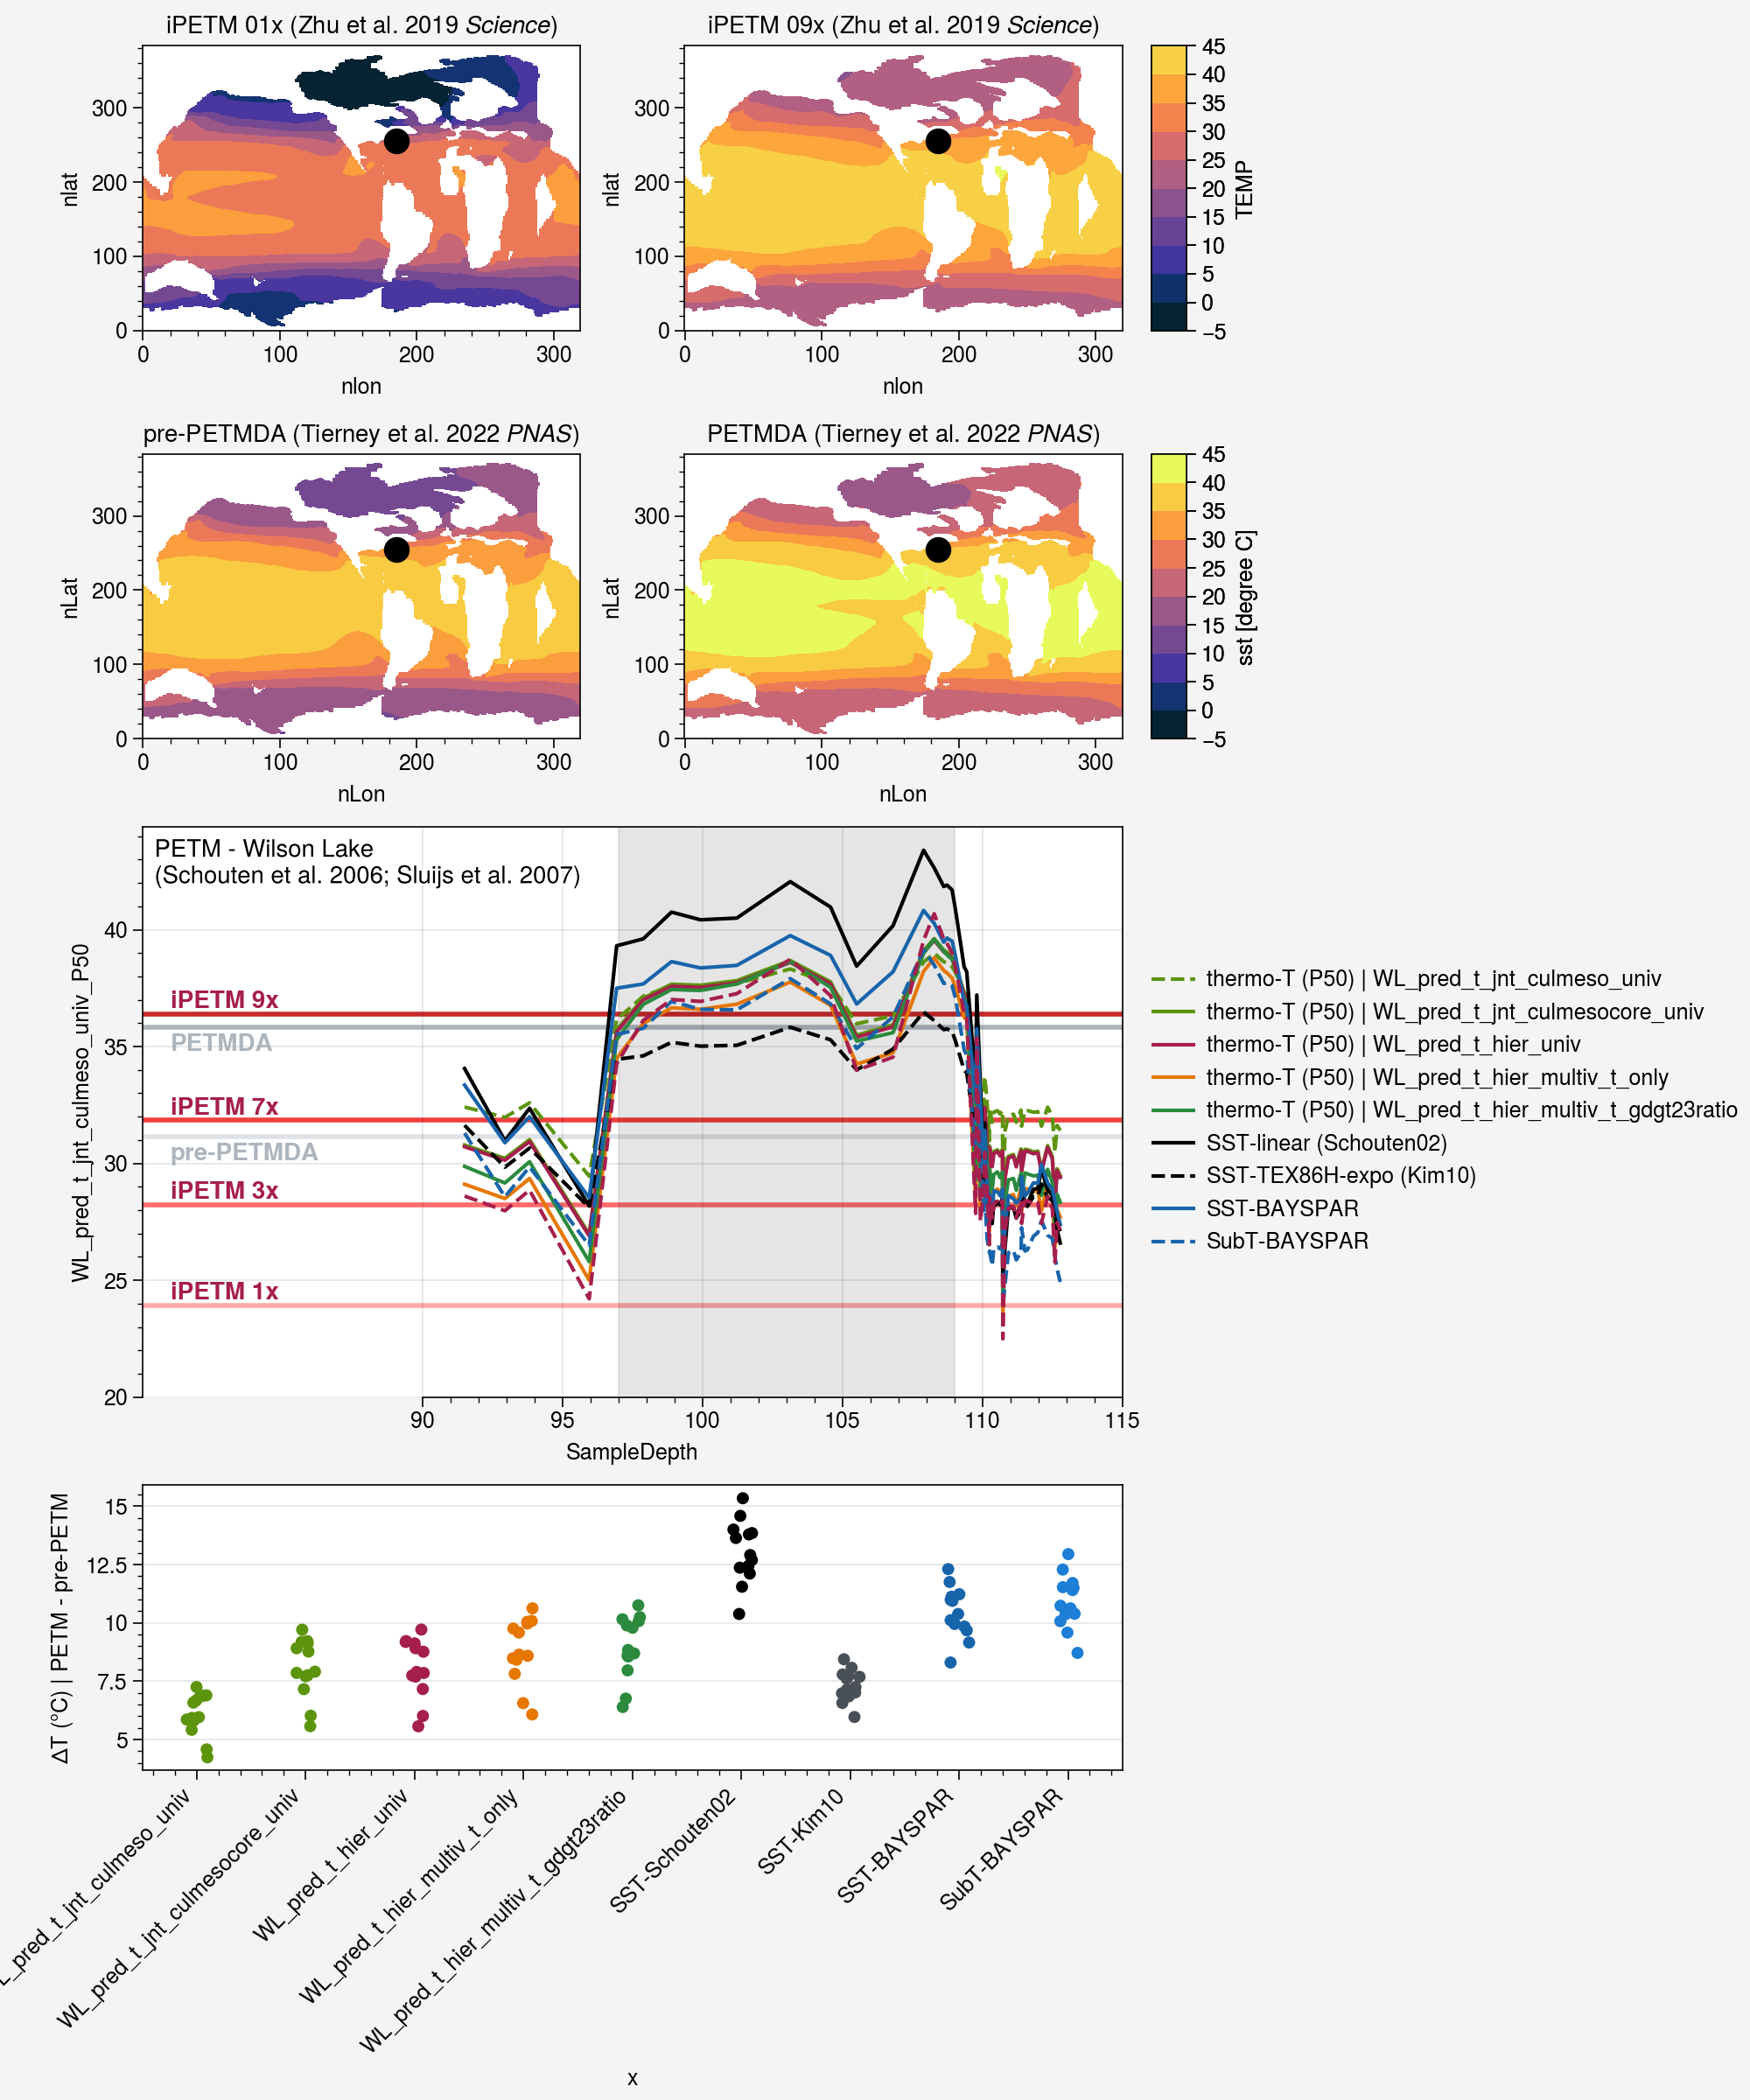

In [ ]:
array = [
    [1,2],
    [3,4],
    [5,5],
    [6,6]
]
fig, axs = plot.subplots(array, figsize=(10,12),share=0,
                         hratios=[0.5,0.5,1,0.5],)



### plot iPETM data at 01x and 09x
sel_nlon = 185
sel_nlat = 255
axs[0:4].scatter(sel_nlon,sel_nlat,
                 c='k',marker='o',s=100)

iPETM_01x_ds.mean(dim='time').TEMP.plot(
    ax=axs[0],zorder=0,
    cmap='thermal',levels=np.arange(-5,50,5),
    add_colorbar=False)
axs[0].set_title('iPETM 01x (Zhu et al. 2019 ' + r'$\it{Science}$' + ')')

iPETM_09x_ds.mean(dim='time').TEMP.plot(
    ax=axs[1],zorder=0,
    cmap='thermal',levels=np.arange(-5,50,5))
axs[1].set_title('iPETM 09x (Zhu et al. 2019 ' + r'$\it{Science}$' + ')')

prePETMDA_da.plot(ax=axs[2],zorder=0,
                cmap='thermal',levels=np.arange(-5,50,5),
                add_colorbar=False)
axs[2].set_title('pre-PETMDA (Tierney et al. 2022 ' + r'$\it{PNAS}$' + ')')

PETMDA_da.plot(ax=axs[3],zorder=0,
                cmap='thermal',levels=np.arange(-5,50,5))
axs[3].set_title('PETMDA (Tierney et al. 2022 ' + r'$\it{PNAS}$' + ')')

WL_pred_t_post_list = [WL_pred_t_joint_culmeso_univ_post_ds,
                WL_pred_t_joint_culmesocore_univ_post_ds,
                WL_pred_t_hier_univ_post_ds,
                WL_pred_t_hier_multiv_t_only_post_ds,
                WL_pred_t_hier_multiv_t_gdgt23ratio_post_ds]

name_list = ['WL_pred_t_jnt_culmeso_univ',
             'WL_pred_t_jnt_culmesocore_univ',
             'WL_pred_t_hier_univ',
             'WL_pred_t_hier_multiv_t_only',
             'WL_pred_t_hier_multiv_t_gdgt23ratio']
colors = ['lime9', 'lime9', 'pink9', 'yellow9', 'green9']
lines = ['--','-','-','-','-']
for i, WL_pred_t_post_ds in enumerate(WL_pred_t_post_list):
    ###
    WL_paleo_tex_df[f'{name_list[i]}_P50'] = WL_pred_t_post_ds['t_est'].quantile(0.5, dim=['draw','dim_2']).values
    WL_paleo_tex_df[f'{name_list[i]}_P16'] = WL_pred_t_post_ds['t_est'].quantile(0.16, dim=['draw','dim_2']).values
    WL_paleo_tex_df[f'{name_list[i]}_P84'] = WL_pred_t_post_ds['t_est'].quantile(0.84, dim=['draw','dim_2']).values

    ax = axs[4]
    plot_x = WL_paleo_tex_df['SampleDepth']
    plot_y = WL_paleo_tex_df[f'{name_list[i]}_P50']
    ax.plot(plot_x, plot_y, color=colors[i], ls=lines[i],
            label=f'thermo-T (P50) | {name_list[i]}')
    

ax = axs[4]
ax.spines['bottom'].set_bounds(90,115)
###### plot PETM data
ax.plot(WL_paleo_tex_df['SampleDepth'], WL_paleo_tex_df['SST_Schouten02'],
              c='k',label='SST-linear (Schouten02)')
ax.plot(WL_paleo_tex_df['SampleDepth'], WL_paleo_tex_df['SST_Kim10'],
                c='k',ls='--',label='SST-TEX86H-expo (Kim10)')
ax.plot(WL_paleo_tex_df['SampleDepth'], WL_paleo_tex_df['SST_bsr'],
                c='blue9',ls='-',label='SST-BAYSPAR')
ax.plot(WL_paleo_tex_df['SampleDepth'], WL_paleo_tex_df['subT_bsr'],
                c='blue9',ls='--',label='SubT-BAYSPAR')
# Calculate the inverse logistic function


n_ens = 100
rand_idx = np.random.choice(len(joint_cul_meso_hier_coretop_post_ds["t0_coretop"]))
pred_T_ensemble = np.zeros((n_ens, len(WL_paleo_tex_df)))
for i in range(n_ens):
    t0_ = joint_cul_meso_hier_coretop_post_ds["t0_coretop"].values[rand_idx]
    k_ = joint_cul_meso_hier_coretop_post_ds["k_coretop"].values[rand_idx]
    b_ = joint_cul_meso_hier_coretop_post_ds["b_coretop"].values[rand_idx]
    pred_T_ensemble[i, :] = inverse_logistic(WL_paleo_tex_df['scaledRI'], t0_, k_, b_)

# Calculate the mean and 95% confidence interval
pred_T_mean = np.mean(pred_T_ensemble, axis=0)
pred_T_std = np.std(pred_T_ensemble, axis=0)



plot_x = WL_paleo_tex_df['SampleDepth']
ax = axs[4]
ax.plot(plot_x, pred_T_mean, color='pink9', ls='--',
        label='Inverse Logistic from calibration posteriors (P50)')

h, l = ax.get_legend_handles_labels()
ax.legend(h, l, loc='r', ncols=1, fontsize=8, frameon=False)

iPETM_ds_list = [iPETM_01x_ds, iPETM_03x_ds, iPETM_06x_ds, iPETM_09x_ds]
for i, iPETM_ds in enumerate(iPETM_ds_list):
    sel_nlon = 185
    sel_nlat = 255
    plot_sel_t = iPETM_ds.mean(dim='time').TEMP.sel(nlon=sel_nlon,nlat=sel_nlat).values
    ax.axhline(y=plot_sel_t, color=['red3','red5','red7','red9'][i],
               zorder=0,lw=2)
    
    ax.text(81, plot_sel_t+0.25, f'iPETM {[1,3,7,9][i]}x',
            fontsize=10,fontweight='bold',c='pink9')

PETMDA_ds_list = [prePETMDA_da, PETMDA_da]
for i, sel_da in enumerate(PETMDA_ds_list):
    sel_nlon = 185
    sel_nlat = 255
    plot_sel_t = sel_da.sel(nLon=sel_nlon,nLat=sel_nlat).values.copy()
    ax.axhline(y=plot_sel_t, color=['gray3','gray5'][i],
               zorder=0,lw=2)
    
    ax.text(81, plot_sel_t-1, f'{["pre-PETMDA","PETMDA"][i]}',
            fontsize=10,fontweight='bold',c='gray5')
    
ax.format(
    xlim=(80,115),
    ymin=20,
    ultitle='PETM - Wilson Lake\n(Schouten et al. 2006; Sluijs et al. 2007)'
)



ax = axs[5]
### calculate T difference between pre-PETM (depth 110.5--113) and PETM (dpeth 97--109) for each model
predT_model_list = [
                    'WL_pred_t_jnt_culmeso_univ_P50',
                    'WL_pred_t_jnt_culmesocore_univ_P50',
                    'WL_pred_t_hier_univ_P50',
                    'WL_pred_t_hier_multiv_t_only_P50',
                    'WL_pred_t_hier_multiv_t_gdgt23ratio_P50',
                    'SST_Schouten02',
                    'SST_Kim10',
                    'SST_bsr',
                    'subT_bsr',
                    ]


diff_data = {}
diff_T_column_list = []
for predT_model in predT_model_list:
    prePETM = WL_paleo_tex_df[(WL_paleo_tex_df['SampleDepth']>=110.5) 
                           & (WL_paleo_tex_df['SampleDepth']<=113)][predT_model].mean()
    
    PETM = WL_paleo_tex_df[(WL_paleo_tex_df['SampleDepth']>=97) 
                        & (WL_paleo_tex_df['SampleDepth']<=109)][predT_model].mean()
    diff_data[predT_model] = PETM - prePETM
    
    WL_paleo_tex_df[f'diff_from_prePETM_{predT_model}'] = WL_paleo_tex_df[predT_model] - prePETM
    diff_T_column_list.append(f'diff_from_prePETM_{predT_model}')
diff_data = pd.DataFrame(diff_data, index=[0])

feature = diff_T_column_list
paleo_diffT_df = WL_paleo_tex_df[(WL_paleo_tex_df['SampleDepth']>=97) 
                              & (WL_paleo_tex_df['SampleDepth']<=109)][feature].copy()
### plot boxplot show range of T difference of each model in axs[3]

_set_palette = ['lime9','lime9','pink9', 'yellow9', 'green9',
                'k', 'gray7', 'blue9', 'blue7']
paleo_diffT_df.columns = [
    'WL_pred_t_jnt_culmeso_univ', 'WL_pred_t_jnt_culmesocore_univ',
    'WL_pred_t_hier_univ', 'WL_pred_t_hier_multiv_t_only',
    'WL_pred_t_hier_multiv_t_gdgt23ratio',
    'SST-Schouten02', 'SST-Kim10', 'SST-BAYSPAR', 'SubT-BAYSPAR',
    ]
sns.stripplot(data=paleo_diffT_df,ax=ax,orient='v',palette=_set_palette)

ax.format(
    xrotation=45,
    ylabel='$\Delta$T (°C) | PETM - pre-PETM',
)

from matplotlib import patches
rect = patches.Rectangle((97, 20), 12, 25, color='k', alpha=0.1)

axs[4].add_patch(rect)


#### test with inverse calulation




In [54]:
joint_cul_meso_hier_coretop_post_ds

<xarray.Dataset>
Dimensions:                 (draw: 4000)
Coordinates:
  * draw                    (draw) int64 0 1 2 3 4 ... 3995 3996 3997 3998 3999
Data variables:
    t0_culmeso              (draw) float64 30.39 28.92 29.7 ... 27.21 28.26
    k_culmeso               (draw) float64 0.1675 0.1435 0.152 ... 0.1284 0.1079
    b_culmeso               (draw) float64 0.4265 0.4046 ... 0.3291 0.3415
    t0_coretop              (draw) float64 28.23 28.2 28.22 ... 28.19 28.26 28.2
    k_coretop               (draw) float64 0.1247 0.1264 ... 0.1149 0.1182
    b_coretop               (draw) float64 0.4283 0.4321 0.4325 ... 0.4238 0.427
    sigma_t0_culmeso        (draw) float64 1.758 2.137 2.994 ... 1.434 0.7146
    sigma_k_culmeso         (draw) float64 0.2819 0.03637 ... 0.04409 0.03367
    sigma_b_culmeso         (draw) float64 0.1222 0.03143 ... 0.1266 0.1503
    sigma_scaledRI_cul      (draw) float64 0.07623 0.06595 ... 0.08134 0.07702
    sigma_scaledRI_meso     (draw) float64 0.08513 0.09248 ... 0.08285 0.12
    sigma_scaledRI_coretop  (draw) float64 0.05916 0.0619 ... 0.05768 0.05937

# ODP1172 Showcase

In [25]:
odp1172_tex_df = PhanTEX_df[PhanTEX_df['SiteName']=='ODP1172'].reset_index(drop=True)
odp1172_tex_df['thermoT_linear'] = (odp1172_tex_df['TEX86'] - intercept)/slope
odp1172_tex_df['SST_Schouten02'] = predictSSTfromTEX(odp1172_tex_df['TEX86'],method_name='schouteN_meso002')
odp1172_tex_df['SST_Kim10'] = predictSSTfromTEX(odp1172_tex_df['TEX86'],method_name='kim2010_tex86H')

odp1172_tolerance = np.std(odp1172_tex_df['TEX86'], ddof=1) * 2
odp1172_tex_df['SST_bsr'] = bsr.predict_seatemp_analog(odp1172_tex_df['TEX86'],
                                             prior_mean=18,prior_std=6,
                                             temptype='sst',
                                             search_tol=odp1172_tolerance,
                                             nens=100).percentile(50)
odp1172_tex_df['subT_bsr'] = bsr.predict_seatemp_analog(odp1172_tex_df['TEX86'],
                                             prior_mean=18,prior_std=6,
                                             temptype='subt',
                                             search_tol=odp1172_tolerance,
                                             nens=100).percentile(50)

100%|██████████| 34/34 [00:14<00:00,  2.34it/s]


In [26]:
set_mu_t_prior = 35.0

# n_draws = len(joint_cul_meso_post_ds.draw)
# M_reduced = 100
# # Random subset of draw indices (or use stratified sampling)
# subset_indices = np.random.choice(n_draws, size=M_reduced, replace=False)
# data = {
#     "N_downcore": len(odp1172_tex_df),
#     "scaledRI_downcore": odp1172_tex_df['scaledRI'].astype(float).tolist(),
#     "prior_mu_t": [set_mu_t_prior] * len(odp1172_tex_df),
#     "prior_sigma_t": 6,
#     "M": M_reduced,
#     "t0_coretop": joint_cul_meso_post_ds["t0_culmeso"].values[subset_indices],
#     "k_coretop": joint_cul_meso_post_ds["k_culmeso"].values[subset_indices],
#     "b_coretop": joint_cul_meso_post_ds["b_culmeso"].values[subset_indices],
#     "sigma_scaledRI_coretop": joint_cul_meso_post_ds["sigma_scaledRI_culmeso"][subset_indices],
# }

# stan_file_name = 'invT_logistic_fixed_univ.stan'
# odp1172_pred_t_joint_culmeso_univ_post_ds, diag = get_invT_posterior(data, stan_file_name)

# n_draws = len(joint_cul_meso_coretop_post_ds.draw)
# M_reduced = 100
# # Random subset of draw indices (or use stratified sampling)
# subset_indices = np.random.choice(n_draws, size=M_reduced, replace=False)
# data = {
#     "N_downcore": len(odp1172_tex_df),
#     "scaledRI_downcore": odp1172_tex_df['scaledRI'].astype(float).tolist(),
#     "prior_mu_t": [set_mu_t_prior] * len(odp1172_tex_df),
#     "prior_sigma_t": 6,
#     "M": M_reduced,
#     "t0_coretop": joint_cul_meso_coretop_post_ds["t0_culmesocore"].values[subset_indices],
#     "k_coretop": joint_cul_meso_coretop_post_ds["k_culmesocore"].values[subset_indices],
#     "b_coretop": joint_cul_meso_coretop_post_ds["b_culmesocore"].values[subset_indices],
#     "sigma_scaledRI_coretop": joint_cul_meso_coretop_post_ds["sigma_scaledRI_coretop"][subset_indices],
# }

# stan_file_name = 'invT_logistic_fixed_univ.stan'
# odp1172_pred_t_joint_culmesocore_univ_post_ds, diag = get_invT_posterior(data, stan_file_name)


n_draws = len(joint_cul_meso_hier_coretop_post_ds.draw)
M_reduced = 100
# Random subset of draw indices (or use stratified sampling)
subset_indices = np.random.choice(n_draws, size=M_reduced, replace=False)
data = {
    "N_downcore": len(odp1172_tex_df),
    "scaledRI_downcore": odp1172_tex_df['scaledRI'].astype(float).tolist(),
    "prior_mu_t": [set_mu_t_prior] * len(odp1172_tex_df),
    "prior_sigma_t": 6,
    "M": M_reduced,
    "t0_coretop": joint_cul_meso_hier_coretop_post_ds["t0_coretop"].values[subset_indices],
    "k_coretop": joint_cul_meso_hier_coretop_post_ds["k_coretop"].values[subset_indices],
    "b_coretop": joint_cul_meso_hier_coretop_post_ds["b_coretop"].values[subset_indices],
    "sigma_scaledRI_coretop": joint_cul_meso_hier_coretop_post_ds["sigma_scaledRI_coretop"][subset_indices],
}

stan_file_name = 'invT_logistic_fixed_univ.stan'
odp1172_pred_t_hier_univ_post_ds, diag = get_invT_posterior(data, stan_file_name)


# n_draws = len(joint_cul_meso_hier_coretop_multiv_post_ds.draw)
# M_reduced = 100
# # Random subset of draw indices (or use stratified sampling)
# subset_indices = np.random.choice(n_draws, size=M_reduced, replace=False)
# data = {
#     "N_downcore": len(odp1172_tex_df),
#     "scaledRI_downcore": odp1172_tex_df['scaledRI'].astype(float).tolist(),
#     "prior_mu_t": [set_mu_t_prior] * len(odp1172_tex_df),
#     "prior_sigma_t": 6,
#     "M": M_reduced,
#     "t0_coretop": joint_cul_meso_hier_coretop_multiv_post_ds["t0_coretop"].values[subset_indices],
#     "k_coretop": joint_cul_meso_hier_coretop_multiv_post_ds["k_coretop"].values[subset_indices],
#     "b_coretop": joint_cul_meso_hier_coretop_multiv_post_ds["b_coretop"].values[subset_indices],
#     "sigma_scaledRI_coretop": joint_cul_meso_hier_coretop_multiv_post_ds["sigma_scaledRI_coretop"][subset_indices],
# }


# stan_file_name = 'invT_logistic_fixed_univ.stan'
# odp1172_pred_t_hier_multiv_t_only_post_ds, diag = get_invT_posterior(data, stan_file_name)

n_draws = len(joint_cul_meso_hier_coretop_multiv_post_ds.draw)
M_reduced = 100
# Random subset of draw indices (or use stratified sampling)
subset_indices = np.random.choice(n_draws, size=M_reduced, replace=False)
data = {
    "N_downcore": len(odp1172_tex_df),
    "scaledRI_downcore": odp1172_tex_df['scaledRI'].values,
    "prior_mu_t": [set_mu_t_prior] * len(odp1172_tex_df),
    "prior_sigma_t": 6,
    "gdgt23ratio_downcore": odp1172_tex_df['gdgt23ratio'].values,
    
    "M": M_reduced,
    "t0_coretop": joint_cul_meso_hier_coretop_multiv_post_ds["t0_coretop"].values[subset_indices],
    "k_coretop": joint_cul_meso_hier_coretop_multiv_post_ds["k_coretop"].values[subset_indices],
    "b_coretop": joint_cul_meso_hier_coretop_multiv_post_ds["b_coretop"].values[subset_indices],
    "sigma_scaledRI_coretop": joint_cul_meso_hier_coretop_multiv_post_ds["sigma_scaledRI_coretop"][subset_indices],
    "beta0_gdgt23ratio_coretop": joint_cul_meso_hier_coretop_multiv_post_ds["beta0_gdgt23ratio_coretop"].values[subset_indices], 
    
}


stan_file_name = 'invT_logistic_fixed_multiv.stan'
odp1172_pred_t_hier_multiv_t_gdgt23ratio_post_ds, diag = get_invT_posterior(data, stan_file_name)

06:52:01 - cmdstanpy - INFO - Chain [1] start processing
06:52:01 - cmdstanpy - INFO - Chain [2] start processing
06:52:01 - cmdstanpy - INFO - Chain [3] start processing
06:52:01 - cmdstanpy - INFO - Chain [4] start processing


Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 1000 (Default)
Chain [1] num_warmup = 500
Chain [1] save_warmup = 0 (Default)
Chain [1] thin = 1 (Default)
Chain [1] adapt
Chain [1] engaged = 1 (Default)
Chain [1] gamma = 0.050000000000000003 (Default)
Chain [1] delta = 0.80000000000000004 (Default)
Chain [1] kappa = 0.75 (Default)
Chain [1] t0 = 10 (Default)
Chain [1] init_buffer = 75 (Default)
Chain [1] term_buffer = 50 (Default)
Chain [1] window = 25 (Default)
Chain [1] algorithm = hmc (Default)
Chain [1] hmc
Chain [1] engine = nuts (Default)
Chain [1] nuts
Chain [1] max_depth = 10 (Default)
Chain [1] metric = diag_e (Default)
Chain [1] metric_file =  (Default)
Chain [1] stepsize = 1 (Default)
Chain [1] stepsize_jitter = 0 (Default)
Chain [1] num_chains = 1 (Default)
Chain [1] id = 1 (Default)
Chain [1] data
Chain [1] file = /tmp/tmpg0appgur/dwjih2ug.json
Chain [1] init = 2 (Default)
Chain [1] random
Chain [1] seed = 42
Chain [1] output
Chain [1] file = /

06:55:36 - cmdstanpy - INFO - Chain [2] done processing


Chain [2] Iteration: 1500 / 1500 [100%]  (Sampling)
Chain [2] 
Chain [2] Elapsed Time: 127.448 seconds (Warm-up)
Chain [2] 87.49 seconds (Sampling)
Chain [2] 214.938 seconds (Total)
Chain [2] 
Chain [2] 
Chain [3] Iteration: 1100 / 1500 [ 73%]  (Sampling)
Chain [4] Iteration: 1200 / 1500 [ 80%]  (Sampling)
Chain [1] Iteration: 1100 / 1500 [ 73%]  (Sampling)
Chain [3] Iteration: 1200 / 1500 [ 80%]  (Sampling)
Chain [4] Iteration: 1300 / 1500 [ 86%]  (Sampling)
Chain [1] Iteration: 1200 / 1500 [ 80%]  (Sampling)
Chain [3] Iteration: 1300 / 1500 [ 86%]  (Sampling)
Chain [4] Iteration: 1400 / 1500 [ 93%]  (Sampling)
Chain [1] Iteration: 1300 / 1500 [ 86%]  (Sampling)
Chain [3] Iteration: 1400 / 1500 [ 93%]  (Sampling)


06:56:29 - cmdstanpy - INFO - Chain [4] done processing


...

Chain [2] Iteration: 1500 / 1500 [100%]  (Sampling)
Chain [2] 
Chain [2] Elapsed Time: 55.159 seconds (Warm-up)
Chain [2] 85.806 seconds (Sampling)
Chain [2] 140.965 seconds (Total)
Chain [2] 
Chain [2] 


07:00:02 - cmdstanpy - INFO - Chain [3] done processing


Chain [3] Iteration: 1500 / 1500 [100%]  (Sampling)
Chain [3] 
Chain [3] Elapsed Time: 54.578 seconds (Warm-up)
Chain [3] 87.028 seconds (Sampling)
Chain [3] 141.606 seconds (Total)
Chain [3] 
Chain [3] 
Chain [1] Iteration: 1500 / 1500 [100%]  (Sampling)


07:00:02 - cmdstanpy - INFO - Chain [1] done processing


Chain [1] 
Chain [1] Elapsed Time: 56.949 seconds (Warm-up)
Chain [1] 84.806 seconds (Sampling)
Chain [1] 141.755 seconds (Total)
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Chain [1] 
Sampling completed in 189.9 seconds
⚠️ Sampling diagnostics warning:
 Processing csv files: /tmp/tmpg0appgur/invT_logistic_fixed_multivvkeqet7h/invT_logistic_fixed_multiv-20250524065740_1.csv, /tmp/tmpg0appgur/invT_logistic_fixed_multivvkeqet7h/invT_logistic_fixed_multiv-20250524065740_2.csv, /tmp/tmpg0appgur/invT_logistic_fixed_multivvkeqet7h/invT_logistic_fixed_multiv-20250524065740_3.csv, /tmp/tmpg0appgur/invT_logistic_fixed_multivvkeqet7h/invT_logistic_fixed_multiv-20250524065740_4.csv

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Effective sample size satisfactory.

Split R-hat values satisfactory all 

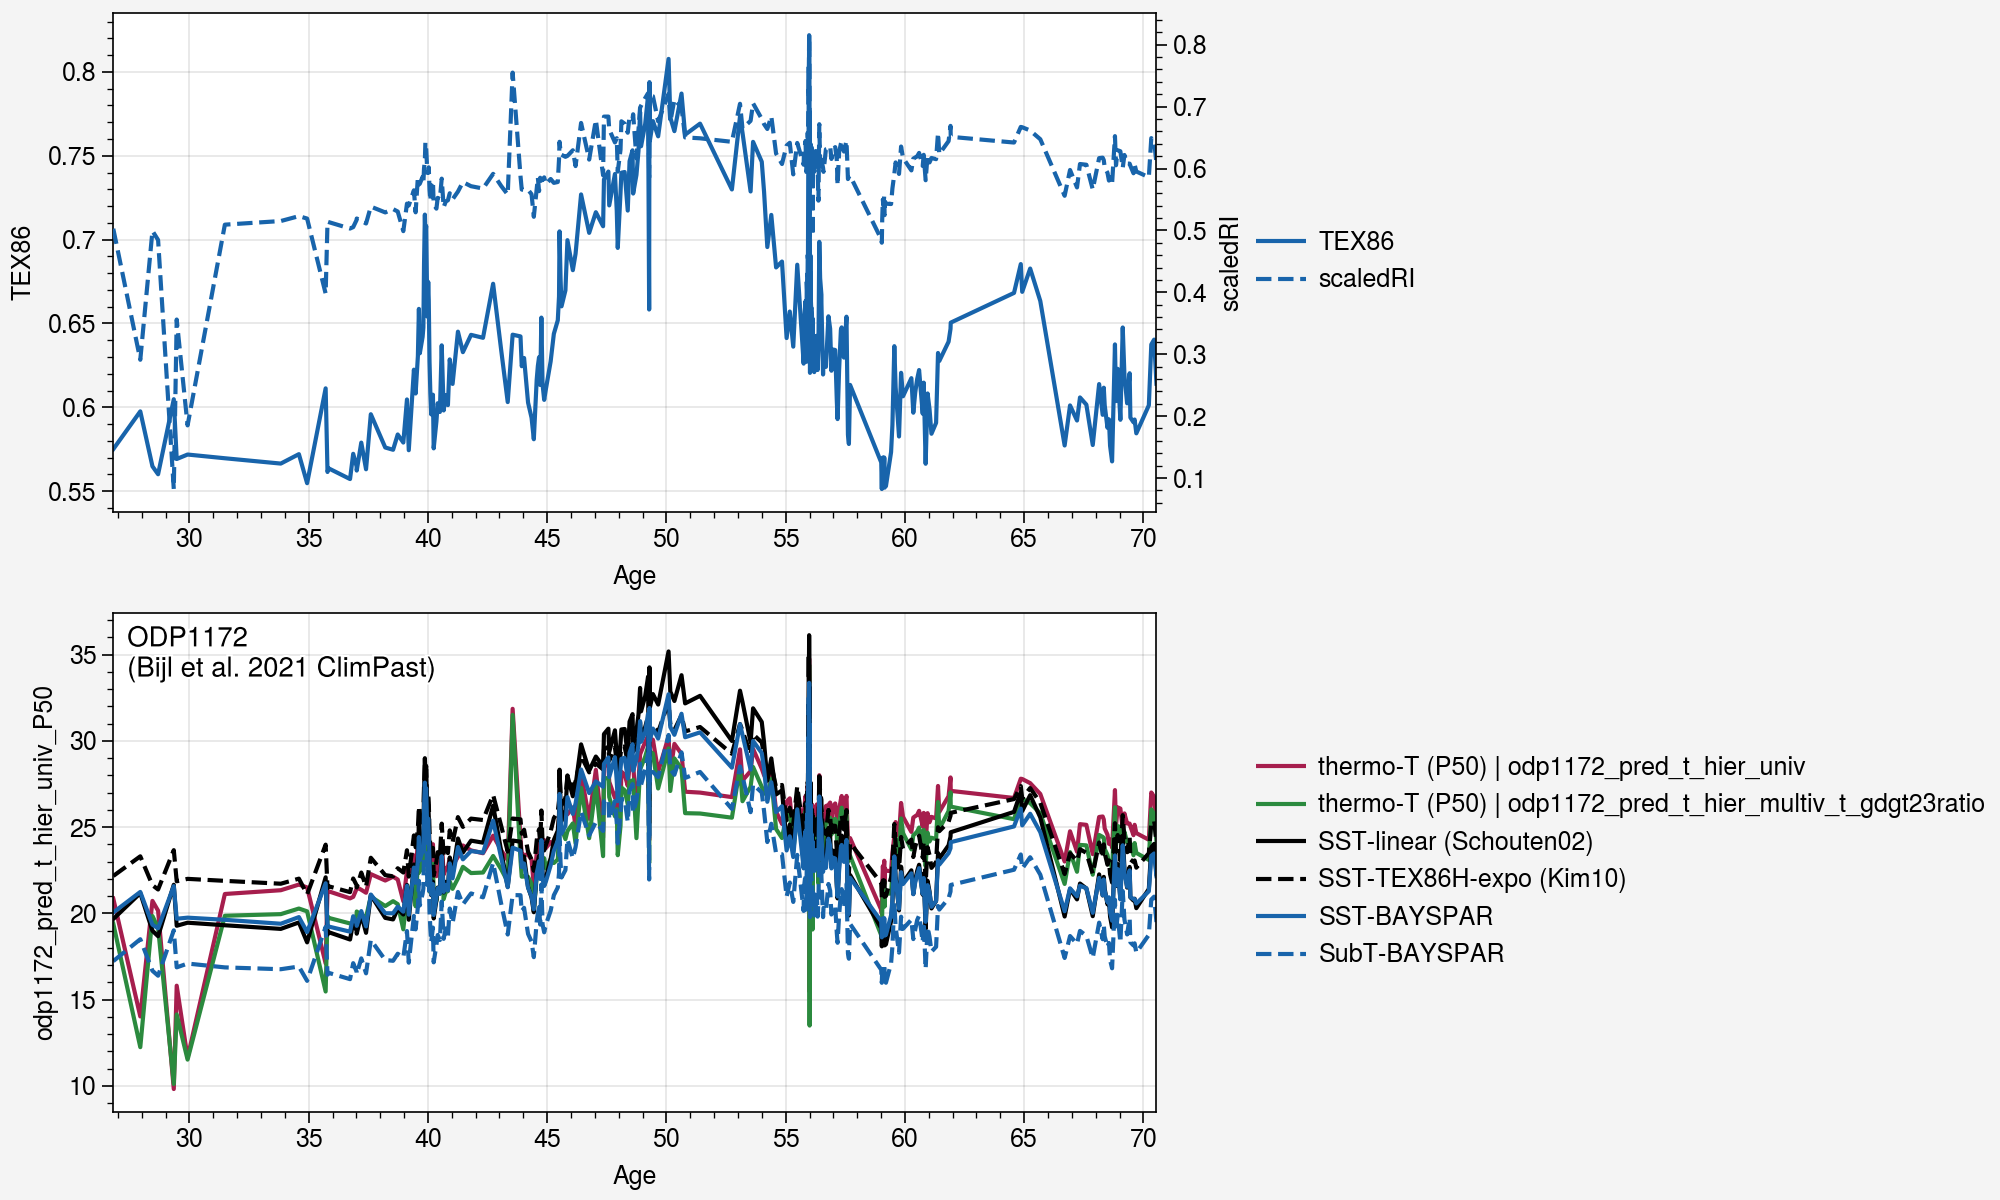

In [27]:
array = [
    [1,1],
    [2,2]
]
fig, axs = plot.subplots(array,figsize=(10,6),
                         share=0)
sel_idx = odp1172_tex_df['TEX86']>0.55
plot_data = odp1172_tex_df[odp1172_tex_df['TEX86']>0.55].reset_index(drop=True).copy()

ax = axs[0]

plot_x = plot_data['Age']
plot_y = plot_data['TEX86']
ax2 = ax.twinx()
plot_y2 = plot_data['scaledRI']
ax.plot(plot_x, plot_y, color='blue9', ls='-',
        label='TEX86')
ax2.plot(plot_x, plot_y2, color='blue9', ls='--',
        label='scaledRI')
ax.set_ylabel('TEX86')
ax2.set_ylabel('scaledRI')
h, l = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h+h2, l+l2, loc='r', ncols=1, fontsize=8, frameon=False)


ax = axs[1]

# plot_x = md98_uk_df['Age']
# plot_y = md98_uk_df['pred_sst']
# ax.plot(plot_x, plot_y, color='pink9', lw=2,
#         label='BAYSPLINE-SST')

odp1172_pred_t_post_list = [
    # odp1172_pred_t_joint_culmeso_univ_post_ds,
    # odp1172_pred_t_joint_culmesocore_univ_post_ds,
    odp1172_pred_t_hier_univ_post_ds,
    # odp1172_pred_t_hier_multiv_t_only_post_ds,
    odp1172_pred_t_hier_multiv_t_gdgt23ratio_post_ds]

name_list = [
    # 'odp1172_pred_t_jnt_culmeso_univ',
    # 'odp1172_pred_t_jnt_culmesocore_univ',
    'odp1172_pred_t_hier_univ',
    # 'odp1172_pred_t_hier_multiv_t_only',
    'odp1172_pred_t_hier_multiv_t_gdgt23ratio']
colors = [
    # 'lime9', 'lime9', 
    'pink9',
    # 'yellow9', 
    'green9']
lines = [
    # '--','-','-',
    '-','-']
for i, odp1172_pred_t_post_ds in enumerate(odp1172_pred_t_post_list):
    ###md98_uk_df['pred_sst']
    plot_data[f'{name_list[i]}_P50'] = odp1172_pred_t_post_ds['t_est'].quantile(0.5, dim=['draw','dim_2']).values[sel_idx]
    plot_data[f'{name_list[i]}_P16'] = odp1172_pred_t_post_ds['t_est'].quantile(0.16, dim=['draw','dim_2']).values[sel_idx]
    plot_data[f'{name_list[i]}_P84'] = odp1172_pred_t_post_ds['t_est'].quantile(0.84, dim=['draw','dim_2']).values[sel_idx]

    plot_x = plot_data['Age']
    plot_y = plot_data[f'{name_list[i]}_P50']
    ax.plot(plot_x, plot_y, color=colors[i], ls=lines[i],
            label=f'thermo-T (P50) | {name_list[i]}')
    


###### plot PETM data
ax.plot(plot_data['Age'], plot_data['SST_Schouten02'],
              c='k',label='SST-linear (Schouten02)')
ax.plot(plot_data['Age'], plot_data['SST_Kim10'],
                c='k',ls='--',label='SST-TEX86H-expo (Kim10)')
ax.plot(plot_data['Age'], plot_data['SST_bsr'],
                c='blue9',ls='-',label='SST-BAYSPAR')
ax.plot(plot_data['Age'], plot_data['subT_bsr'],
                c='blue9',ls='--',label='SubT-BAYSPAR')

h, l = ax.get_legend_handles_labels()
ax.legend(h, l, loc='r', ncols=1, fontsize=8, frameon=False)

ax.format(
    ultitle='ODP1172\n(Bijl et al. 2021 ClimPast)'
)

# ### calculate T difference between pre-PETM (depth 110.5--113) and PETM (dpeth 97--109) for each model
# predT_model_list = [
#                     'odp1172_pred_t_jnt_culmeso_univ_P50',
#                     'odp1172_pred_t_jnt_culmesocore_univ_P50',
#                     'odp1172_pred_t_hier_univ_P50',
#                     'odp1172_pred_t_hier_multiv_t_only_P50',
#                     'odp1172_pred_t_hier_multiv_t_gdgt23ratio_P50',
#                     'SST_Schouten02',
#                     'SST_Kim10',
#                     'SST_bsr',
#                     'subT_bsr',
#                     ]


# diff_data = {}
# diff_T_column_list = []
# for predT_model in predT_model_list:
#     prePETM = plot_data[(plot_data['Age']>=110.5) 
#                            & (plot_data['Age']<=113)][predT_model].mean()
    
#     PETM = plot_data[(plot_data['Age']>=97) 
#                         & (plot_data['Age']<=109)][predT_model].mean()
#     diff_data[predT_model] = PETM - prePETM
    
#     plot_data[f'diff_from_prePETM_{predT_model}'] = plot_data[predT_model] - prePETM
#     diff_T_column_list.append(f'diff_from_prePETM_{predT_model}')
# diff_data = pd.DataFrame(diff_data, index=[0])

# feature = diff_T_column_list
# paleo_diffT_df = plot_data[(plot_data['Age']>=97) 
#                               & (plot_data['Age']<=109)][feature].copy()
# ### plot boxplot show range of T difference of each model in axs[3]

# _set_palette = ['lime9','lime9','pink9', 'yellow9', 'green9',
#                 'k', 'gray7', 'blue9', 'blue7']
# paleo_diffT_df.columns = [
#     'odp1172_pred_t_jnt_culmeso_univ', 'odp1172_pred_t_jnt_culmesocore_univ',
#     'odp1172_pred_t_hier_univ', 'odp1172_pred_t_hier_multiv_t_only',
#     'odp1172_pred_t_hier_multiv_t_gdgt23ratio',
#     'SST-Schouten02', 'SST-Kim10', 'SST-BAYSPAR', 'SubT-BAYSPAR',
#     ]
# sns.stripplot(data=paleo_diffT_df,ax=ax,orient='v',palette=_set_palette)

# ax.format(
#     xrotation=45,
#     ylabel='$\Delta$T (°C) | PETM - pre-PETM',
# )


# mid-Waipara section - PETM

In [28]:
mWP_tex_df = PhanTEX_df[PhanTEX_df['SiteName']=='Mid-Waipara River'].reset_index(drop=True)
mWP_tex_df['thermoT_linear'] = (mWP_tex_df['TEX86'] - intercept)/slope
mWP_tex_df['SST_Schouten02'] = predictSSTfromTEX(mWP_tex_df['TEX86'],method_name='schouteN_meso002')
mWP_tex_df['SST_Kim10'] = predictSSTfromTEX(mWP_tex_df['TEX86'],method_name='kim2010_tex86H')

mWP_tex_tolerance = np.std(mWP_tex_df['TEX86'], ddof=1) * 2
selLat = mWP_tex_df['ModLat'].values[0]
selLon = mWP_tex_df['ModLon'].values[0]
mWP_tex_df['SST_bsr'] = bsr.predict_seatemp(mWP_tex_df['TEX86'],
                                             lat=selLat,lon=selLon,
                                             prior_mean=18,prior_std=6,
                                             temptype='sst',
                                             nens=100).percentile(50)
mWP_tex_df['subT_bsr'] = bsr.predict_seatemp(mWP_tex_df['TEX86'],
                                             lat=selLat,lon=selLon,
                                             prior_mean=18,prior_std=6,
                                             temptype='subt',
                                             nens=100).percentile(50)

In [29]:
set_mu_t_prior = 35.0

# n_draws = len(joint_cul_meso_post_ds.draw)
# M_reduced = 100
# # Random subset of draw indices (or use stratified sampling)
# subset_indices = np.random.choice(n_draws, size=M_reduced, replace=False)
# data = {
#     "N_downcore": len(mWP_tex_df),
#     "scaledRI_downcore": mWP_tex_df['scaledRI'].astype(float).tolist(),
#     "prior_mu_t": [set_mu_t_prior] * len(mWP_tex_df),
#     "prior_sigma_t": 6,
#     "M": M_reduced,
#     "t0_coretop": joint_cul_meso_post_ds["t0_culmeso"].values[subset_indices],
#     "k_coretop": joint_cul_meso_post_ds["k_culmeso"].values[subset_indices],
#     "b_coretop": joint_cul_meso_post_ds["b_culmeso"].values[subset_indices],
#     "sigma_scaledRI_coretop": joint_cul_meso_post_ds["sigma_scaledRI_culmeso"][subset_indices],
# }

# stan_file_name = 'invT_logistic_fixed_univ.stan'
# mWP_pred_t_joint_culmeso_univ_post_ds, diag = get_invT_posterior(data, stan_file_name)

# n_draws = len(joint_cul_meso_coretop_post_ds.draw)
# M_reduced = 100
# # Random subset of draw indices (or use stratified sampling)
# subset_indices = np.random.choice(n_draws, size=M_reduced, replace=False)
# data = {
#     "N_downcore": len(mWP_tex_df),
#     "scaledRI_downcore": mWP_tex_df['scaledRI'].astype(float).tolist(),
#     "prior_mu_t": [set_mu_t_prior] * len(mWP_tex_df),
#     "prior_sigma_t": 6,
#     "M": M_reduced,
#     "t0_coretop": joint_cul_meso_coretop_post_ds["t0_culmesocore"].values[subset_indices],
#     "k_coretop": joint_cul_meso_coretop_post_ds["k_culmesocore"].values[subset_indices],
#     "b_coretop": joint_cul_meso_coretop_post_ds["b_culmesocore"].values[subset_indices],
#     "sigma_scaledRI_coretop": joint_cul_meso_coretop_post_ds["sigma_scaledRI_coretop"][subset_indices],
# }

# stan_file_name = 'invT_logistic_fixed_univ.stan'
# mWP_pred_t_joint_culmesocore_univ_post_ds, diag = get_invT_posterior(data, stan_file_name)


n_draws = len(joint_cul_meso_hier_coretop_post_ds.draw)
M_reduced = 100
# Random subset of draw indices (or use stratified sampling)
subset_indices = np.random.choice(n_draws, size=M_reduced, replace=False)
data = {
    "N_downcore": len(mWP_tex_df),
    "scaledRI_downcore": mWP_tex_df['scaledRI'].astype(float).tolist(),
    "prior_mu_t": [set_mu_t_prior] * len(mWP_tex_df),
    "prior_sigma_t": 6,
    "M": M_reduced,
    "t0_coretop": joint_cul_meso_hier_coretop_post_ds["t0_coretop"].values[subset_indices],
    "k_coretop": joint_cul_meso_hier_coretop_post_ds["k_coretop"].values[subset_indices],
    "b_coretop": joint_cul_meso_hier_coretop_post_ds["b_coretop"].values[subset_indices],
    "sigma_scaledRI_coretop": joint_cul_meso_hier_coretop_post_ds["sigma_scaledRI_coretop"][subset_indices],
}

stan_file_name = 'invT_logistic_fixed_univ.stan'
mWP_pred_t_hier_univ_post_ds, diag = get_invT_posterior(data, stan_file_name)


# n_draws = len(joint_cul_meso_hier_coretop_multiv_post_ds.draw)
# M_reduced = 100
# # Random subset of draw indices (or use stratified sampling)
# subset_indices = np.random.choice(n_draws, size=M_reduced, replace=False)
# data = {
#     "N_downcore": len(mWP_tex_df),
#     "scaledRI_downcore": mWP_tex_df['scaledRI'].astype(float).tolist(),
#     "prior_mu_t": [set_mu_t_prior] * len(mWP_tex_df),
#     "prior_sigma_t": 6,
#     "M": M_reduced,
#     "t0_coretop": joint_cul_meso_hier_coretop_multiv_post_ds["t0_coretop"].values[subset_indices],
#     "k_coretop": joint_cul_meso_hier_coretop_multiv_post_ds["k_coretop"].values[subset_indices],
#     "b_coretop": joint_cul_meso_hier_coretop_multiv_post_ds["b_coretop"].values[subset_indices],
#     "sigma_scaledRI_coretop": joint_cul_meso_hier_coretop_multiv_post_ds["sigma_scaledRI_coretop"][subset_indices],
# }


# stan_file_name = 'invT_logistic_fixed_univ.stan'
# mWP_pred_t_hier_multiv_t_only_post_ds, diag = get_invT_posterior(data, stan_file_name)

n_draws = len(joint_cul_meso_hier_coretop_multiv_post_ds.draw)
M_reduced = 100
# Random subset of draw indices (or use stratified sampling)
subset_indices = np.random.choice(n_draws, size=M_reduced, replace=False)
data = {
    "N_downcore": len(mWP_tex_df),
    "scaledRI_downcore": mWP_tex_df['scaledRI'].values,
    "prior_mu_t": [set_mu_t_prior] * len(mWP_tex_df),
    "prior_sigma_t": 6,
    "gdgt23ratio_downcore": mWP_tex_df['gdgt23ratio'].values,
    
    "M": M_reduced,
    "t0_coretop": joint_cul_meso_hier_coretop_multiv_post_ds["t0_coretop"].values[subset_indices],
    "k_coretop": joint_cul_meso_hier_coretop_multiv_post_ds["k_coretop"].values[subset_indices],
    "b_coretop": joint_cul_meso_hier_coretop_multiv_post_ds["b_coretop"].values[subset_indices],
    "sigma_scaledRI_coretop": joint_cul_meso_hier_coretop_multiv_post_ds["sigma_scaledRI_coretop"][subset_indices],
    "beta0_gdgt23ratio_coretop": joint_cul_meso_hier_coretop_multiv_post_ds["beta0_gdgt23ratio_coretop"].values[subset_indices], 
    
}


stan_file_name = 'invT_logistic_fixed_multiv.stan'
mWP_pred_t_hier_multiv_t_gdgt23ratio_post_ds, diag = get_invT_posterior(data, stan_file_name)

07:01:07 - cmdstanpy - INFO - Chain [1] start processing
07:01:07 - cmdstanpy - INFO - Chain [2] start processing
07:01:07 - cmdstanpy - INFO - Chain [3] start processing
07:01:07 - cmdstanpy - INFO - Chain [4] start processing


Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 1000 (Default)
Chain [1] num_warmup = 500
Chain [1] save_warmup = 0 (Default)
Chain [1] thin = 1 (Default)
Chain [1] adapt
Chain [1] engaged = 1 (Default)
Chain [1] gamma = 0.050000000000000003 (Default)
Chain [1] delta = 0.80000000000000004 (Default)
Chain [1] kappa = 0.75 (Default)
Chain [1] t0 = 10 (Default)
Chain [1] init_buffer = 75 (Default)
Chain [1] term_buffer = 50 (Default)
Chain [1] window = 25 (Default)
Chain [1] algorithm = hmc (Default)
Chain [1] hmc
Chain [1] engine = nuts (Default)
Chain [1] nuts
Chain [1] max_depth = 10 (Default)
Chain [1] metric = diag_e (Default)
Chain [1] metric_file =  (Default)
Chain [1] stepsize = 1 (Default)
Chain [1] stepsize_jitter = 0 (Default)
Chain [1] num_chains = 1 (Default)
Chain [1] id = 1 (Default)
Chain [1] data
Chain [1] file = /tmp/tmpg0appgur/6kyiv36e.json
Chain [1] init = 2 (Default)
Chain [1] random
Chain [1] seed = 42
Chain [1] output
Chain [1] file = /

07:01:42 - cmdstanpy - INFO - Chain [1] done processing


Chain [4] Iteration: 1400 / 1500 [ 93%]  (Sampling)
Chain [1] Iteration: 1500 / 1500 [100%]  (Sampling)
Chain [1] 
Chain [1] Elapsed Time: 15.692 seconds (Warm-up)
Chain [1] 19.617 seconds (Sampling)
Chain [1] 35.309 seconds (Total)
Chain [1] 
Chain [1] 
Chain [1] 
Chain [3] Iteration: 1300 / 1500 [ 86%]  (Sampling)
Chain [2] Iteration: 1400 / 1500 [ 93%]  (Sampling)


07:01:44 - cmdstanpy - INFO - Chain [4] done processing


...

Chain [3] Iteration: 1500 / 1500 [100%]  (Sampling)
Chain [3] 
Chain [3] Elapsed Time: 9.17 seconds (Warm-up)
Chain [3] 19.401 seconds (Sampling)
Chain [3] 28.571 seconds (Total)
Chain [3] 
Chain [3] 
Chain [4] Iteration: 1500 / 1500 [100%]  (Sampling)
Chain [4] 
Chain [4] Elapsed Time: 9.07 seconds (Warm-up)
Chain [4] 19.665 seconds (Sampling)
Chain [4] 28.735 seconds (Total)
Chain [4] 
Chain [4] 
Chain [1] Iteration: 1500 / 1500 [100%]  (Sampling)


07:02:31 - cmdstanpy - INFO - Chain [1] done processing


Chain [1] 
Chain [1] Elapsed Time: 9.493 seconds (Warm-up)
Chain [1] 19.283 seconds (Sampling)
Chain [1] 28.776 seconds (Total)
Chain [1] 
Chain [1] 


07:02:32 - cmdstanpy - INFO - Chain [2] done processing


Chain [2] Iteration: 1500 / 1500 [100%]  (Sampling)
Chain [2] 
Chain [2] Elapsed Time: 9.706 seconds (Warm-up)
Chain [2] 19.41 seconds (Sampling)
Chain [2] 29.116 seconds (Total)
Chain [2] 
Chain [2] 
Sampling completed in 43.0 seconds
⚠️ Sampling diagnostics warning:
 Processing csv files: /tmp/tmpg0appgur/invT_logistic_fixed_multivrjt7p_3v/invT_logistic_fixed_multiv-20250524070203_1.csv, /tmp/tmpg0appgur/invT_logistic_fixed_multivrjt7p_3v/invT_logistic_fixed_multiv-20250524070203_2.csv, /tmp/tmpg0appgur/invT_logistic_fixed_multivrjt7p_3v/invT_logistic_fixed_multiv-20250524070203_3.csv, /tmp/tmpg0appgur/invT_logistic_fixed_multivrjt7p_3v/invT_logistic_fixed_multiv-20250524070203_4.csv

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Effective sample size satisfactory.

Split R-hat values sa

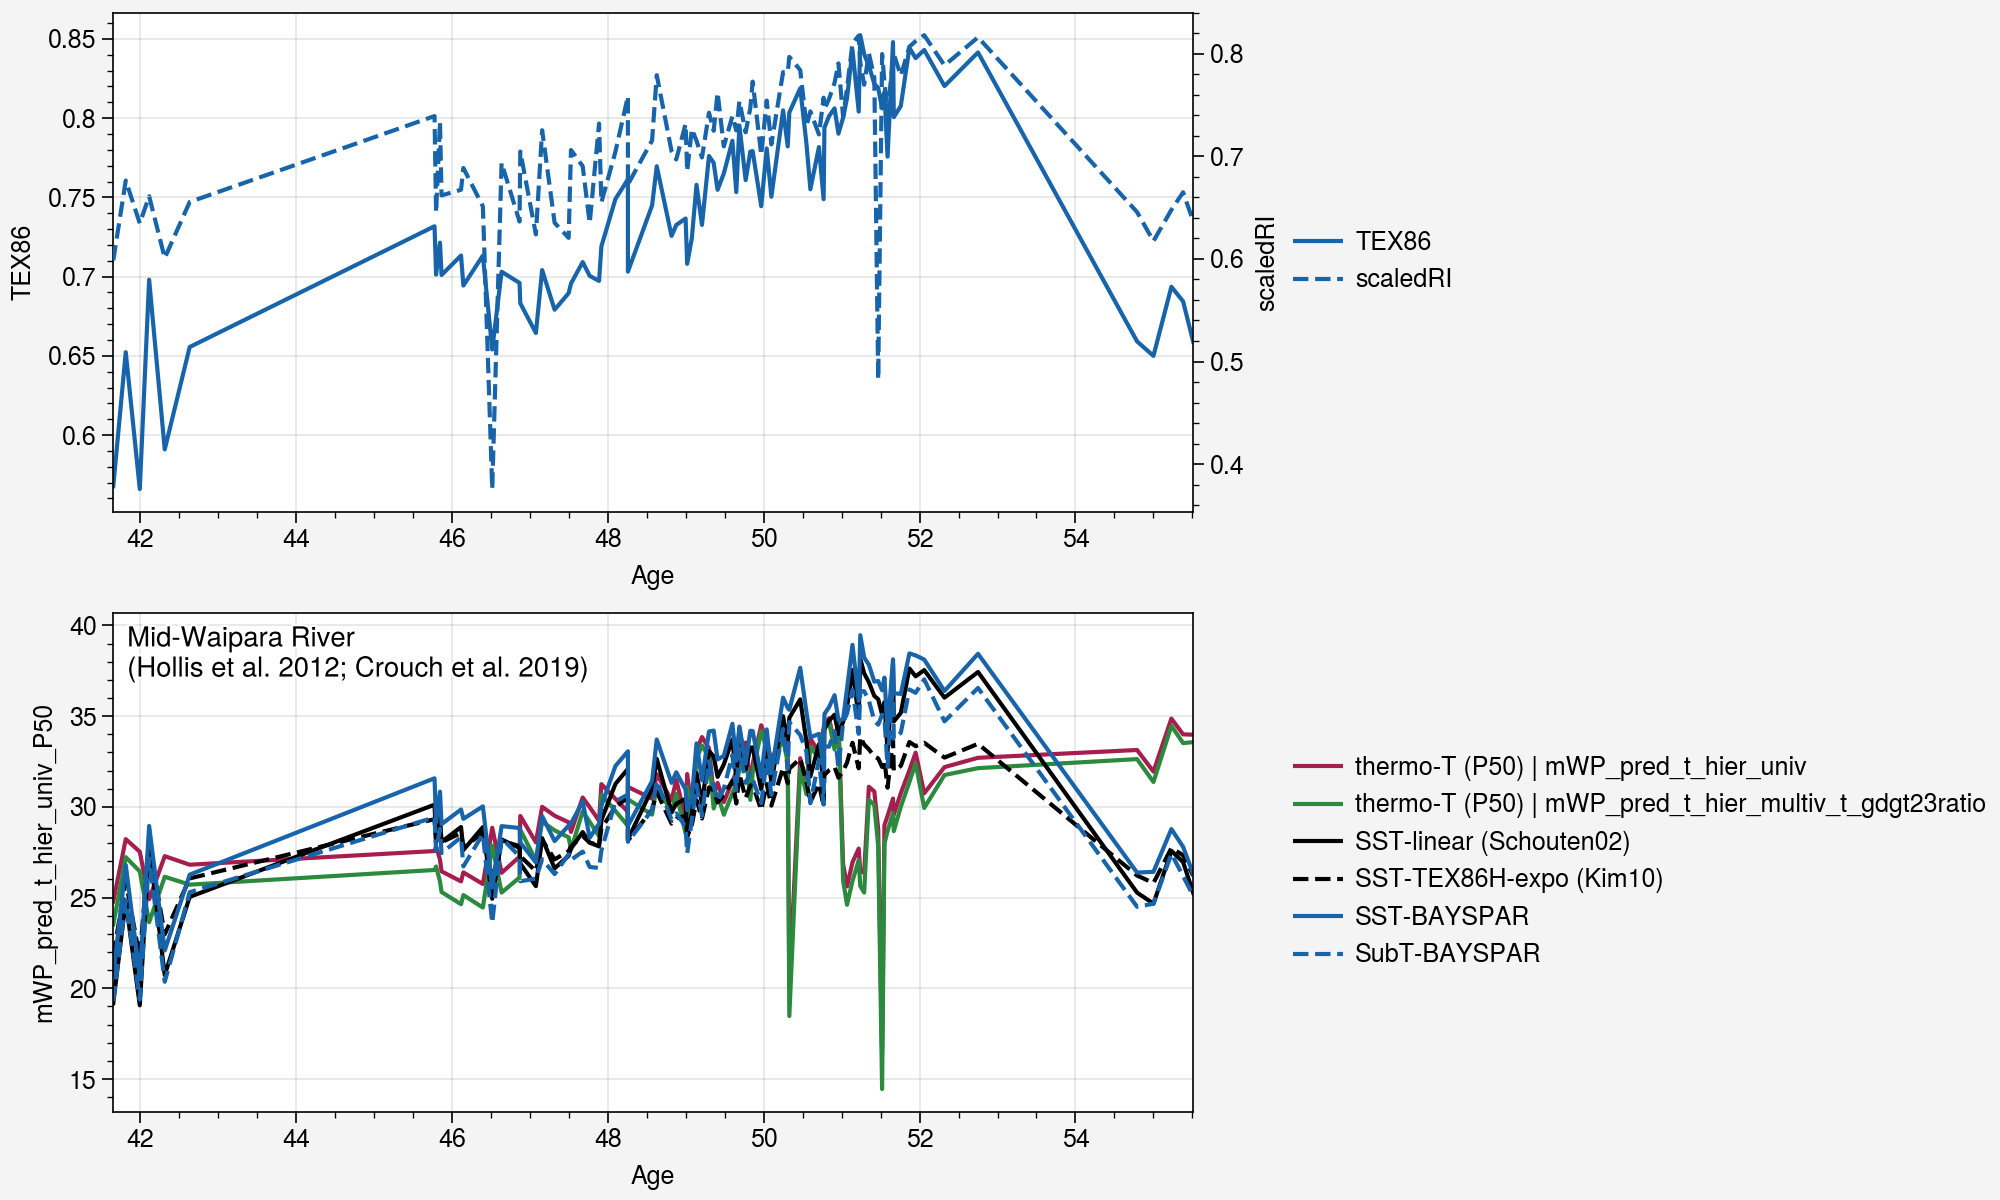

In [30]:
array = [
    [1,1],
    [2,2]
]
fig, axs = plot.subplots(array,figsize=(10,6),
                         share=0)
sel_idx = mWP_tex_df['TEX86']>0
plot_data = mWP_tex_df[mWP_tex_df['TEX86']>0].sort_values('Age').reset_index(drop=True).copy()

ax = axs[0]

plot_x = plot_data['Age']
plot_y = plot_data['TEX86']
ax2 = ax.twinx()
plot_y2 = plot_data['scaledRI']
ax.plot(plot_x, plot_y, color='blue9', ls='-',
        label='TEX86')
ax2.plot(plot_x, plot_y2, color='blue9', ls='--',
        label='scaledRI')
ax.set_ylabel('TEX86')
ax2.set_ylabel('scaledRI')
h, l = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h+h2, l+l2, loc='r', ncols=1, fontsize=8, frameon=False)


ax = axs[1]

# plot_x = md98_uk_df['Age']
# plot_y = md98_uk_df['pred_sst']
# ax.plot(plot_x, plot_y, color='pink9', lw=2,
#         label='BAYSPLINE-SST')

mWP_pred_t_post_list = [
    # mWP_pred_t_joint_culmeso_univ_post_ds,
    # mWP_pred_t_joint_culmesocore_univ_post_ds,
    mWP_pred_t_hier_univ_post_ds,
    # mWP_pred_t_hier_multiv_t_only_post_ds,
    mWP_pred_t_hier_multiv_t_gdgt23ratio_post_ds]

name_list = [
    # 'mWP_pred_t_jnt_culmeso_univ',
    # 'mWP_pred_t_jnt_culmesocore_univ',
    'mWP_pred_t_hier_univ',
    # 'mWP_pred_t_hier_multiv_t_only',
    'mWP_pred_t_hier_multiv_t_gdgt23ratio']
colors = [
    # 'lime9', 'lime9', 
    'pink9',
    # 'yellow9', 
    'green9']
lines = [
    # '--','-','-',
    '-','-']
for i, mWP_pred_t_post_ds in enumerate(mWP_pred_t_post_list):
    ###md98_uk_df['pred_sst']
    plot_data[f'{name_list[i]}_P50'] = mWP_pred_t_post_ds['t_est'].quantile(0.5, dim=['draw','dim_2']).values[sel_idx]
    plot_data[f'{name_list[i]}_P16'] = mWP_pred_t_post_ds['t_est'].quantile(0.16, dim=['draw','dim_2']).values[sel_idx]
    plot_data[f'{name_list[i]}_P84'] = mWP_pred_t_post_ds['t_est'].quantile(0.84, dim=['draw','dim_2']).values[sel_idx]

    plot_x = plot_data['Age']
    plot_y = plot_data[f'{name_list[i]}_P50']
    ax.plot(plot_x, plot_y, color=colors[i], ls=lines[i],
            label=f'thermo-T (P50) | {name_list[i]}')
    


###### plot PETM data
ax.plot(plot_data['Age'], plot_data['SST_Schouten02'],
              c='k',label='SST-linear (Schouten02)')
ax.plot(plot_data['Age'], plot_data['SST_Kim10'],
                c='k',ls='--',label='SST-TEX86H-expo (Kim10)')
ax.plot(plot_data['Age'], plot_data['SST_bsr'],
                c='blue9',ls='-',label='SST-BAYSPAR')
ax.plot(plot_data['Age'], plot_data['subT_bsr'],
                c='blue9',ls='--',label='SubT-BAYSPAR')

h, l = ax.get_legend_handles_labels()
ax.legend(h, l, loc='r', ncols=1, fontsize=8, frameon=False)

ax.format(
    ultitle='Mid-Waipara River\n(Hollis et al. 2012; Crouch et al. 2019)'
)

# ### calculate T difference between pre-PETM (depth 110.5--113) and PETM (dpeth 97--109) for each model
# predT_model_list = [
#                     'mWP_pred_t_jnt_culmeso_univ_P50',
#                     'mWP_pred_t_jnt_culmesocore_univ_P50',
#                     'mWP_pred_t_hier_univ_P50',
#                     'mWP_pred_t_hier_multiv_t_only_P50',
#                     'mWP_pred_t_hier_multiv_t_gdgt23ratio_P50',
#                     'SST_Schouten02',
#                     'SST_Kim10',
#                     'SST_bsr',
#                     'subT_bsr',
#                     ]


# diff_data = {}
# diff_T_column_list = []
# for predT_model in predT_model_list:
#     prePETM = plot_data[(plot_data['Age']>=110.5) 
#                            & (plot_data['Age']<=113)][predT_model].mean()
    
#     PETM = plot_data[(plot_data['Age']>=97) 
#                         & (plot_data['Age']<=109)][predT_model].mean()
#     diff_data[predT_model] = PETM - prePETM
    
#     plot_data[f'diff_from_prePETM_{predT_model}'] = plot_data[predT_model] - prePETM
#     diff_T_column_list.append(f'diff_from_prePETM_{predT_model}')
# diff_data = pd.DataFrame(diff_data, index=[0])

# feature = diff_T_column_list
# paleo_diffT_df = plot_data[(plot_data['Age']>=97) 
#                               & (plot_data['Age']<=109)][feature].copy()
# ### plot boxplot show range of T difference of each model in axs[3]

# _set_palette = ['lime9','lime9','pink9', 'yellow9', 'green9',
#                 'k', 'gray7', 'blue9', 'blue7']
# paleo_diffT_df.columns = [
#     'mWP_pred_t_jnt_culmeso_univ', 'mWP_pred_t_jnt_culmesocore_univ',
#     'mWP_pred_t_hier_univ', 'mWP_pred_t_hier_multiv_t_only',
#     'mWP_pred_t_hier_multiv_t_gdgt23ratio',
#     'SST-Schouten02', 'SST-Kim10', 'SST-BAYSPAR', 'SubT-BAYSPAR',
#     ]
# sns.stripplot(data=paleo_diffT_df,ax=ax,orient='v',palette=_set_palette)

# ax.format(
#     xrotation=45,
#     ylabel='$\Delta$T (°C) | PETM - pre-PETM',
# )


# MD98 G-IG showcase

In [31]:
md98_tex_df = PhanTEX_df[PhanTEX_df['SiteName']=='MD98-2152'].reset_index(drop=True)
md98_tex_df['thermoT_linear'] = (md98_tex_df['TEX86'] - intercept)/slope
md98_tex_df['SST_Schouten02'] = predictSSTfromTEX(md98_tex_df['TEX86'],method_name='schouteN_meso002')
md98_tex_df['SST_Kim10'] = predictSSTfromTEX(md98_tex_df['TEX86'],method_name='kim2010_tex86H')

md98_tex_tolerance = np.std(md98_tex_df['TEX86'], ddof=1) * 2
selLat = md98_tex_df['ModLat'].values[0]
selLon = md98_tex_df['ModLon'].values[0]
md98_tex_df['SST_bsr'] = bsr.predict_seatemp(md98_tex_df['TEX86'],
                                             lat=selLat,lon=selLon,
                                             prior_mean=18,prior_std=6,
                                             temptype='sst',
                                             nens=100).percentile(50)
md98_tex_df['subT_bsr'] = bsr.predict_seatemp(md98_tex_df['TEX86'],
                                             lat=selLat,lon=selLon,
                                             prior_mean=18,prior_std=6,
                                             temptype='subt',
                                             nens=100).percentile(50)

md98_uk_df = PhanSST_df[PhanSST_df['SiteName']=='MD98-2152'][PhanSST_df['ProxyType']=='uk'].reset_index(drop=True)
md98_uk_df['pred_sst'] = bsl.predict_sst(md98_uk_df['ProxyValue'],prior_std=6).percentile(50)


100%|██████████| 500/500 [00:08<00:00, 56.38it/s]


In [32]:
set_mu_t_prior = 26.0

# n_draws = len(joint_cul_meso_post_ds.draw)
# M_reduced = 100
# # Random subset of draw indices (or use stratified sampling)
# subset_indices = np.random.choice(n_draws, size=M_reduced, replace=False)
# data = {
#     "N_downcore": len(md98_tex_df),
#     "scaledRI_downcore": md98_tex_df['scaledRI'].astype(float).tolist(),
#     "prior_mu_t": [set_mu_t_prior] * len(md98_tex_df),
#     "prior_sigma_t": 6,
#     "M": M_reduced,
#     "t0_coretop": joint_cul_meso_post_ds["t0_culmeso"].values[subset_indices],
#     "k_coretop": joint_cul_meso_post_ds["k_culmeso"].values[subset_indices],
#     "b_coretop": joint_cul_meso_post_ds["b_culmeso"].values[subset_indices],
#     "sigma_scaledRI_coretop": joint_cul_meso_post_ds["sigma_scaledRI_culmeso"][subset_indices],
# }

# stan_file_name = 'invT_logistic_fixed_univ.stan'
# md98_pred_t_joint_culmeso_univ_post_ds, diag = get_invT_posterior(data, stan_file_name)

# n_draws = len(joint_cul_meso_coretop_post_ds.draw)
# M_reduced = 100
# # Random subset of draw indices (or use stratified sampling)
# subset_indices = np.random.choice(n_draws, size=M_reduced, replace=False)
# data = {
#     "N_downcore": len(md98_tex_df),
#     "scaledRI_downcore": md98_tex_df['scaledRI'].astype(float).tolist(),
#     "prior_mu_t": [set_mu_t_prior] * len(md98_tex_df),
#     "prior_sigma_t": 6,
#     "M": M_reduced,
#     "t0_coretop": joint_cul_meso_coretop_post_ds["t0_culmesocore"].values[subset_indices],
#     "k_coretop": joint_cul_meso_coretop_post_ds["k_culmesocore"].values[subset_indices],
#     "b_coretop": joint_cul_meso_coretop_post_ds["b_culmesocore"].values[subset_indices],
#     "sigma_scaledRI_coretop": joint_cul_meso_coretop_post_ds["sigma_scaledRI_coretop"][subset_indices],
# }

# stan_file_name = 'invT_logistic_fixed_univ.stan'
# md98_pred_t_joint_culmesocore_univ_post_ds, diag = get_invT_posterior(data, stan_file_name)

n_draws = len(joint_cul_meso_hier_coretop_post_ds.draw)
M_reduced = 100
# Random subset of draw indices (or use stratified sampling)
subset_indices = np.random.choice(n_draws, size=M_reduced, replace=False)
data = {
    "N_downcore": len(md98_tex_df),
    "scaledRI_downcore": md98_tex_df['scaledRI'].astype(float).tolist(),
    "prior_mu_t": [set_mu_t_prior] * len(md98_tex_df),
    "prior_sigma_t": 6,
    "M": M_reduced,
    "t0_coretop": joint_cul_meso_hier_coretop_post_ds["t0_coretop"].values[subset_indices],
    "k_coretop": joint_cul_meso_hier_coretop_post_ds["k_coretop"].values[subset_indices],
    "b_coretop": joint_cul_meso_hier_coretop_post_ds["b_coretop"].values[subset_indices],
    "sigma_scaledRI_coretop": joint_cul_meso_hier_coretop_post_ds["sigma_scaledRI_coretop"][subset_indices],
}

stan_file_name = 'invT_logistic_fixed_univ.stan'
md98_pred_t_hier_univ_post_ds, diag = get_invT_posterior(data, stan_file_name)


# n_draws = len(joint_cul_meso_hier_coretop_multiv_post_ds.draw)
# M_reduced = 100
# # Random subset of draw indices (or use stratified sampling)
# subset_indices = np.random.choice(n_draws, size=M_reduced, replace=False)
# data = {
#     "N_downcore": len(md98_tex_df),
#     "scaledRI_downcore": md98_tex_df['scaledRI'].astype(float).tolist(),
#     "prior_mu_t": [set_mu_t_prior] * len(md98_tex_df),
#     "prior_sigma_t": 6,
#     "M": M_reduced,
#     "t0_coretop": joint_cul_meso_hier_coretop_multiv_post_ds["t0_coretop"].values[subset_indices],
#     "k_coretop": joint_cul_meso_hier_coretop_multiv_post_ds["k_coretop"].values[subset_indices],
#     "b_coretop": joint_cul_meso_hier_coretop_multiv_post_ds["b_coretop"].values[subset_indices],
#     "sigma_scaledRI_coretop": joint_cul_meso_hier_coretop_multiv_post_ds["sigma_scaledRI_coretop"][subset_indices],
# }


# stan_file_name = 'invT_logistic_fixed_univ.stan'
# md98_pred_t_hier_multiv_t_only_post_ds, diag = get_invT_posterior(data, stan_file_name)

n_draws = len(joint_cul_meso_hier_coretop_multiv_post_ds.draw)
M_reduced = 100
# Random subset of draw indices (or use stratified sampling)
subset_indices = np.random.choice(n_draws, size=M_reduced, replace=False)
data = {
    "N_downcore": len(md98_tex_df),
    "scaledRI_downcore": md98_tex_df['scaledRI'].values,
    "prior_mu_t": [set_mu_t_prior] * len(md98_tex_df),
    "prior_sigma_t": 6,
    "gdgt23ratio_downcore": md98_tex_df['gdgt23ratio'].values,
    
    "M": M_reduced,
    "t0_coretop": joint_cul_meso_hier_coretop_multiv_post_ds["t0_coretop"].values[subset_indices],
    "k_coretop": joint_cul_meso_hier_coretop_multiv_post_ds["k_coretop"].values[subset_indices],
    "b_coretop": joint_cul_meso_hier_coretop_multiv_post_ds["b_coretop"].values[subset_indices],
    "sigma_scaledRI_coretop": joint_cul_meso_hier_coretop_multiv_post_ds["sigma_scaledRI_coretop"][subset_indices],
    "beta0_gdgt23ratio_coretop": joint_cul_meso_hier_coretop_multiv_post_ds["beta0_gdgt23ratio_coretop"].values[subset_indices], 
    
}


stan_file_name = 'invT_logistic_fixed_multiv.stan'
md98_pred_t_hier_multiv_t_gdgt23ratio_post_ds, diag = get_invT_posterior(data, stan_file_name)

07:03:03 - cmdstanpy - INFO - Chain [1] start processing
07:03:03 - cmdstanpy - INFO - Chain [2] start processing
07:03:03 - cmdstanpy - INFO - Chain [3] start processing
07:03:03 - cmdstanpy - INFO - Chain [4] start processing


Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 1000 (Default)
Chain [1] num_warmup = 500
Chain [1] save_warmup = 0 (Default)
Chain [1] thin = 1 (Default)
Chain [1] adapt
Chain [1] engaged = 1 (Default)
Chain [1] gamma = 0.050000000000000003 (Default)
Chain [1] delta = 0.80000000000000004 (Default)
Chain [1] kappa = 0.75 (Default)
Chain [1] t0 = 10 (Default)
Chain [1] init_buffer = 75 (Default)
Chain [1] term_buffer = 50 (Default)
Chain [1] window = 25 (Default)
Chain [1] algorithm = hmc (Default)
Chain [1] hmc
Chain [1] engine = nuts (Default)
Chain [1] nuts
Chain [1] max_depth = 10 (Default)
Chain [1] metric = diag_e (Default)
Chain [1] metric_file =  (Default)
Chain [1] stepsize = 1 (Default)
Chain [1] stepsize_jitter = 0 (Default)
Chain [1] num_chains = 1 (Default)
Chain [1] id = 1 (Default)
Chain [1] data
Chain [1] file = /tmp/tmpg0appgur/_9ed76vi.json
Chain [1] init = 2 (Default)
Chain [1] random
Chain [1] seed = 42
Chain [1] output
Chain [1] file = /

07:04:49 - cmdstanpy - INFO - Chain [4] done processing


Chain [4] Iteration: 1500 / 1500 [100%]  (Sampling)
Chain [4] 
Chain [4] Elapsed Time: 55.29 seconds (Warm-up)
Chain [4] 50.54 seconds (Sampling)
Chain [4] 105.83 seconds (Total)
Chain [4] 
Chain [4] 
Chain [2] Iteration: 1100 / 1500 [ 73%]  (Sampling)
Chain [1] Iteration: 1000 / 1500 [ 66%]  (Sampling)
Chain [3] Iteration: 1400 / 1500 [ 93%]  (Sampling)
Chain [2] Iteration: 1200 / 1500 [ 80%]  (Sampling)
Chain [3] Iteration: 1500 / 1500 [100%]  (Sampling)


07:04:57 - cmdstanpy - INFO - Chain [3] done processing


...

Chain [4] Iteration: 1500 / 1500 [100%]  (Sampling)
Chain [4] 
Chain [4] Elapsed Time: 29.727 seconds (Warm-up)
Chain [4] 50.597 seconds (Sampling)
Chain [4] 80.324 seconds (Total)
Chain [4] 
Chain [4] 
Chain [3] Iteration: 1500 / 1500 [100%]  (Sampling)


07:07:23 - cmdstanpy - INFO - Chain [3] done processing


Chain [3] 
Chain [3] Elapsed Time: 29.809 seconds (Warm-up)
Chain [3] 50.71 seconds (Sampling)
Chain [3] 80.519 seconds (Total)
Chain [3] 
Chain [3] 


07:07:24 - cmdstanpy - INFO - Chain [2] done processing


Chain [2] Iteration: 1500 / 1500 [100%]  (Sampling)
Chain [2] 
Chain [2] Elapsed Time: 30.761 seconds (Warm-up)
Chain [2] 50.648 seconds (Sampling)
Chain [2] 81.409 seconds (Total)
Chain [2] 
Chain [2] 
Chain [2] 
Sampling completed in 112.9 seconds
⚠️ Sampling diagnostics warning:
 Processing csv files: /tmp/tmpg0appgur/invT_logistic_fixed_multivml4tr5vy/invT_logistic_fixed_multiv-20250524070602_1.csv, /tmp/tmpg0appgur/invT_logistic_fixed_multivml4tr5vy/invT_logistic_fixed_multiv-20250524070602_2.csv, /tmp/tmpg0appgur/invT_logistic_fixed_multivml4tr5vy/invT_logistic_fixed_multiv-20250524070602_3.csv, /tmp/tmpg0appgur/invT_logistic_fixed_multivml4tr5vy/invT_logistic_fixed_multiv-20250524070602_4.csv

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Effective sample size satisfactory.

Split R

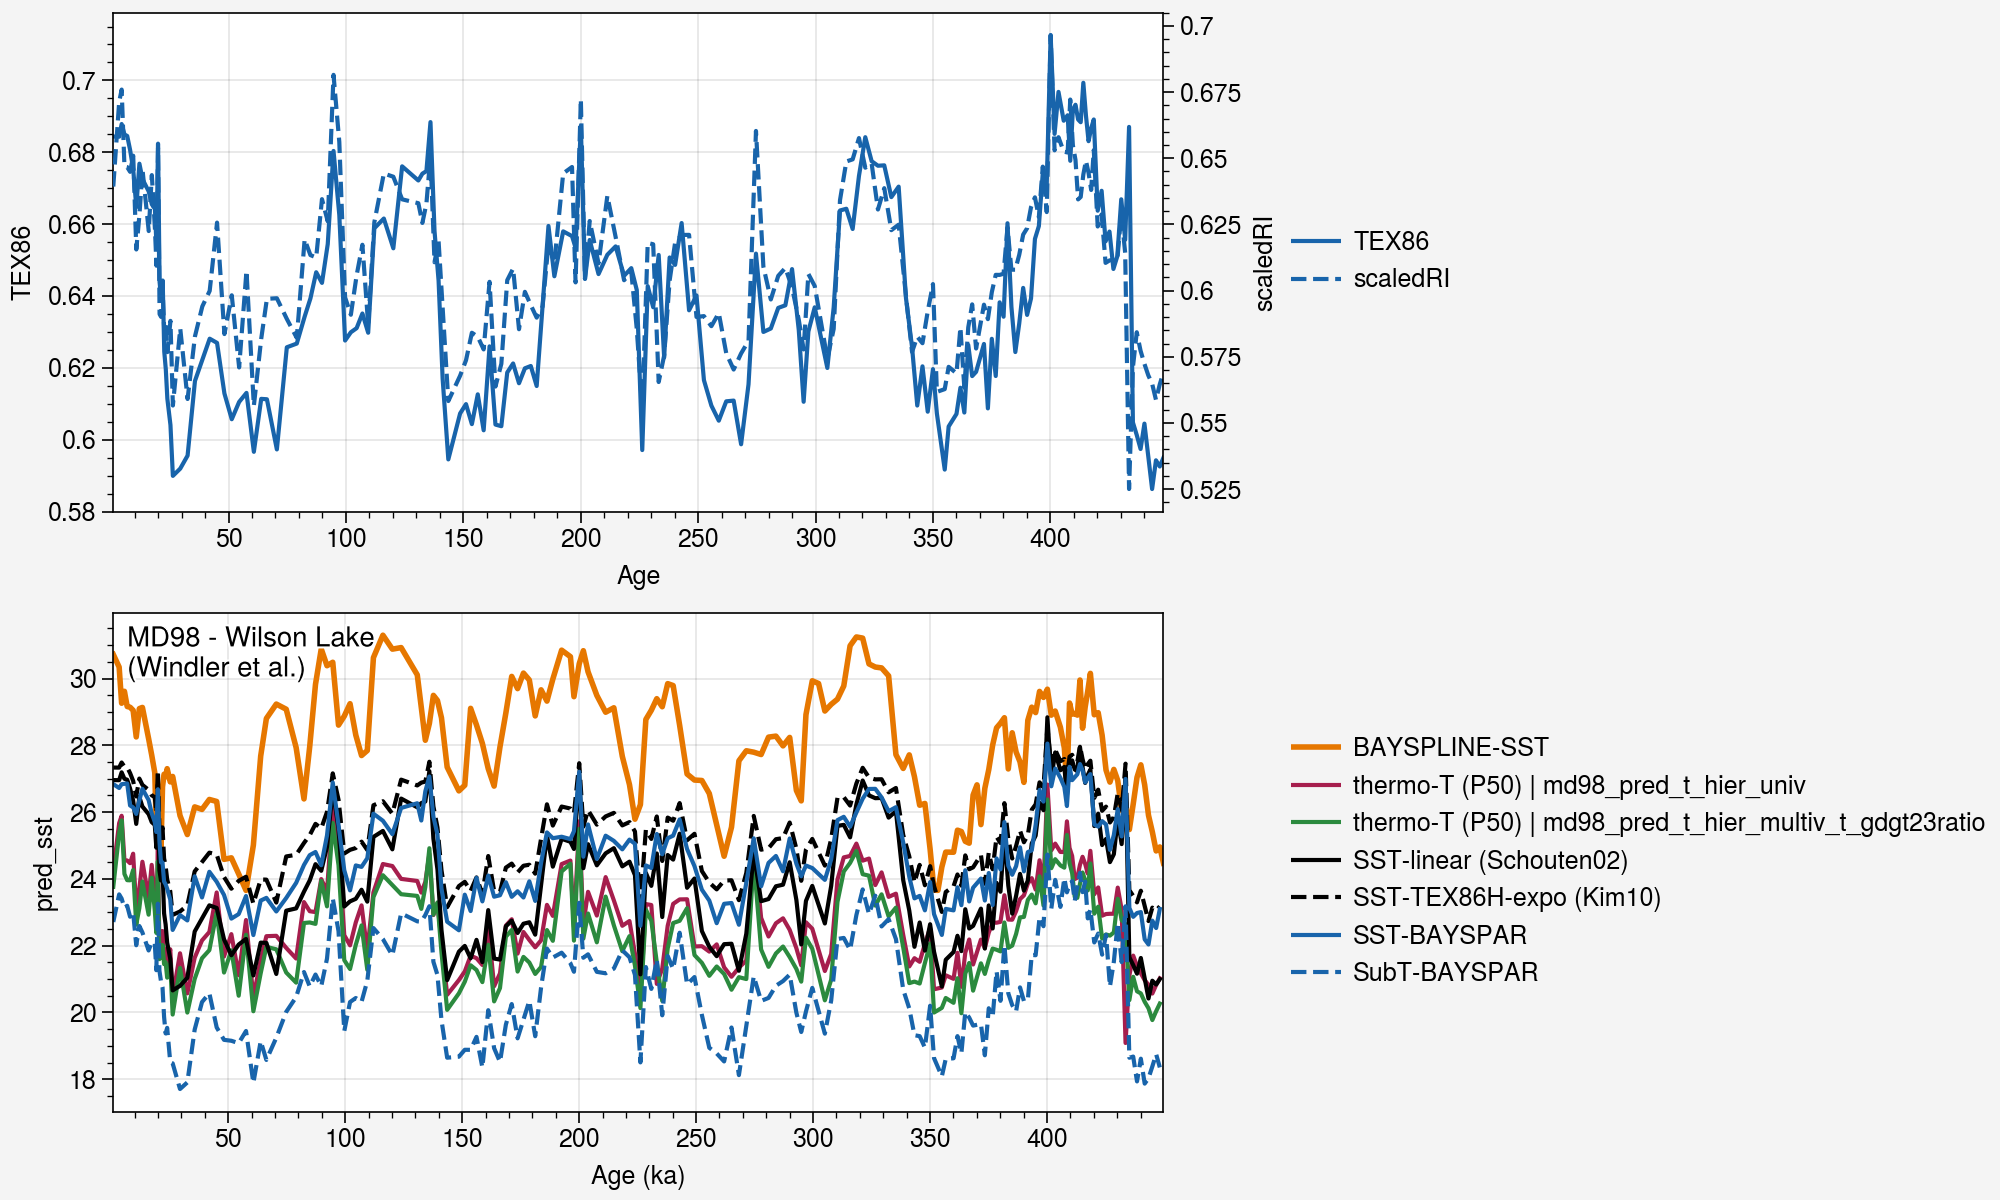

In [36]:
array = [
    [1,1],
    [2,2]
]
fig, axs = plot.subplots(array,figsize=(10,6),
                         share=0)
sel_idx = md98_tex_df['TEX86']>0.58
plot_data = md98_tex_df[md98_tex_df['TEX86']>0.58].reset_index(drop=True).copy()

ax = axs[0]

plot_x = plot_data['Age']*1000
plot_y = plot_data['TEX86']
ax2 = ax.twinx()
plot_y2 = plot_data['scaledRI']
ax.plot(plot_x, plot_y, color='blue9', ls='-',
        label='TEX86')
ax2.plot(plot_x, plot_y2, color='blue9', ls='--',
        label='scaledRI')
ax.set_ylabel('TEX86')
ax2.set_ylabel('scaledRI')
h, l = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h+h2, l+l2, loc='r', ncols=1, fontsize=8, frameon=False)


ax = axs[1]

plot_x = md98_uk_df['Age']*1000
plot_y = md98_uk_df['pred_sst']
ax.plot(plot_x, plot_y, color='yellow9', lw=2,
        label='BAYSPLINE-SST')

md98_pred_t_post_list = [
    # md98_pred_t_joint_culmeso_univ_post_ds,
    # md98_pred_t_joint_culmesocore_univ_post_ds,
    md98_pred_t_hier_univ_post_ds,
    # md98_pred_t_hier_multiv_t_only_post_ds,
    md98_pred_t_hier_multiv_t_gdgt23ratio_post_ds]

name_list = [
    # 'md98_pred_t_jnt_culmeso_univ',
    # 'md98_pred_t_jnt_culmesocore_univ',
    'md98_pred_t_hier_univ',
    # 'md98_pred_t_hier_multiv_t_only',
    'md98_pred_t_hier_multiv_t_gdgt23ratio']
colors = [
    # 'lime9', 'lime9', 
    'pink9',
    # 'yellow9', 
    'green9']
lines = [
    # '--','-',
    '-',
    # '-',
    '-']
for i, md98_pred_t_post_ds in enumerate(md98_pred_t_post_list):
    ###md98_uk_df['pred_sst']
    plot_data[f'{name_list[i]}_P50'] = md98_pred_t_post_ds['t_est'].quantile(0.5, dim=['draw','dim_2']).values[sel_idx]
    plot_data[f'{name_list[i]}_P16'] = md98_pred_t_post_ds['t_est'].quantile(0.16, dim=['draw','dim_2']).values[sel_idx]
    plot_data[f'{name_list[i]}_P84'] = md98_pred_t_post_ds['t_est'].quantile(0.84, dim=['draw','dim_2']).values[sel_idx]

    plot_x = plot_data['Age']*1000
    plot_y = plot_data[f'{name_list[i]}_P50']
    ax.plot(plot_x, plot_y, color=colors[i], ls=lines[i],
            label=f'thermo-T (P50) | {name_list[i]}')
    


###### plot PETM data
ax.plot(plot_data['Age']*1000, plot_data['SST_Schouten02'],
              c='k',label='SST-linear (Schouten02)')
ax.plot(plot_data['Age']*1000, plot_data['SST_Kim10'],
                c='k',ls='--',label='SST-TEX86H-expo (Kim10)')
ax.plot(plot_data['Age']*1000, plot_data['SST_bsr'],
                c='blue9',ls='-',label='SST-BAYSPAR')
ax.plot(plot_data['Age']*1000, plot_data['subT_bsr'],
                c='blue9',ls='--',label='SubT-BAYSPAR')

h, l = ax.get_legend_handles_labels()
ax.legend(h, l, loc='r', ncols=1, fontsize=8, frameon=False)

ax.format(
    xlabel='Age (ka)',
    ultitle='MD98 - Wilson Lake\n(Windler et al.)'
)


In [44]:
odp1146_tex_df = PhanTEX_df[PhanTEX_df['SiteName']=='ODP1146'].reset_index(drop=True)

odp1146_tex_df['thermoT_linear'] = (odp1146_tex_df['TEX86'] - intercept)/slope
odp1146_tex_df['SST_Schouten02'] = predictSSTfromTEX(odp1146_tex_df['TEX86'],method_name='schouteN_meso002')
odp1146_tex_df['SST_Kim10'] = predictSSTfromTEX(odp1146_tex_df['TEX86'],method_name='kim2010_tex86H')

odp1146_tex_tolerance = np.std(odp1146_tex_df['TEX86'], ddof=1) * 2
selLat = odp1146_tex_df['ModLat'].values[0]
selLon = odp1146_tex_df['ModLon'].values[0]
odp1146_tex_df['SST_bsr'] = bsr.predict_seatemp(odp1146_tex_df['TEX86'],
                                             lat=selLat,lon=selLon,
                                             prior_mean=18,prior_std=6,
                                             temptype='sst',
                                             nens=100).percentile(50)
odp1146_tex_df['subT_bsr'] = bsr.predict_seatemp(odp1146_tex_df['TEX86'],
                                             lat=selLat,lon=selLon,
                                             prior_mean=18,prior_std=6,
                                             temptype='subt',
                                             nens=100).percentile(50)

odp1146_uk_df = PhanSST_df[PhanSST_df['SiteName']=='ODP1146'][PhanSST_df['ProxyType']=='uk'].reset_index(drop=True)
odp1146_uk_df['pred_sst'] = bsl.predict_sst(odp1146_uk_df['ProxyValue'],prior_std=6).percentile(50)


100%|██████████| 500/500 [00:28<00:00, 17.74it/s]


In [45]:
odp1146_uk_df

,SampleID,SiteName,SiteHole,MBSF,MCD,SampleDepth,Formation,Country,ContinentOcean,ModLat,...,Cren,Crenisomer,BIT,dRI,MI,LeadAuthor,Year,PublicationDOI,DataDOI,pred_sst
0,NaN,ODP1146,NaN,NaN,0.045,NaN,NaN,NaN,pa,19.46,...,NaN,NaN,NaN,NaN,NaN,Herbert,2010,https://doi.org/10.1126/science.1185435,NaN,28.084384
1,NaN,ODP1146,NaN,NaN,0.535,NaN,NaN,NaN,pa,19.46,...,NaN,NaN,NaN,NaN,NaN,Herbert,2010,https://doi.org/10.1126/science.1185435,NaN,27.840819
2,NaN,ODP1146,NaN,NaN,1.035,NaN,NaN,NaN,pa,19.46,...,NaN,NaN,NaN,NaN,NaN,Herbert,2010,https://doi.org/10.1126/science.1185435,NaN,25.165452
3,NaN,ODP1146,NaN,NaN,1.545,NaN,NaN,NaN,pa,19.46,...,NaN,NaN,NaN,NaN,NaN,Herbert,2010,https://doi.org/10.1126/science.1185435,NaN,23.693898
4,NaN,ODP1146,NaN,NaN,2.045,NaN,NaN,NaN,pa,19.46,...,NaN,NaN,NaN,NaN,NaN,Herbert,2010,https://doi.org/10.1126/science.1185435,NaN,23.686136
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1502,NaN,ODP1146,B,NaN,234.570,NaN,NaN,NaN,pa,19.46,...,NaN,NaN,NaN,NaN,NaN,Dowsett,2017,https://doi.org/10.5066/F7959G1S,NaN,30.599217
1503,NaN,ODP1146,B,NaN,234.770,NaN,NaN,NaN,pa,19.46,...,NaN,NaN,NaN,NaN,NaN,Dowsett,2017,https://doi.org/10.5066/F7959G1S,NaN,30.449286
1504,NaN,ODP1146,B,NaN,234.950,NaN,NaN,NaN,pa,19.46,...,NaN,NaN,NaN,NaN,NaN,Dowsett,2017,https://doi.org/10.5066/F7959G1S,NaN,30.199776
1505,NaN,ODP1146,B,NaN,235.130,NaN,NaN,NaN,pa,19.46,...,NaN,NaN,NaN,NaN,NaN,Dowsett,2017,https://doi.org/10.5066/F7959G1S,NaN,29.376076


In [41]:
set_mu_t_prior = 26.0

# n_draws = len(joint_cul_meso_post_ds.draw)
# M_reduced = 100
# # Random subset of draw indices (or use stratified sampling)
# subset_indices = np.random.choice(n_draws, size=M_reduced, replace=False)
# data = {
#     "N_downcore": len(odp1146_tex_df),
#     "scaledRI_downcore": odp1146_tex_df['scaledRI'].astype(float).tolist(),
#     "prior_mu_t": [set_mu_t_prior] * len(odp1146_tex_df),
#     "prior_sigma_t": 6,
#     "M": M_reduced,
#     "t0_coretop": joint_cul_meso_post_ds["t0_culmeso"].values[subset_indices],
#     "k_coretop": joint_cul_meso_post_ds["k_culmeso"].values[subset_indices],
#     "b_coretop": joint_cul_meso_post_ds["b_culmeso"].values[subset_indices],
#     "sigma_scaledRI_coretop": joint_cul_meso_post_ds["sigma_scaledRI_culmeso"][subset_indices],
# }

# stan_file_name = 'invT_logistic_fixed_univ.stan'
# odp1146_pred_t_joint_culmeso_univ_post_ds, diag = get_invT_posterior(data, stan_file_name)

# n_draws = len(joint_cul_meso_coretop_post_ds.draw)
# M_reduced = 100
# # Random subset of draw indices (or use stratified sampling)
# subset_indices = np.random.choice(n_draws, size=M_reduced, replace=False)
# data = {
#     "N_downcore": len(odp1146_tex_df),
#     "scaledRI_downcore": odp1146_tex_df['scaledRI'].astype(float).tolist(),
#     "prior_mu_t": [set_mu_t_prior] * len(odp1146_tex_df),
#     "prior_sigma_t": 6,
#     "M": M_reduced,
#     "t0_coretop": joint_cul_meso_coretop_post_ds["t0_culmesocore"].values[subset_indices],
#     "k_coretop": joint_cul_meso_coretop_post_ds["k_culmesocore"].values[subset_indices],
#     "b_coretop": joint_cul_meso_coretop_post_ds["b_culmesocore"].values[subset_indices],
#     "sigma_scaledRI_coretop": joint_cul_meso_coretop_post_ds["sigma_scaledRI_coretop"][subset_indices],
# }

# stan_file_name = 'invT_logistic_fixed_univ.stan'
# odp1146_pred_t_joint_culmesocore_univ_post_ds, diag = get_invT_posterior(data, stan_file_name)

n_draws = len(joint_cul_meso_hier_coretop_post_ds.draw)
M_reduced = 100
# Random subset of draw indices (or use stratified sampling)
subset_indices = np.random.choice(n_draws, size=M_reduced, replace=False)
data = {
    "N_downcore": len(odp1146_tex_df),
    "scaledRI_downcore": odp1146_tex_df['scaledRI'].astype(float).tolist(),
    "prior_mu_t": [set_mu_t_prior] * len(odp1146_tex_df),
    "prior_sigma_t": 6,
    "M": M_reduced,
    "t0_coretop": joint_cul_meso_hier_coretop_post_ds["t0_coretop"].values[subset_indices],
    "k_coretop": joint_cul_meso_hier_coretop_post_ds["k_coretop"].values[subset_indices],
    "b_coretop": joint_cul_meso_hier_coretop_post_ds["b_coretop"].values[subset_indices],
    "sigma_scaledRI_coretop": joint_cul_meso_hier_coretop_post_ds["sigma_scaledRI_coretop"][subset_indices],
}

stan_file_name = 'invT_logistic_fixed_univ.stan'
odp1146_pred_t_hier_univ_post_ds, diag = get_invT_posterior(data, stan_file_name)


# n_draws = len(joint_cul_meso_hier_coretop_multiv_post_ds.draw)
# M_reduced = 100
# # Random subset of draw indices (or use stratified sampling)
# subset_indices = np.random.choice(n_draws, size=M_reduced, replace=False)
# data = {
#     "N_downcore": len(odp1146_tex_df),
#     "scaledRI_downcore": odp1146_tex_df['scaledRI'].astype(float).tolist(),
#     "prior_mu_t": [set_mu_t_prior] * len(odp1146_tex_df),
#     "prior_sigma_t": 6,
#     "M": M_reduced,
#     "t0_coretop": joint_cul_meso_hier_coretop_multiv_post_ds["t0_coretop"].values[subset_indices],
#     "k_coretop": joint_cul_meso_hier_coretop_multiv_post_ds["k_coretop"].values[subset_indices],
#     "b_coretop": joint_cul_meso_hier_coretop_multiv_post_ds["b_coretop"].values[subset_indices],
#     "sigma_scaledRI_coretop": joint_cul_meso_hier_coretop_multiv_post_ds["sigma_scaledRI_coretop"][subset_indices],
# }


# stan_file_name = 'invT_logistic_fixed_univ.stan'
# odp1146_pred_t_hier_multiv_t_only_post_ds, diag = get_invT_posterior(data, stan_file_name)

n_draws = len(joint_cul_meso_hier_coretop_multiv_post_ds.draw)
M_reduced = 100
# Random subset of draw indices (or use stratified sampling)
subset_indices = np.random.choice(n_draws, size=M_reduced, replace=False)
data = {
    "N_downcore": len(odp1146_tex_df),
    "scaledRI_downcore": odp1146_tex_df['scaledRI'].values,
    "prior_mu_t": [set_mu_t_prior] * len(odp1146_tex_df),
    "prior_sigma_t": 6,
    "gdgt23ratio_downcore": odp1146_tex_df['gdgt23ratio'].values,
    
    "M": M_reduced,
    "t0_coretop": joint_cul_meso_hier_coretop_multiv_post_ds["t0_coretop"].values[subset_indices],
    "k_coretop": joint_cul_meso_hier_coretop_multiv_post_ds["k_coretop"].values[subset_indices],
    "b_coretop": joint_cul_meso_hier_coretop_multiv_post_ds["b_coretop"].values[subset_indices],
    "sigma_scaledRI_coretop": joint_cul_meso_hier_coretop_multiv_post_ds["sigma_scaledRI_coretop"][subset_indices],
    "beta0_gdgt23ratio_coretop": joint_cul_meso_hier_coretop_multiv_post_ds["beta0_gdgt23ratio_coretop"].values[subset_indices], 
    
}


stan_file_name = 'invT_logistic_fixed_multiv.stan'
odp1146_pred_t_hier_multiv_t_gdgt23ratio_post_ds, diag = get_invT_posterior(data, stan_file_name)

07:24:07 - cmdstanpy - INFO - Chain [1] start processing
07:24:07 - cmdstanpy - INFO - Chain [2] start processing
07:24:07 - cmdstanpy - INFO - Chain [3] start processing
07:24:07 - cmdstanpy - INFO - Chain [4] start processing


Chain [1] method = sample (Default)
Chain [1] sample
Chain [1] num_samples = 1000 (Default)
Chain [1] num_warmup = 500
Chain [1] save_warmup = 0 (Default)
Chain [1] thin = 1 (Default)
Chain [1] adapt
Chain [1] engaged = 1 (Default)
Chain [1] gamma = 0.050000000000000003 (Default)
Chain [1] delta = 0.80000000000000004 (Default)
Chain [1] kappa = 0.75 (Default)
Chain [1] t0 = 10 (Default)
Chain [1] init_buffer = 75 (Default)
Chain [1] term_buffer = 50 (Default)
Chain [1] window = 25 (Default)
Chain [2] method = sample (Default)
Chain [2] sample
Chain [2] num_samples = 1000 (Default)
Chain [2] num_warmup = 500
Chain [2] save_warmup = 0 (Default)
Chain [2] thin = 1 (Default)
Chain [2] adapt
Chain [2] engaged = 1 (Default)
Chain [2] gamma = 0.050000000000000003 (Default)
Chain [2] delta = 0.80000000000000004 (Default)
Chain [2] kappa = 0.75 (Default)
Chain [2] t0 = 10 (Default)
Chain [2] init_buffer = 75 (Default)
Chain [2] term_buffer = 50 (Default)
Chain [2] window = 25 (Default)
Chain [2

07:27:19 - cmdstanpy - INFO - Chain [2] done processing


Chain [2] Iteration: 1500 / 1500 [100%]  (Sampling)
Chain [2] 
Chain [2] Elapsed Time: 106.41 seconds (Warm-up)
Chain [2] 85.644 seconds (Sampling)
Chain [2] 192.054 seconds (Total)
Chain [2] 
Chain [2] 
Chain [1] Iteration: 1100 / 1500 [ 73%]  (Sampling)
Chain [4] Iteration: 1000 / 1500 [ 66%]  (Sampling)
Chain [1] Iteration: 1200 / 1500 [ 80%]  (Sampling)
Chain [3] Iteration:  800 / 1500 [ 53%]  (Sampling)
Chain [1] Iteration: 1300 / 1500 [ 86%]  (Sampling)
Chain [4] Iteration: 1100 / 1500 [ 73%]  (Sampling)
Chain [1] Iteration: 1400 / 1500 [ 93%]  (Sampling)
Chain [3] Iteration:  900 / 1500 [ 60%]  (Sampling)


07:27:50 - cmdstanpy - INFO - Chain [1] done processing


...

Chain [4] Iteration: 1500 / 1500 [100%]  (Sampling)
Chain [4] 
Chain [4] Elapsed Time: 54.451 seconds (Warm-up)
Chain [4] 85.799 seconds (Sampling)
Chain [4] 140.25 seconds (Total)
Chain [4] 
Chain [4] 


07:32:13 - cmdstanpy - INFO - Chain [2] done processing


Chain [2] Iteration: 1500 / 1500 [100%]  (Sampling)
Chain [2] 
Chain [2] Elapsed Time: 54.771 seconds (Warm-up)
Chain [2] 86.74 seconds (Sampling)
Chain [2] 141.511 seconds (Total)
Chain [2] 
Chain [2] 


07:32:13 - cmdstanpy - INFO - Chain [1] done processing


Chain [1] Iteration: 1500 / 1500 [100%]  (Sampling)
Chain [1] 
Chain [1] Elapsed Time: 56.36 seconds (Warm-up)
Chain [1] 85.554 seconds (Sampling)
Chain [1] 141.914 seconds (Total)
Chain [1] 
Chain [1] 
Sampling completed in 189.4 seconds
⚠️ Sampling diagnostics warning:
 Processing csv files: /tmp/tmpg0appgur/invT_logistic_fixed_multivv543rjv1/invT_logistic_fixed_multiv-20250524072951_1.csv, /tmp/tmpg0appgur/invT_logistic_fixed_multivv543rjv1/invT_logistic_fixed_multiv-20250524072951_2.csv, /tmp/tmpg0appgur/invT_logistic_fixed_multivv543rjv1/invT_logistic_fixed_multiv-20250524072951_3.csv, /tmp/tmpg0appgur/invT_logistic_fixed_multivv543rjv1/invT_logistic_fixed_multiv-20250524072951_4.csv

Checking sampler transitions treedepth.
Treedepth satisfactory for all transitions.

Checking sampler transitions for divergences.
No divergent transitions found.

Checking E-BFMI - sampler transitions HMC potential energy.
E-BFMI satisfactory.

Effective sample size satisfactory.

Split R-hat values

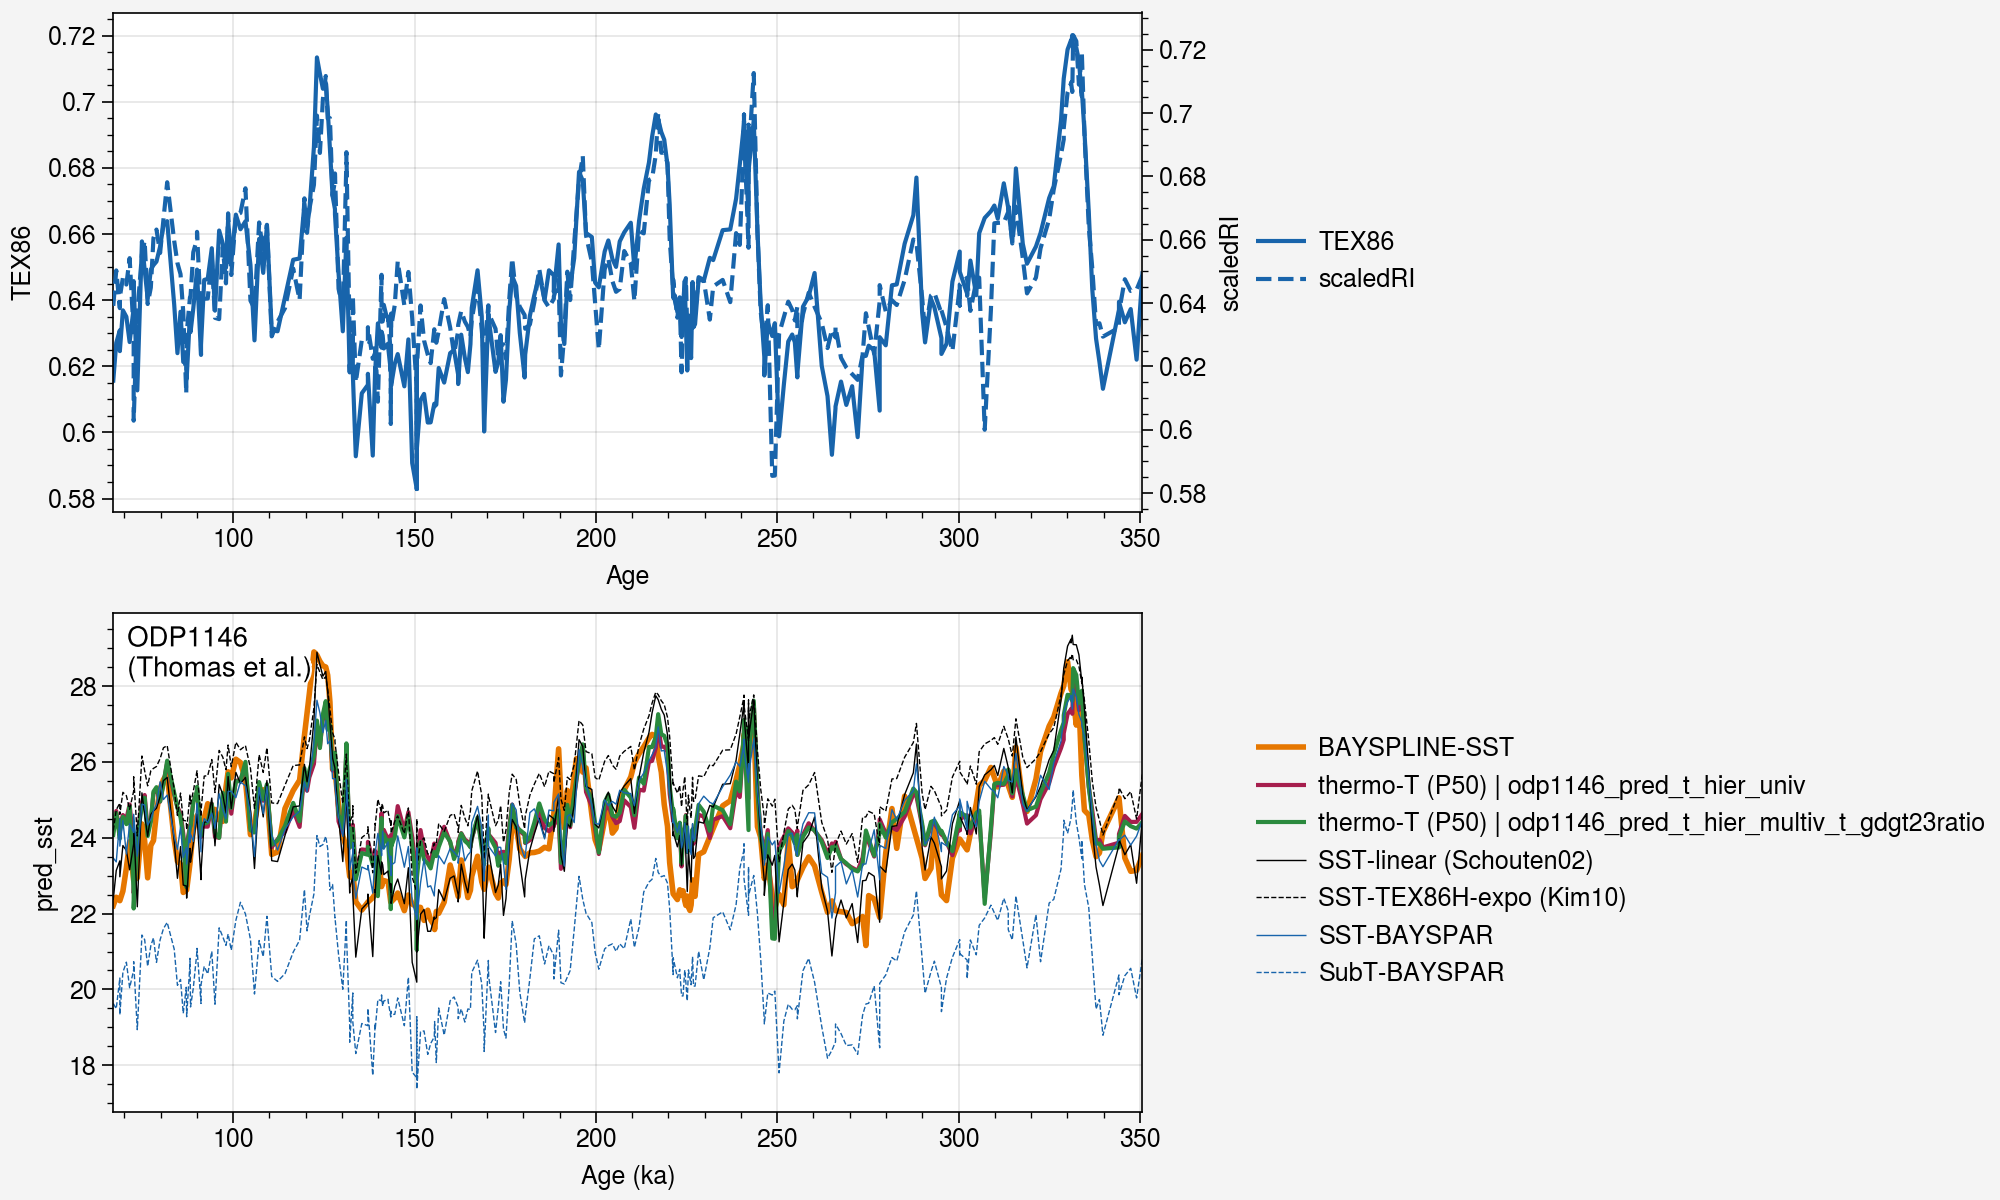

In [53]:
array = [
    [1,1],
    [2,2]
]
fig, axs = plot.subplots(array,figsize=(10,6),
                         share=0)
sel_idx = odp1146_tex_df['TEX86']>0.58
plot_data = odp1146_tex_df[odp1146_tex_df['TEX86']>0.58].reset_index(drop=True).copy()

ax = axs[0]

plot_x = plot_data['Age']*1000
plot_y = plot_data['TEX86']
ax2 = ax.twinx()
plot_y2 = plot_data['scaledRI']
ax.plot(plot_x, plot_y, color='blue9', ls='-',
        label='TEX86')
ax2.plot(plot_x, plot_y2, color='blue9', ls='--',
        label='scaledRI')
ax.set_ylabel('TEX86')
ax2.set_ylabel('scaledRI')
h, l = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h+h2, l+l2, loc='r', ncols=1, fontsize=8, frameon=False)


ax = axs[1]
plot_uk_data = odp1146_uk_df[odp1146_uk_df['LeadAuthor']=='Thomas'].reset_index(drop=True).copy()
plot_x = plot_uk_data['Age']*1000
plot_y = plot_uk_data['pred_sst']
ax.plot(plot_x, plot_y, color='yellow9', lw=2,
        label='BAYSPLINE-SST')

odp1146_pred_t_post_list = [
    # odp1146_pred_t_joint_culmeso_univ_post_ds,
    # odp1146_pred_t_joint_culmesocore_univ_post_ds,
    odp1146_pred_t_hier_univ_post_ds,
    # odp1146_pred_t_hier_multiv_t_only_post_ds,
    odp1146_pred_t_hier_multiv_t_gdgt23ratio_post_ds]

name_list = [
    # 'odp1146_pred_t_jnt_culmeso_univ',
    # 'odp1146_pred_t_jnt_culmesocore_univ',
    'odp1146_pred_t_hier_univ',
    # 'odp1146_pred_t_hier_multiv_t_only',
    'odp1146_pred_t_hier_multiv_t_gdgt23ratio']
colors = [
    # 'lime9', 'lime9', 
    'pink9',
    # 'yellow9', 
    'green9']
lines = [
    # '--','-',
    '-',
    # '-',
    '-']
for i, odp1146_pred_t_post_ds in enumerate(odp1146_pred_t_post_list):
    ###odp1146_uk_df['pred_sst']
    plot_data[f'{name_list[i]}_P50'] = odp1146_pred_t_post_ds['t_est'].quantile(0.5, dim=['draw','dim_2']).values[sel_idx]
    plot_data[f'{name_list[i]}_P16'] = odp1146_pred_t_post_ds['t_est'].quantile(0.16, dim=['draw','dim_2']).values[sel_idx]
    plot_data[f'{name_list[i]}_P84'] = odp1146_pred_t_post_ds['t_est'].quantile(0.84, dim=['draw','dim_2']).values[sel_idx]

    plot_x = plot_data['Age']*1000
    plot_y = plot_data[f'{name_list[i]}_P50']
    ax.plot(plot_x, plot_y, color=colors[i], ls=lines[i],
            label=f'thermo-T (P50) | {name_list[i]}')
    


###### plot previous model estimates
ax.plot(plot_data['Age']*1000, plot_data['SST_Schouten02'],
              c='k',lw=0.5,label='SST-linear (Schouten02)')
ax.plot(plot_data['Age']*1000, plot_data['SST_Kim10'],
                c='k',ls='--',lw=0.5,label='SST-TEX86H-expo (Kim10)')
ax.plot(plot_data['Age']*1000, plot_data['SST_bsr'],
                c='blue9',ls='-',lw=0.5,label='SST-BAYSPAR')
ax.plot(plot_data['Age']*1000, plot_data['subT_bsr'],
                c='blue9',ls='--',lw=0.5,label='SubT-BAYSPAR')

h, l = ax.get_legend_handles_labels()
ax.legend(h, l, loc='r', ncols=1, fontsize=8, frameon=False)

ax.format(
    xlabel='Age (ka)',
    ultitle='ODP1146\n(Thomas et al.)'
)


NameError: name 'paleo_tex_df' is not defined

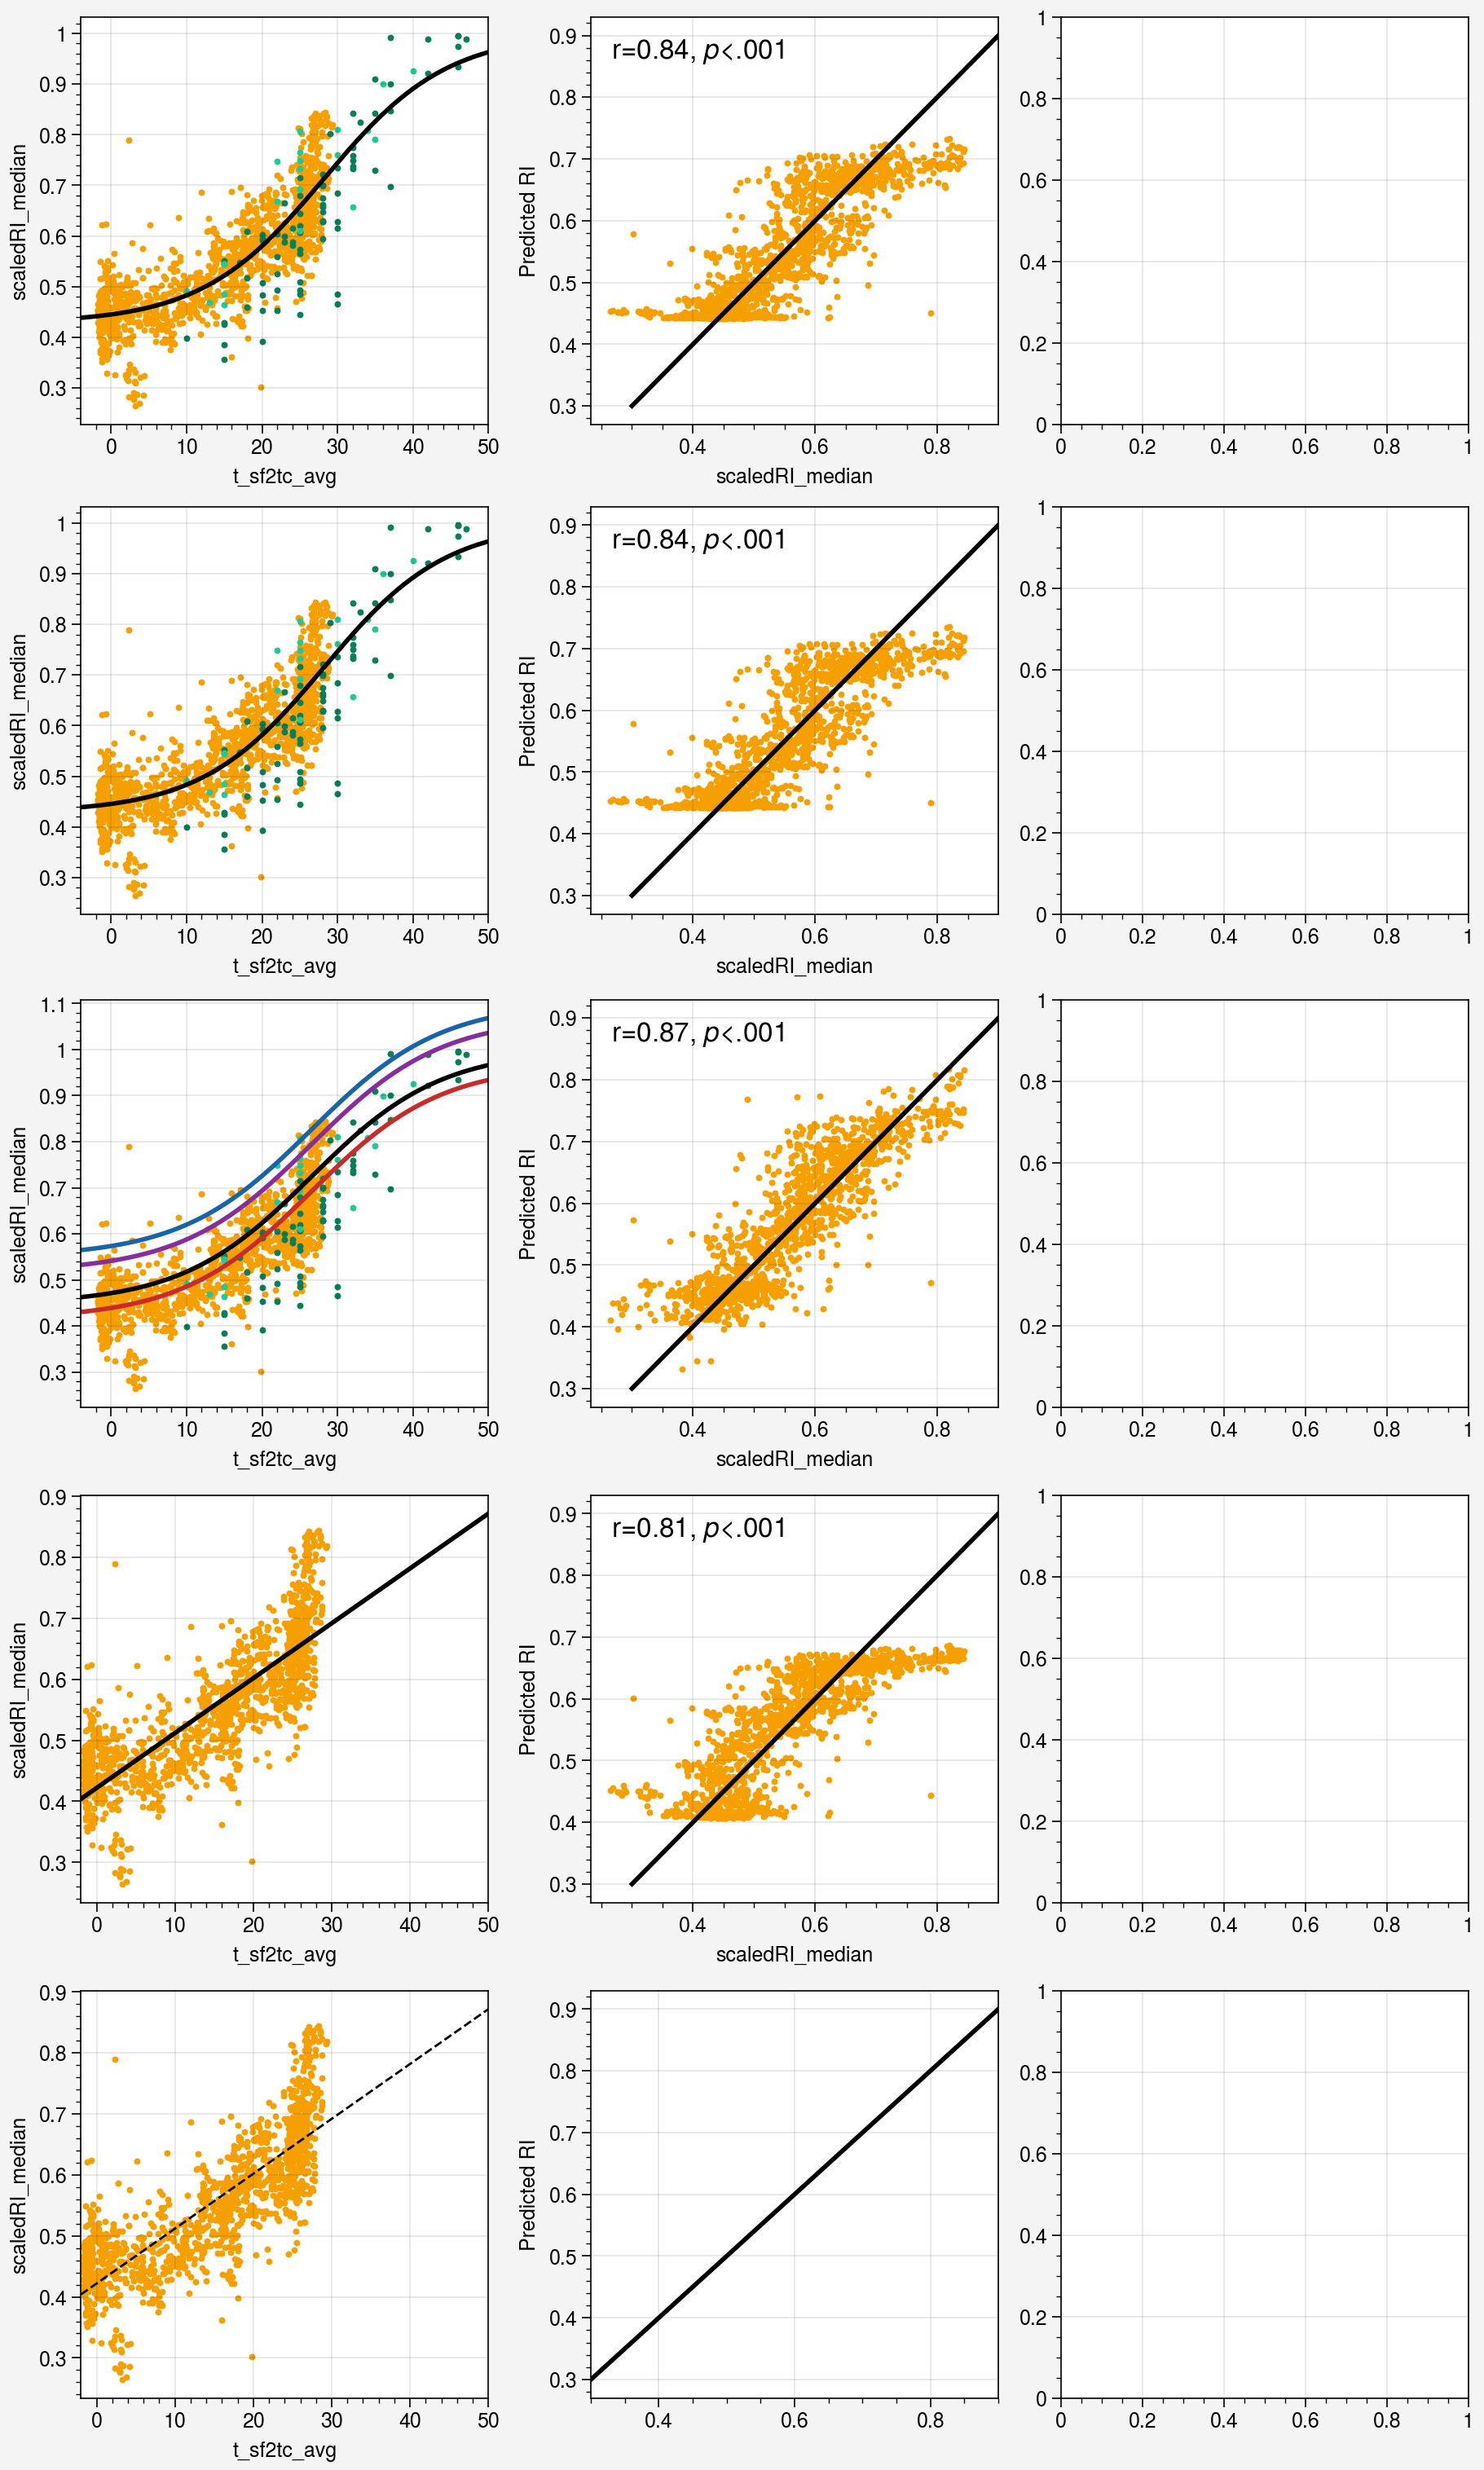

In [ ]:


fig, axs = plot.subplots(
    ncols=3, nrows=5,
    share=0,
)

# plot data in the first column
axs[:,0].scatter(coretop_df['t_sf2tc_avg'], coretop_df['scaledRI_median'],
           color='yellow7', s=5, label='Core-top data')
axs[:-2,0].scatter(culture_data_full['Temperature'], culture_data_full['scaledRI'],
              color='teal9', s=5, label='Culture data')
axs[:-2,0].scatter(meso_data_full['Temperature'], meso_data_full['scaledRI'],
                color='teal5', s=5, label='Mesocosm data')


post_ds_list = [
    joint_cul_meso_coretop_post_ds,
    joint_cul_meso_hier_coretop_post_ds,
    joint_cul_meso_hier_coretop_multiv_post_ds
]

for i, post_ds in enumerate(post_ds_list):
    if 't0_coretop' in post_ds.data_vars:
        p50_x0 = np.percentile(post_ds['t0_coretop'], 50)
        p50_k = np.percentile(post_ds['k_coretop'], 50)
        p50_b = np.percentile(post_ds['b_coretop'], 50)
    elif 't0_culmesocore' in post_ds.data_vars:
        p50_x0 = np.percentile(post_ds['t0_culmesocore'], 50)
        p50_k = np.percentile(post_ds['k_culmesocore'], 50)
        p50_b = np.percentile(post_ds['b_culmesocore'], 50)
    else:
        p50_x0 = np.percentile(post_ds['t0_culmeso'], 50)
        p50_k = np.percentile(post_ds['k_culmeso'], 50)
        p50_b = np.percentile(post_ds['b_culmeso'], 50)
        
    xx = np.linspace(-4, 50, 200)
    y_logi = logistic_fixed_upper(xx, p50_x0, p50_k, p50_b)
    ax = axs[i,0]
    ax.plot(xx, y_logi, color='black', lw=2)
    
    if 'beta0_gdgt23ratio_coretop' in post_ds.data_vars:
        p50_beta0_gdgt23ratio = np.percentile(post_ds['beta0_gdgt23ratio_coretop'], 50)
        p50_beta0_no3_coretop = np.percentile(post_ds['beta0_no3_coretop'], 50)

        y_logi_corr = y_logi + p50_beta0_gdgt23ratio * 5
        y_logi_corr2 = y_logi + p50_beta0_no3_coretop * np.log10(0.001)
        y_logi_corr3 = y_logi_corr + p50_beta0_no3_coretop * np.log10(0.001)
        
        ax.plot(xx, y_logi_corr, lw=2, c='red9')
        ax.plot(xx, y_logi_corr2, lw=2, c='blue9')
        ax.plot(xx, y_logi_corr3, lw=2, c='grape9')

    

### add 1:1 lines for the right column
xxx = np.linspace(0.3, 0.9, 100)
axs[:,1].plot(xxx, xxx, color='black', lw=2)

p50_x0 = np.percentile(joint_cul_meso_coretop_post_ds['t0_culmesocore'], 50)
p50_k = np.percentile(joint_cul_meso_coretop_post_ds['k_culmesocore'], 50)
p50_b = np.percentile(joint_cul_meso_coretop_post_ds['b_culmesocore'], 50)

pred_RI = logistic_fixed_upper(coretop_df['t_sf2tc_avg'], p50_x0, p50_k, p50_b)

axs[0,1].scatter(coretop_df['scaledRI_median'], pred_RI,
              color='yellow7', s=5, label='Core-top data')
### spearman r and p-value
r, p = stats.pearsonr(coretop_df['scaledRI_median'], pred_RI)
axs[0,1].text(0.05, 0.95, f'r={r:.2f}, {label_pvalues(p)}',
            transform=axs[0,1].transAxes,
            fontsize=12,
            va='top',
            ha='left',)


p50_x0 = np.percentile(joint_cul_meso_hier_coretop_post_ds['t0_coretop'], 50)
p50_k = np.percentile(joint_cul_meso_hier_coretop_post_ds['k_coretop'], 50)
p50_b = np.percentile(joint_cul_meso_hier_coretop_post_ds['b_coretop'], 50)

pred_RI = logistic_fixed_upper(coretop_df['t_sf2tc_avg'], p50_x0, p50_k, p50_b)
axs[1,1].scatter(coretop_df['scaledRI_median'], pred_RI,
              color='yellow7', s=5, label='Core-top data')
### spearman r and p-value
r, p = stats.pearsonr(coretop_df['scaledRI_median'], pred_RI)
axs[1,1].text(0.05, 0.95, f'r={r:.2f}, {label_pvalues(p)}',
            transform=axs[1,1].transAxes,
            fontsize=12,
            va='top',
            ha='left',)

p50_x0 = np.percentile(joint_cul_meso_hier_coretop_multiv_post_ds['t0_coretop'], 50)
p50_k = np.percentile(joint_cul_meso_hier_coretop_multiv_post_ds['k_coretop'], 50)
p50_b = np.percentile(joint_cul_meso_hier_coretop_multiv_post_ds['b_coretop'], 50)
p50_beta0_gdgt23ratio = np.percentile(joint_cul_meso_hier_coretop_multiv_post_ds['beta0_gdgt23ratio_coretop'], 50)
p50_beta0_no3_coretop = np.percentile(joint_cul_meso_hier_coretop_multiv_post_ds['beta0_no3_coretop'], 50)

pred_RI = logistic_fixed_upper(coretop_df['t_sf2tc_avg'], p50_x0, p50_k, p50_b)
pred_RI += p50_beta0_gdgt23ratio * coretop_df['gdgt23ratio_median']
### correct for no3 if no3 < 2.7
idx_low_no3 = np.where(coretop_df['no3_sf2tc_avg']<=2.7)[0]
pred_RI[idx_low_no3] += p50_beta0_no3_coretop * np.log10(coretop_df['no3_sf2tc_avg'][idx_low_no3])

axs[2,1].scatter(coretop_df['scaledRI_median'], pred_RI,
              color='yellow7', s=5, label='Core-top data')


### spearman r and p-value
r, p = stats.pearsonr(coretop_df['scaledRI_median'], pred_RI)
axs[2,1].text(0.05, 0.95, f'r={r:.2f}, {label_pvalues(p)}',
            transform=axs[2,1].transAxes,
            fontsize=12,
            va='top',
            ha='left',)

axs[:,1].set_ylabel('Predicted RI')

### linear fit for the last row
ols = LinearRegression()
reg_x = coretop_df['t_sf2tc_avg'].values.reshape(-1,1)
ols.fit(reg_x, coretop_df['scaledRI_median'])

xx_sample = np.linspace(-2, 50, 100).reshape(-1,1)
y_lin = ols.predict(xx_sample)
axs[3,0].plot(xx_sample, y_lin, color='black', lw=2)
axs[4,0].plot(xx_sample, y_lin, color='black', lw=1, ls='--')

pred_RI = ols.predict(coretop_df['t_sf2tc_avg'].values.reshape(-1,1))
axs[3,1].scatter(coretop_df['scaledRI_median'], pred_RI,
              color='yellow7', s=5, label='Core-top data')
### spearman r and p-value
r, p = stats.pearsonr(coretop_df['scaledRI_median'], pred_RI)
axs[3,1].text(0.05, 0.95, f'r={r:.2f}, {label_pvalues(p)}',
            transform=axs[3,1].transAxes,
            fontsize=12,
            va='top',
            ha='left',)

slope = ols.coef_[0]
intercept = ols.intercept_
predT = (paleo_tex_df['scaledRI'] - intercept) / slope
axs[3,2].plot(paleo_tex_df['SampleDepth'], predT,
              c='yellow7',ls='-',label='predT from linear fit')

### exponential fit
ln_y = np.log(coretop_df['scaledRI_median'])
ols = LinearRegression()
reg_x = coretop_df['t_sf2tc_avg'].values.reshape(-1,1)
ols.fit(reg_x, ln_y)
xx_sample = np.linspace(-2, 50, 100).reshape(-1,1)
y_lin = ols.predict(xx_sample)
axs[4,0].plot(xx_sample, np.exp(y_lin), color='black', lw=2)
pred_RI = np.exp(ols.predict(coretop_df['t_sf2tc_avg'].values.reshape(-1,1)))
axs[4,1].scatter(coretop_df['scaledRI_median'], pred_RI,
              color='yellow7', s=5, label='Core-top data')
### spearman r and p-value
r, p = stats.pearsonr(coretop_df['scaledRI_median'], pred_RI)
axs[4,1].text(0.05, 0.95, f'r={r:.2f}, {label_pvalues(p)}',
            transform=axs[4,1].transAxes,
            fontsize=12,
            va='top',
            ha='left',)

slope = ols.coef_[0]
intercept = ols.intercept_
predT = (np.log(paleo_tex_df['scaledRI']) - intercept) / slope
axs[4,2].plot(paleo_tex_df['SampleDepth'], predT,
              c='yellow7',ls='-',label='predT from exp fit')

axs[:,1].format(
    xlim=(0.3, 0.9),
    ylim=(0.3, 0.9),
)

###### plot PETM data
axs[:,2].plot(paleo_tex_df['SampleDepth'], paleo_tex_df['SST_Schouten02'],
              c='k',label='SST-linear (Schouten02)')
axs[:,2].plot(paleo_tex_df['SampleDepth'], paleo_tex_df['SST_Kim10'],
                c='k',ls='--',label='SST-TEX86H-expo (Kim10)')
axs[:,2].plot(paleo_tex_df['SampleDepth'], paleo_tex_df['SST_bsr'],
                c='blue9',ls='-',label='SST-BAYSPAR')
axs[:,2].plot(paleo_tex_df['SampleDepth'], paleo_tex_df['subT_bsr'],
                c='blue9',ls='--',label='SubT-BAYSPAR')


### pred thermoT based on joint-cul-meso-coretop
ensem_thermoT = make_ensemble(paleo_tex_df['TEX86'],
              posterior=joint_cul_meso_coretop_post_ds,
              )
p50_ensem_thermoT = np.percentile(ensem_thermoT, 50, axis=0)
axs[0,2].plot(paleo_tex_df['SampleDepth'], p50_ensem_thermoT,
              c='yellow7',ls='-',label='joint-cul-meso-coretop')

ensemRI = make_ensemble(paleo_tex_df['TEX86'],
                posterior=joint_cul_meso_hier_coretop_post_ds,
                )
p50_ensem_thermoT = np.percentile(ensem_thermoT, 50, axis=0)
axs[1,2].plot(paleo_tex_df['SampleDepth'], p50_ensem_thermoT,
              c='yellow7',ls='-',label='joint-cul-meso-hier-coretop')

# a) pull out your paleo RI and factors
y_paleo = paleo_tex_df["scaledRI"].values        # shape (M,)
z_paleo = paleo_tex_df["gdgt23ratio"].values     # shape (M,)
gdgt23ratio_0 = np.full_like(z_paleo, 0)   # matches beta0_gdgt23ratio
no3_coretop_0 = np.full_like(z_paleo, 0)   
T_draws_base = make_ensemble(
    y= y_paleo,
    posterior = joint_cul_meso_hier_coretop_multiv_post_ds,
    gdgt23ratio_coretop = gdgt23ratio_0,     # matches beta0_gdgt23ratio
    no3_coretop = no3_coretop_0,   # matches beta0_no3_coretop
)

# c) summarize: e.g. point‐estimate = posterior median
T_mediaN_meso = np.percentile(T_draws_base, 50, axis=0)  # shape (M,)

# d) plot against depth
axs[2,2].plot(paleo_tex_df["SampleDepth"], T_mediaN_meso,
              color="yellow7", ls="-",
              label="Thermo T (posterior median)")

### varies no3 from 0.001, 0.01, 0.1,
### idx of data where SampleDepth.isbetween(97,109)
idx = np.where((paleo_tex_df['SampleDepth']>=96) & (paleo_tex_df['SampleDepth']<=110))[0]

for no3_val in [0.001, 0.01, 0.1]:
    aa_paleo = np.full_like(z_paleo[idx], np.log10(no3_val))                 

    T_draws = make_ensemble(
        y= y_paleo[idx],
        posterior = joint_cul_meso_hier_coretop_multiv_post_ds,
        gdgt23ratio_coretop = z_paleo[idx],     # matches beta0_gdgt23ratio
        no3_coretop = aa_paleo,   # matches beta0_no3_coretop
    )

    T_median = np.percentile(T_draws, 50, axis=0)  # shape (M,)

    plot_x = paleo_tex_df["SampleDepth"][idx].values
    axs[2,2].plot(plot_x, T_median,
                color="yellow7", ls="--",
                label="Thermo T (posterior median)")



In [ ]:
joint_cul_meso_coretop_post_ds

In [ ]:
fig, axs = plot.subplots(width=4, 
                         nrows=3,
                         share=0)
    

### plot logistic fits from P50 posterior


## plot data
axs[0].scatter(coretop_df['t_sf2tc_avg'], coretop_df['scaledRI_median'],
           color='black', s=5, label='Core-top data')

post_da = joint_cul_meso_hier_coretop_multiv_post_ds
p50_t0_3 = np.percentile(post_da['t0_coretop'], 50)
p50_k_3 = np.percentile(post_da['k_coretop'], 50)
p50_b_3 = np.percentile(post_da['b_coretop'], 50)
p50_beta0_gdgt23ratio = np.percentile(post_da['beta0_gdgt23ratio_coretop'], 50)
p50_beta0_no3_coretop = np.percentile(post_da['beta0_no3_coretop'], 50)

def logistic_fixed_upper(x, x0, k, b):
        """Logistic function with fixed upper limit."""
        return (1 - b) / (1 + np.exp(-k * (x - x0))) + b
    
xx = np.linspace(-4, 50, 200)
y_logi = logistic_fixed_upper(xx, p50_t0_3, p50_k_3, p50_b_3)
y_logi_corr = y_logi + p50_beta0_gdgt23ratio * 15
y_logi_corr2 = y_logi + p50_beta0_no3_coretop * np.log10(0.001)

ax = axs[0]
ax.plot(xx, y_logi, color='black', lw=2)
ax.plot(xx, y_logi_corr, color='black', lw=1, ls='--',
        label='Logistic fit (P50)')
ax.plot(xx, y_logi_corr2, color='black', lw=1, ls=':',
        label='Logistic fit (P50) + no3_coretop')

ax = axs[1]
coretop_df['scaledRI_logi-T_res'] = (
        coretop_df['scaledRI_median'] - logistic_fixed_upper(coretop_df['t_sf2tc_avg'], p50_t0_3, p50_k_3, p50_b_3)
)

RI_res = coretop_df['scaledRI_logi-T_lin-no3_res'].values
zz_sample = np.linspace(0,30, 200)
zz_pred = p50_beta0_gdgt23ratio * zz_sample
ax.scatter(coretop_df['gdgt23ratio_median'], RI_res,
           color='black', s=5, label='Core-top data')
ax.plot(zz_sample, zz_pred, color='black', lw=2)
ax.format(
        ylabel='RI residuals',
)

ax = axs[2]


ax.scatter(coretop_df['no3_sf2tc_avg'], 
           coretop_df['scaledRI_logi-T_res'],
                  color='black', s=5, label='Core-top data')



no3_coretop_sample = np.linspace(0.0001,2.7, 1000)
no3_coretop_pred = p50_beta0_no3_coretop * np.log10(no3_coretop_sample)
ax.plot(no3_coretop_sample, no3_coretop_pred, color='black', lw=2)

ax.format(
        xscale='log',
)


In [ ]:
p50_beta0_no3_coretop * -3

In [ ]:
plt.hist(coretop_df['no3_sf2tc_avg'],
         bins=[0.0001, 0.001, 0.01, 0.1, 1, 10,100],)
plt.xscale('log')

In [ ]:
array = [
    [1,1,1],
    [2,3,4],
    [5,6,7],
    [8,9,10]
]

fig, axs = plot.subplots(array,
                         share=False,
                         hratios=[2.8,1,1,1],
                         width=10)

xx = np.linspace(-2, 70, 200)

### plot data
ax = axs[0]
## plot coretop data
# ax.scatter(coretop_df['t_sf2tc_avg'], coretop_df['scaledRI_median'],
#            c='yellow5', mec='k', m='o', label='Core-top data')

# # plot culture data
# ax.scatter(culture_data_full['Temperature'], culture_data_full['scaledRI'],
#            c='teal7', mec='k', m='o', label='Culture data')
# # plot mesocosm data
# ax.scatter(meso_data_full['Temperature'], meso_data_full['scaledRI'],
#            c='teal3', mec='k', m='o', label='Mesocosm data')

### logistic fit for only coretop data with curve_fit from scipy

def logistic_fixed_upper(x, x0, k, b):
        """Logistic function with fixed upper limit."""
        return (1 - b) / (1 + np.exp(-k * (x - x0))) + b

p0 = [30, 0.1, 0.2]
bf = (0, [50, 1, 1])
popt_coretop, _ = curve_fit(logistic_fixed_upper, 
                            coretop_df['t_sf2tc_avg'], 
                            coretop_df['scaledRI_median'], p0=p0, bounds=bf)
t0_coretop, k_coretop, b_coretop = popt_coretop
# ax.plot(xx, logistic_fixed_upper(xx, t0_coretop, k_coretop, b_coretop),
#         color='k', ls='--', label='Core-top logistic fit')

# axs[1].axvline(t0_coretop, color='k', ls='--', lw=1.5, label='Core-top x0')
# axs[2].axvline(k_coretop, color='k', ls='--', lw=1.5, label='Core-top k')
# axs[3].axvline(b_coretop, color='k', ls='--', lw=1.5, label='Core-top b')

t0_post_p50 = np.percentile(joint_cul_meso_hier_coretop_post_ds['t0'], 50)
k_post_p50 = np.percentile(joint_cul_meso_hier_coretop_post_ds['k'], 50)
b_post_p50 = np.percentile(joint_cul_meso_hier_coretop_post_ds['b'], 50)

### plot fillbetween p5 to p95 from ensemble

predRI_ensemble = make_forward_ensemble(
        x=xx,
        posterior=joint_cul_meso_hier_coretop_post_ds,
        model_name='logistic_fixed_upper')
# plot the fill between p5 and p95

p5 = np.percentile(predRI_ensemble, 5, axis=1)
p95 = np.percentile(predRI_ensemble, 95, axis=1)
ax.fill_between(xx,
        p5,
        p95,
        color='teal7', alpha=0.5, label="95% confidence interval")


# plot the median


def logistic_fixed_upper(x, x0, k, b):
        """Logistic function with fixed upper limit."""
        return (1 - b) / (1 + np.exp(-k * (x - x0))) + b

ax.plot(xx, logistic_fixed_upper(xx, t0_post_p50, k_post_p50, b_post_p50),
        color='teal', lw=2, label='hier logistic fit')

t0_3_post_p50 = np.percentile(joint_cul_meso_hier_coretop_post_ds['t0_coretop'], 50)
k_3_post_p50 = np.percentile(joint_cul_meso_hier_coretop_post_ds['k_coretop'], 50)
b_3_post_p50 = np.percentile(joint_cul_meso_hier_coretop_post_ds['b_coretop'], 50)

ax.plot(xx, logistic_fixed_upper(xx, t0_3_post_p50, k_3_post_p50, b_3_post_p50),
        color='blue9', lw=1, label='hier coretop logistic fit')

predRI_ensemble = make_forward_ensemble(
        x=xx,
        posterior=joint_cul_meso_hier_coretop_post_ds,
        model_name='hier_coretop')
# plot the fill between p5 and p95

p5 = np.percentile(predRI_ensemble, 5, axis=1)
p95 = np.percentile(predRI_ensemble, 95, axis=1)
ax.plot(xx,p5, color='blue9', ls='--')
ax.plot(xx,p95, color='blue9', ls='--')

params = ['t0', 'k', 'b']

for i, param in enumerate(params):
    #histogram of the posterior distribution
        axs[i+1].hist(joint_cul_meso_hier_coretop_post_ds[param], 
                bins=100, density=True, color='teal', alpha=0.5, 
                label=f'culture-meso posteriors (hier)')

        axs[i+1].hist(joint_cul_meso_hier_coretop_post_ds[param+'_coretop'], 
                bins=100, density=True, color='blue9', alpha=0.5, label='coretop posteriors (hier)')
        
        x_min = joint_cul_meso_hier_coretop_post_ds[param].min()
        x_max = joint_cul_meso_hier_coretop_post_ds[param].max()
        axs[i+1].set_xlim(x_min, x_max)
        
        axs[i+4].fill_betweenx(
                [0, [0.2,3,3][i]],x_min, x_max,
                color='gray', alpha=0.25,
                label='posterior range')

# create priors for culture+mesocosm
#   // Priors for culture+mesocosm
#   x0    ~ normal(20, 20) T[-1.8,];
#   k     ~ beta(2, 5);
#   b     ~ beta(2, 5);

t0_prior = truncnorm.rvs(a=-1.8, b=np.inf, loc=30, scale=10, size=4000)
k_prior = stats.beta.rvs(2, 5, size=4000, random_state=42)
b_prior = stats.beta.rvs(2, 5, size=4000, random_state=42)

# compute density
kde_x0 = gaussian_kde(t0_prior)
xs = np.linspace(t0_prior.min(), t0_prior.max(), 1000)
axs[1].plot(xs, kde_x0(xs), color='k', label='param priors')
axs[2,0].plot(xs, kde_x0(xs), color='k', label='param priors')
### add mathematical expression to show the prior as Truncated normal
axs[2,0].text(0.95, 0.95, r'$x_0 \sim \mathcal{N}(30, 10) T[-1.8,]$', fontsize=10,
            ha='right', va='top', transform=axs[2,0].transAxes)

kde_k = gaussian_kde(k_prior)
xs = np.linspace(k_prior.min(), k_prior.max(), 1000)
axs[2].plot(xs, kde_k(xs), color='k', label='param priors')
axs[2,1].plot(xs, kde_k(xs), color='k', label='param priors')
### add mathematical expression to show the prior as Beta
axs[2,1].text(0.95, 0.95, r'$k \sim \mathcal{B}(2, 5)$', fontsize=10,
            ha='right', va='top', transform=axs[2,1].transAxes)

kde_b = gaussian_kde(b_prior)
xs = np.linspace(b_prior.min(), b_prior.max(), 1000)
axs[3].plot(xs, kde_b(xs), color='k', label='param priors')
axs[2,2].plot(xs, kde_b(xs), color='k', label='param priors')
### add mathematical expression to show the prior as Beta
axs[2,2].text(0.95, 0.95, r'$b \sim \mathcal{B}(2, 5)$', fontsize=10,
                ha='right', va='top', transform=axs[2,2].transAxes)

## testing half-cauchy for k and b
# k_prior_half_cauchy = stats.halfcauchy.rvs(loc=0.5, scale=1, size=4000)
# kde_k_half_cauchy = gaussian_kde(k_prior_half_cauchy)
# xs = np.linspace(k_prior_half_cauchy.min(), k_prior_half_cauchy.max(), 1000)
# axs[2,1].plot(xs, kde_k_half_cauchy(xs), color='k', label='priors', ls='--')


# b_prior_half_cauchy = stats.halfcauchy.rvs(loc=0.5, scale=1, size=4000)
# kde_b_half_cauchy = gaussian_kde(b_prior_half_cauchy)
# xs = np.linspace(b_prior_half_cauchy.min(), b_prior_half_cauchy.max(), 1000)
# axs[2,2].plot(xs, kde_b_half_cauchy(xs), color='k', label='priors', ls='--')


## testing gamma for k and b
# k_prior_gamma = stats.gamma.rvs(2, loc=0.5, scale=0.5, size=4000)

# kde_k_gamma = gaussian_kde(k_prior_gamma)
# xs = np.linspace(k_prior_gamma.min(), k_prior_gamma.max(), 1000)
# axs[2,1].plot(xs, kde_k_gamma(xs), color='k', label='priors', ls='--')



#### plot joint_cul_meso for comparison
t0_post_p50 = np.percentile(joint_cul_meso_post_ds['t0'], 50)
k_post_p50 = np.percentile(joint_cul_meso_post_ds['k'], 50)
b_post_p50 = np.percentile(joint_cul_meso_post_ds['b'], 50)
# axs[0].plot(xx, logistic_fixed_upper(xx, t0_post_p50, k_post_p50, b_post_p50),
#         color='teal', ls='--', label='Joint culture+mesocosm fit')

for i, param in enumerate(['t0', 'k', 'b']):
    axs[i+1].hist(joint_cul_meso_post_ds[param], 
                bins=100, density=True, color='teal', alpha=0.75,
                histtype='step', 
                label=f'joint-cul-meso posteriors')

### plot joint_cul_meso_coretop for comparison
t0_post_p50 = np.percentile(joint_cul_meso_coretop_post_ds['t0'], 50)
k_post_p50 = np.percentile(joint_cul_meso_coretop_post_ds['k'], 50)
b_post_p50 = np.percentile(joint_cul_meso_coretop_post_ds['b'], 50)
# axs[0].plot(xx, logistic_fixed_upper(xx, t0_post_p50, k_post_p50, b_post_p50),
#         color='orange9', ls='--', label='Joint culture+mesocosm+coretop fit')

predRI_ensemble = make_forward_ensemble(
       x=xx,
       posterior=joint_cul_meso_coretop_post_ds,
       model_name='logistic_fixed_upper',
)
### p5-p95 CI interval
p5 = np.percentile(predRI_ensemble, 5, axis=1)
p95 = np.percentile(predRI_ensemble, 95, axis=1)
axs[0].plot(xx, p5, color='orange9', ls='--')
axs[0].plot(xx, p95, color='orange9', ls='--')


display(predRI_ensemble)
for i, param in enumerate(['t0', 'k', 'b']):
        axs[i+1].hist(joint_cul_meso_coretop_post_ds[param], 
                        bins=100, density=True, color='orange9', alpha=0.75,
                        histtype='step', 
                        label=f'joint-cul-meso-coretop posteriors')

### visualize hyperpriors and sigma_x0, sigma_k, sigma_b posteriors

## priors for sigma_x0, sigma_k, sigma_b


sigma_t0_prior = stats.cauchy(0,1).rvs(1000,random_state=42)
sigma_k_prior = stats.cauchy(0,1).rvs(1000,random_state=42)
sigma_b_prior = stats.cauchy(0,1).rvs(1000,random_state=42)

kde_sigma_x0 = gaussian_kde(sigma_t0_prior)
xs = np.linspace(sigma_t0_prior.min(), sigma_t0_prior.max(), 1000)
axs[3,0].plot(xs, kde_sigma_x0(xs), color='k', label='hyperparam priors')
axs[3,0].hist(joint_cul_meso_hier_coretop_post_ds['sigma_x0'],
                bins=100, density=True, color='teal', alpha=0.5,
                label='hyperparam posteriors')
## add mathematical expression to show the prior as Cauchy
axs[3,0].text(0.95, 0.95, r'$\sigma_{x_0} \sim \mathcal{C}(0, 1)$', fontsize=10,
                ha='right', va='top', transform=axs[3,0].transAxes)

kde_sigma_k = gaussian_kde(sigma_k_prior)
xs = np.linspace(sigma_k_prior.min(), sigma_k_prior.max(), 1000)
axs[3,1].plot(xs, kde_sigma_k(xs), color='k', label='hyperparam priors')
axs[3,1].hist(joint_cul_meso_hier_coretop_post_ds['sigma_b'],
                bins=100, density=True, color='teal', alpha=0.5,
                label='hyperparam posteriors')
## add mathematical expression to show the prior as Cauchy
axs[3,1].text(0.95, 0.95, r'$\sigma_{k} \sim \mathcal{C}(0, 1)$', fontsize=10,
                ha='right', va='top', transform=axs[3,1].transAxes)

kde_sigma_b = gaussian_kde(sigma_b_prior)
xs = np.linspace(sigma_b_prior.min(), sigma_b_prior.max(), 1000)
axs[3,2].plot(xs, kde_sigma_b(xs), color='k', label='hyperparam priors')
axs[3,2].hist(joint_cul_meso_hier_coretop_post_ds['sigma_k'],
                bins=100, density=True, color='teal', alpha=0.5,
                label='hyperparam posteriors')
## add mathematical expression to show the prior as Cauchy
axs[3,2].text(0.95, 0.95, r'$\sigma_{b} \sim \mathcal{C}(0, 1)$', fontsize=10,
                ha='right', va='top', transform=axs[3,2].transAxes)
        
h1, l1 = axs[0,0].get_legend_handles_labels()
axs[0,0].legend(loc='r',ncols=1)
h2, l2 = axs[1,0].get_legend_handles_labels()
axs[1,-1].legend(loc='r',ncols=1)
h3, l3 = axs[2,0].get_legend_handles_labels()
axs[2,-1].legend(loc='r',ncols=1)
h4, l4 = axs[3,0].get_legend_handles_labels()
axs[3,-1].legend(loc='r',ncols=1)

fig.format(
        rowlabels=['logistic fit','posteriors','priors','sigma posteriors'],
)

axs[1,:].set_yscale('log')
axs[1,:].format(ymin=1e-2)
for i, xmax in enumerate([15,5,5]):
        axs[3,i].format(xlim=(0,xmax))

In [ ]:
### cul + meso + coretop with multiv logistic
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "scaledRI_cul": scaledRI_cul,
    "N_meso": len(meso_data_full),
    "x2": x2,
    "y2": y2,
    "N3": len(coretop_df),
    "x3": x3,
    "y3": y3,
    "gdgt23ratio": gdgt23ratio
}


stan_file_name = 'joint_culture_meso_coretop_multiv.stan'
joint_cul_meso_coretop_multiv_post_ds, diag = get_posterior(data, stan_file_name)
joint_cul_meso_coretop_multiv_post_ds

In [ ]:
### cul + meso + coretop with multiv logistic
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "y1": y1,
    "N_meso": len(meso_data_full),
    "x2": x2,
    "y2": y2,
    "N3": len(coretop_df),
    "x3": x3,
    "y3": y3,
    "gdgt23ratio": gdgt23ratio
}


stan_file_name = 'joint_culture_meso_coretop_multiv_fixedbeta1.stan'
joint_cul_meso_coretop_multiv_fixedbeta1_post_ds, diag = get_posterior(data, stan_file_name)
joint_cul_meso_coretop_multiv_fixedbeta1_post_ds

In [ ]:
### cul + meso + coretop with multiv logistic
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "y1": y1,
    "z1": z1,
    "N_meso": len(meso_data_full),
    "x2": x2,
    "y2": y2,
    "z2": z2,
    "N3": len(coretop_df),
    "x3": x3,
    "y3": y3,
    "gdgt23ratio": gdgt23ratio
}

stan_file_name = 'joint_all_full_multiv.stan'
joint_all_full_multiv_post_ds, diag = get_posterior(data, stan_file_name)
joint_all_full_multiv_post_ds

In [ ]:
### cul + meso + coretop with multiv logistic
data = {
    "N_cul": len(culture_data_full),
    "t_cul": t_cul,
    "y1": y1,
    "z1": z1,
    "N_meso": len(meso_data_full),
    "x2": x2,
    "y2": y2,
    "z2": z2,
    "N3": len(coretop_df),
    "x3": x3,
    "y3": y3,
    "gdgt23ratio": gdgt23ratio
}


stan_file_name = 'joint_all_full_multiv_fixedbeta1.stan'
joint_all_full_multiv_fixedbeta1_post_ds, diag = get_posterior(data, stan_file_name)
joint_all_full_multiv_fixedbeta1_post_ds

In [ ]:
plt.hist(joint_cul_meso_coretop_multiv_post_ds['beta0'],histtype='step')
plt.hist(joint_cul_meso_coretop_multiv_fixedbeta1_post_ds['beta0'],histtype='step')
plt.hist(joint_all_full_multiv_post_ds['beta0'],histtype='step')
plt.hist(joint_all_full_multiv_fixedbeta1_post_ds['beta0'],histtype='step')

# **Figure 1**

In [ ]:

# ### plot data
# culture_data_full = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['datatype']=='culture'].reset_index(drop=True)
# meso_data_full = culture_meso_df[culture_meso_df['Temperature']<50][culture_meso_df['datatype']=='mesocosm'].reset_index(drop=True)
# coretop_df

# # Set seed
# np.random.seed(42)

# fig = make_subplots(
#     rows=5, cols=3,
#     specs=[
#         [{"rowspan": 3, "colspan": 3}, None,           None],  # row 1
#         [None,                    None,             None],  # row 2 (big plot continues here)
#         [None,                    None,             None],  # row 3 (big plot continues here)
#         [{},                      {},             {}   ],   # row 4
#         [{},                      {},             None ] # row 5
#     ],
#     # row_heights=[0.4, 0.3, 0.3],  # must have three entries now
#     vertical_spacing=0.1,
#     subplot_titles=(
#         "T vs RI",           # this applies to the big plot

#         "x0",                # row 2, col 3
#         "k",                 # row 3, col 1
#         "b",                 # row 3, col 2
#         "beta0",
#         "beta1",             # row 4, col 1
#     )
# )

# ### plot scatter plot in subplot 1

# ### plot core-top data in row 1, col 1
# fig.add_trace(
#     go.Scatter(
#         x=coretop_df['t_sf2tc_avg'],
#         y=coretop_df['scaledRI_median'],
#         mode='markers',
#         marker=dict(color='sandybrown', size=5, line=dict(width=0.5, color='black')),
#         name='Core-top data',
#         legendgroup='GDGT data',
#         legendgrouptitle_text='GDGT data',
#         showlegend=True
#     ),
#     row=1, col=1
# )


# ### plot culture data
# fig.add_trace(
#     go.Scatter(
#         x=culture_data_full['Temperature'],
#         y=culture_data_full['scaledRI'],
#         mode='markers',
#         marker=dict(color='darkcyan', size=6, line=dict(width=1, color='black')),
#         name='Culture data',
#         legendgroup='GDGT data',
#         legendgrouptitle_text='GDGT data',
#         showlegend=True
#     ),
#     row=1, col=1
# )

# ### plot mesocosm data
# fig.add_trace(
#     go.Scatter(
#         x=meso_data_full['Temperature'],
#         y=meso_data_full['scaledRI'],
#         mode='markers',
#         marker=dict(color='lightblue', size=6, line=dict(width=1, color='black')),
#         name='Mesocosm data',
#         legendgroup='GDGT data',
#         legendgrouptitle_text='GDGT data',
#         showlegend=True
#     ),
#     row=1, col=1
# )

# # Define model configurations
# models = [
#     {
#         "name": "joint-cul-meso",
#         "post_ds": joint_cul_meso_post_ds,
#         "color": "darkcyan",
#         "fillcolor": "rgba(0,139,139,0.2)",
#         "add_beta_lines": False,
#     },
#     {
#         "name": "joint-cul-meso-coretop",
#         "post_ds": joint_cul_meso_coretop_post_ds,
#         "color": "black",
#         "fillcolor": "rgba(0,0,0,0.5)",
#         "add_beta_lines": False,
#     },
#     {
#         "name": "joint-cul-meso-coretop-multiv",
#         "post_ds": joint_cul_meso_coretop_multiv_post_ds,
#         "color": "darkorange",
#         "fillcolor": "rgba(255,140,0,0.2)",
#         "add_beta_lines": True,
#         "use_beta1": True,
#     },
#     {
#         "name": "joint-cul-meso-coretop-multiv-fixedbeta1",
#         "post_ds": joint_cul_meso_coretop_multiv_fixedbeta1_post_ds,
#         "color": "darkred",
#         "fillcolor": "rgba(255,0,0,0.2)",
#         "add_beta_lines": True,
#         "use_beta1": False,
#     },
#     {
#         "name": "joint-all-full-multiv",
#         "post_ds": joint_all_full_multiv_post_ds,
#         "color": "darkblue",
#         "fillcolor": "rgba(0,0,139,0.2)",
#         "add_beta_lines": True,
#         "use_beta1": True,
#     },
#     {
#         "name": "joint-all-full-multiv-fixedbeta1",
#         "post_ds": joint_all_full_multiv_fixedbeta1_post_ds,
#         "color": "purple",
#         "fillcolor": "rgba(128,0,128,0.2)",
#         "add_beta_lines": True,
#         "use_beta1": False,
#     }
# ]

# # Common x-axis
# xx = np.linspace(-4, 50, 200)

# # Loop over each model
# for m in models:
#     yy = scaledRI_ensemble_from_temperature(xx, m["post_ds"], model_name="logistic_fixed_upper")
#     yy_P50 = np.percentile(yy, 50, axis=1)
#     yy_P5 = np.percentile(yy, 5, axis=1)
#     yy_P95 = np.percentile(yy, 95, axis=1)

#     # Plot median line
#     fig.add_trace(
#         go.Scatter(
#             x=xx,
#             y=yy_P50,
#             mode="lines",
#             line=dict(color=m["color"], width=2),
#             name=f"P50 ({m['name']})",
#             legendgroup=m["name"],
#             legendgrouptitle_text=m["name"],
#             showlegend=True,
#         ),
#         row=1, col=1
#     )

#     # Plot shaded CI
#     fig.add_trace(
#         go.Scatter(
#             x=np.concatenate([xx, xx[::-1]]),
#             y=np.concatenate([yy_P5, yy_P95[::-1]]),
#             fill="toself",
#             fillcolor=m["fillcolor"],
#             line=dict(color="rgba(0,0,0,0)"),
#             name=f"P5-P95 ({m['name']})",
#             legendgroup=m["name"],
#             showlegend=True,
#         ),
#         row=1, col=1
#     )

#     # Plot beta-adjusted lines for multiv models
#     if m.get("add_beta_lines"):
#         beta0 = np.percentile(m["post_ds"]["beta0"].values, 50, axis=0)
#         beta1 = (
#             np.percentile(m["post_ds"]["beta1"].values, 50, axis=0)
#             if m.get("use_beta1")
#             else 0
#         )
#         for gdgt23, dash in [(1, "solid"), (5, "dash"), (15, "dot")]:
#             y_line = yy_P50 + beta0 * gdgt23 + beta1 * (1 if m.get("use_beta1") else 0)
#             fig.add_trace(
#                 go.Scatter(
#                     x=xx,
#                     y=y_line,
#                     mode="lines",
#                     line=dict(color=m["color"], width=2, dash=dash),
#                     name=f"P50 ({m['name']}, gdgt23={gdgt23})",
#                     legendgroup=m["name"],
#                     showlegend=True,
#                 ),
#                 row=1, col=1
#             )

#             # plot shaded CI for beta-adjusted lines
#             adjusted_yy_P5 = np.percentile(yy + beta0 * gdgt23 + beta1 * (1 if m.get("use_beta1") else 0), 5, axis=1)
#             adjusted_yy_P95 = np.percentile(yy + beta0 * gdgt23 + beta1 * (1 if m.get("use_beta1") else 0), 95, axis=1)
#             fig.add_trace(
#                 go.Scatter(
#                     x=np.concatenate([xx, xx[::-1]]),
#                     y=np.concatenate([adjusted_yy_P5, adjusted_yy_P95[::-1]]),
#                     fill="toself",
#                     fillcolor=m["fillcolor"],
#                     line=dict(color="rgba(0,0,0,0)"),
#                     name=f"P5-P95 ({m['name']}, gdgt23={gdgt23})",
#                     legendgroup=m["name"],
#                     showlegend=True,
#                 ),
#                 row=1, col=1
#             )





# ############################################################

# # Add overlaid histograms
# t0_prior0 = np.random.normal(20, 20, 1000)
# t0_post_joint_cul_meso = joint_cul_meso_post_ds['t0'].values
# t0_post_joint_cul_meso_coretop = joint_cul_meso_coretop_post_ds['t0'].values
# plot_data_list = [
#     (t0_prior0, 'x0 prior', 'gray', 'prior'),
#     (t0_post_joint_cul_meso, 'x0 post (joint-cul-meso)', 'darkcyan', 'joint-cul-meso'),
#     (t0_post_joint_cul_meso_coretop, 'x0 post (joint-cul-meso-coretop)', 'black', 'joint-cul-meso-coretop'),
#     (joint_cul_meso_coretop_multiv_post_ds['t0'].values, 
#      'x0 post (multiv)', 'darkorange', 'joint-cul-meso-coretop-multiv'),
#     (joint_cul_meso_coretop_multiv_fixedbeta1_post_ds['t0'].values,
#      'x0 post (multiv-fixedbeta1)', 'darkred', 'joint-cul-meso-coretop-multiv-fixedbeta1'),
#     (joint_all_full_multiv_post_ds['t0'].values,
#      'x0 post (full-multiv)', 'darkblue', 'joint-all-full-multiv'),
#     (joint_all_full_multiv_fixedbeta1_post_ds['t0'].values,
#      'x0 post (full-multiv-fixedbeta1)', 'purple', 'joint-all-full-multiv-fixedbeta1')
# ]
# for data, label, color, lgg in plot_data_list:
#     fig.add_trace(
#         go.Histogram(
#             x=data,
#             name=label,
#             histnorm='probability density',
#             marker_color=color,
#             opacity=0.5,
#             xbins=dict(size=0.2),
#             legendgroup=lgg,
#             legendgrouptitle_text=lgg,
#         ),
#         row=4, col=1
#     )


# k_prior0 = np.random.normal(0, 0.25, 1000)
# k_post_joint_cul_meso = joint_cul_meso_post_ds['k'].values
# k_post_joint_cul_meso_coretop = joint_cul_meso_coretop_post_ds['k'].values
# plot_data_list = [
#     (k_prior0, 'k prior', 'gray', 'prior'),
#     (k_post_joint_cul_meso, 'k post (joint-cul-meso)', 'darkcyan', 'joint-cul-meso'),
#     (k_post_joint_cul_meso_coretop, 'k post (joint-cul-meso-coretop)', 'black', 'joint-cul-meso-coretop'),
#     (joint_cul_meso_coretop_multiv_post_ds['k'].values, 
#      'k post (multiv)', 
#      'darkorange', 'joint-cul-meso-coretop-multiv'),
#     (joint_cul_meso_coretop_multiv_fixedbeta1_post_ds['k'].values,
#         'k post (multiv-fixedbeta1)', 
#         'darkred', 'joint-cul-meso-coretop-multiv-fixedbeta1'),
#     (joint_all_full_multiv_post_ds['k'].values,
#      'k post (full-multiv)', 
#      'darkblue', 'joint-all-full-multiv'),
#     (joint_all_full_multiv_fixedbeta1_post_ds['k'].values,
#      'k post (full-multiv-fixedbeta1)', 
#      'purple', 'joint-all-full-multiv-fixedbeta1')
# ]
# for data, label, color, lgg in plot_data_list:
#     fig.add_trace(
#         go.Histogram(
#             x=data,
#             name=label,
#             histnorm='probability density',
#             marker_color=color,
#             opacity=0.5,
#             xbins=dict(size=0.01),
#             legendgroup=lgg,
#             legendgrouptitle_text=lgg,
#         ),
#         row=4, col=2
#     )

# b_prior0 = np.random.beta(2,5,1000)
# b_post_joint_cul_meso = joint_cul_meso_post_ds['b'].values
# b_post_joint_cul_meso_coretop = joint_cul_meso_coretop_post_ds['b'].values

# plot_data_list = [
#     (b_prior0, 'b prior', 'gray', 'prior'),
#     (b_post_joint_cul_meso, 'b post (joint-cul-meso)', 'darkcyan', 'joint-cul-meso'),
#     (b_post_joint_cul_meso_coretop, 'b post (joint-cul-meso-coretop)', 'black', 'joint-cul-meso-coretop'),
#     (joint_cul_meso_coretop_multiv_post_ds['b'].values, 
#      'b post (multiv)', 
#      'darkorange', 'joint-cul-meso-coretop-multiv'),
#     (joint_cul_meso_coretop_multiv_fixedbeta1_post_ds['b'].values,
#     'b post (multiv-fixedbeta1)', 
#     'darkred', 'joint-cul-meso-coretop-multiv-fixedbeta1'),
#     (joint_all_full_multiv_post_ds['b'].values,
#      'b post (full-multiv)', 
#      'darkblue', 'joint-all-full-multiv'),
#     (joint_all_full_multiv_fixedbeta1_post_ds['b'].values,
#      'b post (full-multiv-fixedbeta1)', 
#      'purple', 'joint-all-full-multiv-fixedbeta1')
# ]

# for data, label, color, lgg in plot_data_list:
#     fig.add_trace(
#         go.Histogram(
#             x=data,
#             name=label,
#             histnorm='probability density',
#             marker_color=color,
#             opacity=0.5,
#             xbins=dict(size=0.01),
#             legendgroup=lgg,
#             legendgrouptitle_text=lgg,
#         ),
#         row=4, col=3
#     )

# beta0_prior0 = np.random.normal(0, 0.01, 1000)
# plot_data_list = [
#     (beta0_prior0, 'beta0 prior', 'gray', 'prior'),
#     (joint_cul_meso_coretop_multiv_post_ds['beta0'].values, 
#      'beta0 post (multiv)', 
#      'darkorange', 'joint-cul-meso-coretop-multiv'),
#     (joint_cul_meso_coretop_multiv_fixedbeta1_post_ds['beta0'].values,
#         'beta0 post (multiv-fixedbeta1)', 
#         'darkred', 'joint-cul-meso-coretop-multiv-fixedbeta1'),
#     (joint_all_full_multiv_post_ds['beta0'].values,
#         'beta0 post (full-multiv)', 
#         'darkblue', 'joint-all-full-multiv'),
#     (joint_all_full_multiv_fixedbeta1_post_ds['beta0'].values,
#         'beta0 post (full-multiv-fixedbeta1)', 
#         'purple', 'joint-all-full-multiv-fixedbeta1')
# ]
# for data, label, color, lgg in plot_data_list:
#     fig.add_trace(
#         go.Histogram(
#             x=data,
#             name=label,
#             histnorm='probability density',
#             marker_color=color,
#             opacity=0.5,
#             xbins=dict(size=0.0001),
#             legendgroup=lgg,
#             legendgrouptitle_text=lgg,
#         ),
#         row=5, col=1
#     )

# beta1_prior0 = np.random.normal(0, 0.2, 1000)
# plot_data_list = [
#     (beta1_prior0, 'beta1 prior', 'gray', 'prior'),
#     (joint_cul_meso_coretop_multiv_post_ds['beta1'].values, 
#      'beta1 post (multiv)', 
#      'darkorange', 'joint-cul-meso-coretop-multiv'),
#     (joint_all_full_multiv_post_ds['beta1'].values,
#     'beta1 post (full-multiv)',
#     'darkblue', 'joint-all-full-multiv'),
#     ]
# for data, label, color, lgg in plot_data_list:
#     fig.add_trace(
#         go.Histogram(
#             x=data,
#             name=label,
#             histnorm='probability density',
#             marker_color=color,
#             opacity=0.5,
#             xbins=dict(size=0.0001),
#             legendgroup=lgg,
#             legendgrouptitle_text=lgg,
#         ),
#         row=5, col=2
#     )

# fig.update_layout(
#     barmode='overlay',
#     title="Bayesian posterior distributions",
#     height=900,
#     width=900,
#     template='seaborn',
#     font=dict(family="TeX Gyre Heros", size=14, color="black"),
#     # margin=dict(l=20, r=20, t=20, b=20), 
#     legend=dict(
#         xref='container',  # position relative to the container
#         yref='container',
#         orientation="v",      # horizontal legend
#         x=0.55,                # center it horizontally
#         xanchor="left",  # anchor to the left side
#         y=0.5,               # push it below the plot (tweak as needed)
#         yanchor="middle",
#         tracegroupgap=10,        # space between different legendgroups
#         groupclick='toggleitem',  # click either entry to hide/show the whole group "togglegroup"
#         itemwidth=30,  # width of each legend item
#     ),
# )



# for i in range(1, 4):
#     fig.update_yaxes(
#         # range=[0.05, 1.1],
#         tickvals=[0.01,0.1,1,10,100],
#         type='log',
#         row=4, col=i
#         )

# ### set all curve fits to be "legendonly" by default
# for trace in fig.data:
#     # safely grab mode and fill ('' if they don't exist or are None)
#     mode = getattr(trace, 'mode', '') or ''
#     fill = getattr(trace, 'fill', '') or ''
    
#     # anything with lines or a closed fill should start hidden
#     if 'lines' in mode or fill == 'toself':
#         trace.visible = 'legendonly'
#     else:
#         trace.visible = True

# # define your desired group‐order
# group_order = [
#     "GDGT data",
#     "prior",
#     "joint-cul-meso",
#     "joint-cul-meso-coretop",
#     "joint-cul-meso-coretop-multiv",
#     "joint-cul-meso-coretop-multiv-fixedbeta1",
#     "joint-all-full-multiv",
#     "joint-all-full-multiv-fixedbeta1",
# ]

# # build a new list of traces in that order
# new_traces = []
# for grp in group_order:
#     for tr in fig.data:
#         if tr.legendgroup == grp:
#             new_traces.append(tr)
# # add any stray traces you didn’t list
# for tr in fig.data:
#     if tr.legendgroup not in group_order:
#         new_traces.append(tr)

# # overwrite fig.data
# fig.data = tuple(new_traces)


# ### aesthetic adjustments
# fig.update_xaxes(
#     title_text="Temperature (°C)",
#     row=1, col=1,
#     title_font=dict(size=16),
#     title_standoff=10
# )
# fig.update_yaxes(
#     title_text="Scaled RI",
#     row=1, col=1,
#     title_font=dict(size=16),
#     title_standoff=10
# )

# fig.show()
# ###############################################################################


# ###############################################################################

# ### Save the figure as an HTML file
# # fpath = os.path.join(local_github_path, 'html_figures', 'Bayesians_hyperparams.html')
# fig.write_html(
#     os.path.join(local_github_path, 'html_figures', 'Bayesians_hyperparams.html'),
#     include_plotlyjs="cdn",   # pull Plotly.js from the CDN
#     full_html=False           # only the <div>+<script>—no <html>/<body> wrapper
# )



In [ ]:

# # ─── Prepare data ─────────────────────────────────────────────────────────────
# culture_data_full = (
#     culture_meso_df
#     .replace([np.inf, -np.inf], np.nan)
#     .dropna(subset=['Temperature', 'scaledRI', 'gdgt23ratio'])
#     .query("Temperature < 50 and datatype == 'culture'")
#     .reset_index(drop=True)
# )
# meso_data_full = (
#     culture_meso_df
#     .replace([np.inf, -np.inf], np.nan)
#     .dropna(subset=['Temperature', 'scaledRI', 'gdgt23ratio'])
#     .query("Temperature < 50 and datatype == 'mesocosm'")
#     .reset_index(drop=True)
# )
# coretop_df = (
#     coretop_df
#     .replace([np.inf, -np.inf], np.nan)
#     .dropna(subset=['scaledRI_median', 't_sf2tc_avg', 'gdgt23ratio_median'])
#     .reset_index(drop=True)
# )

# # ─── Create subplot layout ────────────────────────────────────────────────────
# fig = make_subplots(
#     rows=5, cols=3,
#     specs=[
#         [{"rowspan": 3, "colspan": 3}, None, None],
#         [None, None, None],
#         [None, None, None],
#         [{}, {}, {}],
#         [{}, {}, None],
#     ],
#     vertical_spacing=0.1,
#     subplot_titles=(
#         "T vs RI",
#         "x0",  # histogram panel labels
#         "k",
#         "b",
#         "beta0",
#         "beta1",
#     )
# )

# # ─── Scatter: core-top, culture, mesocosm data in big panel ──────────────────
# for df, name, color in [
#     (coretop_df, "Core-top data", "sandybrown"),
#     (culture_data_full, "Culture data", "darkcyan"),
#     (meso_data_full, "Mesocosm data", "lightblue"),
# ]:
#     fig.add_trace(
#         go.Scatter(
#             x=df['Temperature'] if 'Temperature' in df else df['t_sf2tc_avg'],
#             y=df['scaledRI_median'] if 'scaledRI_median' in df else df['scaledRI'],
#             mode='markers',
#             marker=dict(color=color, size=6, line=dict(width=1, color='black')),
#             name=name,
#             legendgroup='GDGT data',
#             legendgrouptitle_text='GDGT data',
#             showlegend=True
#         ),
#         row=1, col=1
#     )

# # ─── Model posterior curves ───────────────────────────────────────────────────
# models = [
#     {"name": "joint-cul-meso",                               "post_ds": joint_cul_meso_post_ds,                             "color": "darkcyan",  "fill": "rgba(0,139,139,0.2)", "z": None,         "model": "logistic_fixed_upper"},
#     {"name": "joint-cul-meso-coretop",                        "post_ds": joint_cul_meso_coretop_post_ds,                    "color": "black",     "fill": "rgba(0,0,0,0.5)",     "z": None,         "model": "logistic_fixed_upper"},
#     {"name": "joint-cul-meso-coretop-multiv",           "post_ds": joint_cul_meso_coretop_multiv_post_ds,       "color": "darkorange","fill": "rgba(255,140,0,0.2)", "z": coretop_df['gdgt23ratio_median'].values, "model": "logistic_fixed_upper_multiv"},
#     {"name": "joint-cul-meso-coretop-multiv-fixedbeta1","post_ds": joint_cul_meso_coretop_multiv_fixedbeta1_post_ds,"color":"darkred","fill":"rgba(255,0,0,0.2)","z": coretop_df['gdgt23ratio_median'].values, "model": "logistic_fixed_upper_multiv_fixedbeta1"},
#     {"name": "joint-all-full-multiv",                   "post_ds": joint_all_full_multiv_post_ds,               "color": "darkblue",  "fill": "rgba(0,0,139,0.2)",   "z": coretop_df['gdgt23ratio_median'].values, "model": "logistic_fixed_upper_multiv"},
#     {"name": "joint-all-full-multiv-fixedbeta1",        "post_ds": joint_all_full_multiv_fixedbeta1_post_ds,    "color": "purple",    "fill": "rgba(128,0,128,0.2)", "z": coretop_df['gdgt23ratio_median'].values, "model": "logistic_fixed_upper_multiv_fixedbeta1"},
# ]

# xx = np.linspace(-4, 50, 200)
# for m in models:
#     # if this is a multiv model, pick a fixed z‐value or array:
#     if m["z"] is not None and m["z"].ndim == 1:
#         # originally you passed coretop_df["gdgt23ratio_median"] here,
#         # but for a calibration curve you probably want a CONSTANT z per curve:
#         # e.g. z = 1, 5, 15 for three separate curves:
#         z_vals = np.full_like(xx, 1.0)  # or replace 1.0 with your chosen ratio
#     else:
#         z_vals = None

#     yy = make_forward_ensemble(
#         x=xx,
#         posterior=m["post_ds"],
#         model_name=m["model"],
#         z=z_vals,
#         n_draws=1000,
#         seed=42
#     )

#     P50 = np.percentile(yy,   50, axis=0)
#     P5  = np.percentile(yy,    5, axis=0)
#     P95 = np.percentile(yy,   95, axis=0)

#     # median line
#     fig.add_trace(
#         go.Scatter(
#             x=xx, y=P50,
#             mode='lines',
#             line=dict(color=m["color"], width=2),
#             name=f"P50 ({m['name']})",
#             legendgroup=m["name"],
#             legendgrouptitle_text=m["name"],
#             showlegend=True
#         ),
#         row=1, col=1
#     )

#     # shaded CI band
#     fig.add_trace(
#         go.Scatter(
#             x=np.concatenate([xx, xx[::-1]]),
#             y=np.concatenate([P5, P95[::-1]]),
#             fill='toself',
#             fillcolor=m["fill"],
#             line=dict(color='rgba(0,0,0,0)'),
#             name=f"P5-P95 ({m['name']})",
#             legendgroup=m["name"],
#             showlegend=True
#         ),
#         row=1, col=1
#     )

# # ─── Posterior histograms for x0, k, b, beta0, beta1 ────────────────────────
# hist_specs = [
#     ("x0", 4, 1),
#     ("k",  4, 2),
#     ("b",  4, 3),
#     ("beta0", 5, 1),
#     ("beta1", 5, 2),
# ]
# for var, r, c in hist_specs:
#     # prior: example distribution
#     prior = np.random.normal(0, 1, size=1000) if var != 'b' else np.random.beta(2, 5, size=1000)
#     # collect all posteriors
#     post_data = [ms['post_ds'][var].values for ms in models if var in ms['post_ds']]
#     # build traces
#     all_specs = [("prior", prior, "gray")] + [
#         (m["name"], data, m["color"]) for m, data in zip(models, post_data)
#     ]
#     for label, data, color in all_specs:
#         fig.add_trace(
#             go.Histogram(
#                 x=data,
#                 name=f"{label} ({var})",
#                 histnorm='probability density',
#                 marker_color=color,
#                 opacity=0.5,
#                 xbins=dict(size=(np.max(data)-np.min(data))/50)
#             ),
#             row=r, col=c
#         )

# # ─── Layout tweaks ────────────────────────────────────────────────────────────
# fig.update_layout(
#     barmode='overlay',
#     title="Bayesian posterior distributions & fits",
#     height=900, width=900,
#     template='seaborn',
#     font=dict(family="TeX Gyre Heros", size=14),
#     legend=dict(tracegroupgap=10, groupclick='toggleitem')
# )

# # Log‐scale y‐axes on histogram rows
# for col in [1, 2, 3]:
#     fig.update_yaxes(type='log', row=4, col=col)

# # Hide all curves by default, keep data points visible
# for tr in fig.data:
#     if hasattr(tr, "mode") and ("lines" in tr.mode or tr.fill=='toself'):
#         tr.visible = 'legendonly'

# # Reorder legend groups if desired
# desired = ["GDGT data", "prior"] + [m["name"] for m in models]
# new_order = [tr for grp in desired for tr in fig.data if tr.legendgroup==grp]
# other_traces = [tr for tr in fig.data if tr.legendgroup not in desired]
# fig.data = tuple(new_order + other_traces)

# # ─── Save as HTML ─────────────────────────────────────────────────────────────
# fig.write_html(
#     os.path.join(local_github_path, 'html_figures', 'Bayesians_hyperparams.html'),
#     include_plotlyjs='cdn', full_html=False
# )

# # Display in notebook
# fig.show()


In [ ]:
# ─── Helper to clean & filter a DataFrame ────────────────────────────────────
def clean_df(df, subset, query_str=None):
    df2 = (
        df.replace([np.inf, -np.inf], np.nan)
          .dropna(subset=subset)
    )
    if query_str:
        df2 = df2.query(query_str)
    return df2.reset_index(drop=True)

culture_data_full = clean_df(
    culture_meso_df,
    subset=['Temperature','scaledRI','gdgt23ratio'],
    query_str="Temperature < 50 and datatype=='culture'"
)
meso_data_full = clean_df(
    culture_meso_df,
    subset=['Temperature','scaledRI','gdgt23ratio'],
    query_str="Temperature < 50 and datatype=='mesocosm'"
)
coretop_clean = clean_df(
    coretop_df,  # if coretop_df is an xarray
    subset=['scaledRI_median','t_sf2tc_avg','gdgt23ratio_median']
)

# ─── Set up your 5×3 subplot grid ─────────────────────────────────────────────
fig = make_subplots(
    rows=5, cols=3,
    specs=[
        [{"rowspan": 3, "colspan": 3}, None, None],
        [None, None, None],
        [None, None, None],
        [{}, {}, {}],
        [{}, {}, None],
    ],
    vertical_spacing=0.1,
    subplot_titles=("T vs RI","x0","k","b","beta0","beta1")
)

# ─── 1) Big scatter panel ────────────────────────────────────────────────────
for df, name, color, xcol, ycol in [
    (coretop_clean, "Core-top", "sandybrown",  "t_sf2tc_avg", "scaledRI_median"),
    (culture_data_full, "Culture", "darkcyan",      "Temperature", "scaledRI"),
    (meso_data_full,    "Mesocosm","lightblue",     "Temperature", "scaledRI"),
]:
    fig.add_trace(
        go.Scatter(
            x=df[xcol], y=df[ycol],
            mode="markers",
            marker=dict(color=color, size=6, line=dict(width=1, color="black")),
            name=name,
            legendgroup="GDGT data",
            legendgrouptitle_text="GDGT data"
        ),
        row=1, col=1
    )

# ─── 2) Calibration curves ────────────────────────────────────────────────────
models = [
    {
        "name":    "joint-cul-meso",
        "post_ds": joint_cul_meso_post_ds,
        "color":   "darkcyan",
        "fill":    "rgba(0,139,139,0.2)",
        "model":   "logistic_fixed_upper",
        "z_vals":  [None],
    },
    {
        "name":    "joint-cul-meso-coretop",
        "post_ds": joint_cul_meso_coretop_post_ds,
        "color":   "black",
        "fill":    "rgba(0,0,0,0.5)",
        "model":   "logistic_fixed_upper",
        "z_vals":  [None],
    },
    {
        "name":    "joint-cul-meso-coretop-multiv",
        "post_ds": joint_cul_meso_coretop_multiv_post_ds,
        "color":   "darkorange",
        "fill":    "rgba(255,140,0,0.2)",
        "model":   "logistic_fixed_upper_multiv",
        "z_vals":  [1.0, 5.0, 15.0],  # plot three curves
    },
    {
        "name":    "joint-cul-meso-coretop-multiv-fixedbeta1",
        "post_ds": joint_cul_meso_coretop_multiv_fixedbeta1_post_ds,
        "color":   "darkred",
        "fill":    "rgba(255,0,0,0.2)",
        "model":   "logistic_fixed_upper_multiv_fixedbeta1",
        "z_vals":  [1.0, 5.0, 15.0],  # plot three curves
    },
    {
        "name":    "joint-all-full-multiv",
        "post_ds": joint_all_full_multiv_post_ds,
        "color":   "darkblue",
        "fill":    "rgba(0,0,139,0.2)",
        "model":   "logistic_fixed_upper_multiv",
        "z_vals":  [1.0, 5.0, 15.0],  # plot three curves
    },
    {
        "name":    "joint-all-full-multiv-fixedbeta1",
        "post_ds": joint_all_full_multiv_fixedbeta1_post_ds,
        "color":   "purple",
        "fill":    "rgba(128,0,128,0.2)",
        "model":   "logistic_fixed_upper_multiv_fixedbeta1",
        "z_vals":  [1.0, 5.0, 15.0],  # plot three curves
    },
]

xx = np.linspace(-4, 50, 200)
for m in models:
    for z_val in m["z_vals"]:
        z_array = None if z_val is None else np.full_like(xx, z_val)
        yy = make_forward_ensemble(
            x=xx,
            posterior=m["post_ds"],
            model_name=m["model"],
            z=z_array,
            n_draws=1000,
            seed=42
        )
        P50 = np.percentile(yy, 50, axis=1)
        P5  = np.percentile(yy,  5, axis=1)
        P95 = np.percentile(yy, 95, axis=1)

        label_suffix = "" if z_val is None else f", z={z_val}"
        # median
        fig.add_trace(
            go.Scatter(
                x=xx, y=P50,
                mode="lines",
                line=dict(color=m["color"], width=2),
                name=f"P50 ({m['name']}{label_suffix})",
                legendgroup=m["name"],
                legendgrouptitle_text=m["name"]
            ),
            row=1, col=1
        )
        # CI band
        fig.add_trace(
            go.Scatter(
                x=np.concatenate([xx, xx[::-1]]),
                y=np.concatenate([P5, P95[::-1]]),
                fill="toself",
                fillcolor=m["fill"],
                line=dict(color="rgba(0,0,0,0)"),
                name=f"P5-P95 ({m['name']}{label_suffix})",
                legendgroup=m["name"]
            ),
            row=1, col=1
        )

from scipy.stats import truncnorm

# ─── 3) Posterior histograms & model‐true priors ─────────────────────────────
hist_specs = [
    ("x0",    4, 1),
    ("k",     4, 2),
    ("b",     4, 3),
    ("beta0", 5, 1),
    ("beta1", 5, 2),
]

n_prior = 1000

for var, row, col in hist_specs:
    # 1) Draw the Stan-specified prior
    if var == "x0":
        a, b = (-4 - 20) / 20, np.inf
        prior = truncnorm(a, b, loc=20, scale=20).rvs(n_prior)
    elif var == "k":
        prior = np.random.normal(0, 0.25, size=n_prior)
    elif var == "b":
        prior = np.random.beta(2, 5, size=n_prior)
    elif var == "beta0":
        prior = np.random.normal(0, 0.01, size=n_prior)
    elif var == "beta1":
        prior = np.random.normal(0, 0.3, size=n_prior)

    # 2) Only keep those models that actually include this parameter
    filtered = [m for m in models if var in m["post_ds"].variables]

    # 3) Build the overlay list: prior first, then each model's posterior
    all_traces = [("prior", prior, "gray")] + [
        (m["name"], m["post_ds"][var].values, m["color"])
        for m in filtered
    ]

    # 4) Plot histograms
    for label, data, color in all_traces:
        fig.add_trace(
            go.Histogram(
                x=data,
                name=f"{label} ({var})",
                legendgroup=label,
                legendgrouptitle_text=label,
                histnorm="probability density",
                marker_color=color,
                opacity=0.5,
                xbins=dict(size=(data.max() - data.min()) / 50)
            ),
            row=row, col=col
        )


# ─── 4) Layout tweaks & save ─────────────────────────────────────────────────
fig.update_layout(
    barmode="overlay",
    title="Bayesian posterior distributions & calibration fits",
    height=900,
    width=900,
    template="seaborn",
    font=dict(family="TeX Gyre Heros", size=14),
    legend=dict(tracegroupgap=10, groupclick="toggleitem")
)
for col in (1, 2, 3):
    fig.update_yaxes(type="log", row=4, col=col)

# hide curve‐only traces by default
for tr in fig.data:
    mode = getattr(tr, "mode", "") or ""
    fill = getattr(tr, "fill", "") or ""
    if ("lines" in mode) or (fill == "toself"):
        tr.visible = "legendonly"


# reorder legend groups
desired = ["GDGT data", "prior"] + [m["name"] for m in models]
new_order = [tr for grp in desired for tr in fig.data if tr.legendgroup == grp]
others    = [tr for tr in fig.data if tr.legendgroup not in desired]
fig.data = tuple(new_order + others)

# save & show
fig.write_html(
    os.path.join(local_github_path, "html_figures", "Bayesians_hyperparams.html"),
    include_plotlyjs="cdn",
    full_html=False
)
fig.show()# ─── Helper to clean & filter a DataFrame ────────────────────────────────────


In [ ]:
from plotly.subplots import make_subplots
import plotly.graph_objects as go
import numpy as np
from culRIBayesian.stan_utils import make_ensemble, make_forward_ensemble

# 1. Define models configuration
models = [
    {"key": "joint-cul-meso",                               
     "post_ds": joint_cul_meso_post_ds,                             
     "model": "logistic_fixed_upper",                        
     "z_key": None,                        
     "color": "darkcyan"},
    
    {"key": "joint-cul-meso-coretop",                        
     "post_ds": joint_cul_meso_coretop_post_ds,                   
     "model": "logistic_fixed_upper",                        
     "z_key": None,                        
     "color": "black"},
    
    {"key": "joint-cul-meso-coretop-multiv",           
     "post_ds": joint_cul_meso_coretop_multiv_post_ds,       
     "model": "logistic_fixed_upper",            
     "z_key": None,       
     "color": "yellow"},
    
    {"key": "joint-cul-meso-coretop-multiv-corr23",    
    "post_ds": joint_cul_meso_coretop_multiv_post_ds,       
    "model": "logistic_fixed_upper_multiv",            
    "z_key": "gdgt23ratio_median",       
    "color": "darkorange"},
    
    {"key": "joint-cul-meso-coretop-multiv-fixedbeta1",
    "post_ds": joint_cul_meso_coretop_multiv_fixedbeta1_post_ds,
    "model": "logistic_fixed_upper",
    "z_key": None,       
    "color": "red"},
    
    {"key": "joint-cul-meso-coretop-multiv-fixedbeta1-corr23",
    "post_ds": joint_cul_meso_coretop_multiv_fixedbeta1_post_ds,
    "model": "logistic_fixed_upper_multiv_fixedbeta1",
    "z_key": "gdgt23ratio_median",       
    "color": "darkred"},
    
    {"key": "joint-full-multiv",                       
    "post_ds": joint_all_full_multiv_post_ds,               
    "model": "logistic_fixed_upper",            
    "z_key": None,       
    "color": "blue"},
    
    {"key": "joint-full-multiv-corr23",                
    "post_ds": joint_all_full_multiv_post_ds,               
    "model": "logistic_fixed_upper_multiv",            
    "z_key": "gdgt23ratio_median",       
    "color": "darkblue"},
    
    {"key": "joint-full-multiv-fixedbeta1",            
    "post_ds": joint_all_full_multiv_fixedbeta1_post_ds,    
    "model": "logistic_fixed_upper",
    "z_key": None,       
    "color": "purple"},
    
    {"key": "joint-full-multiv-fixedbeta1-corr23",     
    "post_ds": joint_all_full_multiv_fixedbeta1_post_ds,    
    "model": "logistic_fixed_upper_multiv_fixedbeta1",
    "z_key": "gdgt23ratio_median",       
    "color": "darkviolet"},
]

# 2. Compute predictions and residuals
scaledRI = coretop_df['scaledRI_median'].values
t_obs    = coretop_df['t_sf2tc_avg'].values
gdgt     = coretop_df['gdgt23ratio_median'].values

for m in models:
    key = m["key"]
    # inverse ensemble: scaledRI → temperature predictions
    inv_kwargs = {"y": scaledRI, "posterior": m["post_ds"], "model_name": m["model"]}
    if m["z_key"]:
        inv_kwargs["z"] = gdgt
    temps = make_ensemble(**inv_kwargs, n_draws=1000, seed=42)
    coretop_df[f'predT_{key}'] = np.median(temps, axis=1)

    # forward ensemble: temperature → scaledRI predictions
    fwd_kwargs = {"x": t_obs, "posterior": m["post_ds"], "model_name": m["model"]}
    if m["z_key"]:
        fwd_kwargs["z"] = np.broadcast_to(gdgt, t_obs.shape)
    ris = make_forward_ensemble(**fwd_kwargs, n_draws=1000, seed=42)
    coretop_df[f'RI_res_{key}'] = scaledRI - np.median(ris, axis=1)

# 3. Create subplots
fig2 = make_subplots(
    rows=2, cols=2,
    specs=[[{"type": "scatter"},{"type": "scatter"}],
           [{"type": "scatter"},{"type": "scatter"}]],
    vertical_spacing=0.15,
    horizontal_spacing=0.15,
)

# 4a. SST obs vs SST preds (1,1)
for m in models:
    fig2.add_trace(
        go.Scatter(
            x=t_obs,
            y=coretop_df[f'predT_{m["key"]}'],
            mode='markers',
            marker=dict(size=6, line=dict(width=1, color='black'), color=m["color"]),
            name=f"{m['key']} pred",
            legendgroup="obs vs preds", legendgrouptitle_text="obs vs preds"
        ),
        row=1, col=1
    )
# 1:1 line
one2one = np.linspace(-4, 30, 100)
fig2.add_trace(
    go.Scatter(
        x=one2one, y=one2one, mode='lines',
        line=dict(color='black', width=2, dash='dot'),
        name='1:1 line', legendgroup='1:1 line'
    ),
    row=1, col=1
)

# 4b. Residual panels
panels = [
    ("t_sf2tc_avg",    "T vs RI residuals",        1, 2),
    ("modernWaterDepth_mean", "WaterDepth vs RI residuals", 2, 1),
    ("gdgt23ratio_median",    "GDGT23 vs RI residuals",      2, 2),
]
for var, group, r, c in panels:
    for m in models:
        fig2.add_trace(
            go.Scatter(
                x=coretop_df[var],
                y=coretop_df[f'RI_res_{m["key"]}'],
                mode='markers',
                marker=dict(size=6, line=dict(width=1, color='black'), color=m["color"]),
                name=m["key"],
                legendgroup=group, legendgrouptitle_text=group
            ),
            row=r, col=c
        )

# 5. Layout & axes
fig2.update_layout(
    title="RI residuals and GDGT23 ratio",
    height=700, width=900, template='seaborn',
    font=dict(family="TeX Gyre Heros", size=14, color="black"),
    legend=dict(
        xref='container', yref='container', orientation="v",
        x=0.55, xanchor="left", y=0.5, yanchor="middle",
        tracegroupgap=10, groupclick='toggleitem', itemwidth=30
    )
)

axes = [
    ("linear", "obs T",          "pred T"),
    ("linear", "obs T",          "RI res"),
    ("log",    "water depth",    "RI res"),
    ("log",    "gdgt23 ratio",   "RI res"),
]
coords = [(1,1), (1,2), (2,1), (2,2)]
for (xtype, xtitle, ytitle), (r, c) in zip(axes, coords):
    fig2.update_xaxes(type=xtype, title_text=xtitle, row=r, col=c)
    fig2.update_yaxes(type='linear', title_text=ytitle, row=r, col=c)

# hide all but 1:1 line
for tr in fig2.data:
    tr.visible = 'legendonly'
for tr in fig2.data:
    if tr.name == '1:1 line':
        tr.visible = True

# show & save
fig2.show()
fig2.write_html(
    os.path.join(local_github_path, 'html_figures', 'Bayesians_hyperparams_residuals.html'),
    include_plotlyjs="cdn", full_html=False
)



In [ ]:
paleo_tex_df = PhanTEX_df[PhanTEX_df['SiteName']=='Wilson Lake'].reset_index(drop=True)
paleo_tex_df
paleo_tex_df['thermoT_linear'] = (paleo_tex_df['TEX86'] - intercept)/slope
paleo_tex_df['SST_Schouten02'] = predictSSTfromTEX(paleo_tex_df['TEX86'],method_name='schouteN_meso002')
paleo_tex_df['SST_Kim10'] = predictSSTfromTEX(paleo_tex_df['TEX86'],method_name='kim2010_tex86H')

### predict SST from scaledRI
predT_ensemble = temperature_ensemble_from_scaledRI(
    paleo_tex_df['scaledRI'].values,
    joint_cul_meso_coretop_post_ds,
    model_name='logistic_fixed_upper'
)

paleo_tex_df['SST_scaledRI_joint-cul-meso-coretop'] = np.percentile(predT_ensemble, 50, axis=1)

predT_ensemble_fixedbeta1 = temperature_ensemble_from_scaledRI_gdgt23ratio(
    paleo_tex_df['scaledRI'].values,
    paleo_tex_df['gdgt23ratio'].values,
    joint_cul_meso_coretop_multiv_fixedbeta1_post_ds,
    model_name='logistic_fixed_upper_multiv_fixedbeta1'
)

paleo_tex_df['SST_scaledRI_joint-cul-meso-coretop-multiv-fixedbeta1'] = np.percentile(predT_ensemble_fixedbeta1, 50, axis=1)

predT_ensemble_multiv = temperature_ensemble_from_scaledRI_gdgt23ratio(
    paleo_tex_df['scaledRI'].values,
    paleo_tex_df['gdgt23ratio'].values,
    joint_cul_meso_coretop_multiv_post_ds,
    model_name='logistic_fixed_upper_multiv'
)
paleo_tex_df['SST_scaledRI_joint-cul-meso-coretop-multiv'
             ] = np.percentile(predT_ensemble_multiv, 50, axis=1)

search_tolerance = np.std(paleo_tex_df['TEX86'], ddof=1) * 2
paleo_tex_df['SST_bsr'] = bsr.predict_seatemp_analog(paleo_tex_df['TEX86'],
                                                     prior_mean=30, prior_std=20,
                                                     temptype='sst',search_tol=search_tolerance,
                                                     nens=100).percentile(50)
paleo_tex_df['subT_bsr'] = bsr.predict_seatemp_analog(paleo_tex_df['TEX86'],
                                                     prior_mean=30, prior_std=20,
                                                     temptype='subt',search_tol=search_tolerance,
                                                     nens=100).percentile(50)

In [ ]:
# ─── assemble paleo TEX86 subset ───────────────────────────────────────────────
paleo_tex_df = (
    PhanTEX_df
    .query("SiteName=='Wilson Lake'")
    .reset_index(drop=True)
)
slope = ols_tex_thermoT.coef_[0]
intercept = ols_tex_thermoT.intercept_
# ─── classic TEX86→SST calibrations ────────────────────────────────────────────
paleo_tex_df['thermoT_linear'] = (paleo_tex_df['TEX86'] - intercept)/slope
paleo_tex_df['SST_Schouten02'] = predictSSTfromTEX(paleo_tex_df['TEX86'],method_name='schouteN_meso002')
paleo_tex_df['SST_Kim10'] = predictSSTfromTEX(paleo_tex_df['TEX86'],method_name='kim2010_tex86H')

# ─── SST from scaled‐RI only ───────────────────────────────────────────────────
models = [
    {"key": "joint-cul-meso",                               
     "post_ds": joint_cul_meso_post_ds,                             
     "model": "logistic_fixed_upper",                        
     "z_key": None,                        
     "color": "darkcyan"},
    
    {"key": "joint-cul-meso-coretop",                        
     "post_ds": joint_cul_meso_coretop_post_ds,                   
     "model": "logistic_fixed_upper",                        
     "z_key": None,                        
     "color": "black"},
    
    {"key": "joint-cul-meso-coretop-multiv",           
     "post_ds": joint_cul_meso_coretop_multiv_post_ds,       
     "model": "logistic_fixed_upper",            
     "z_key": None,       
     "color": "yellow"},
    
    {"key": "joint-cul-meso-coretop-multiv-corr23",    
    "post_ds": joint_cul_meso_coretop_multiv_post_ds,       
    "model": "logistic_fixed_upper_multiv",            
    "z_key": "gdgt23ratio",       
    "color": "darkorange"},
    
    {"key": "joint-cul-meso-coretop-multiv-fixedbeta1",
    "post_ds": joint_cul_meso_coretop_multiv_fixedbeta1_post_ds,
    "model": "logistic_fixed_upper",
    "z_key": None,       
    "color": "red"},
    
    {"key": "joint-cul-meso-coretop-multiv-fixedbeta1-corr23",
    "post_ds": joint_cul_meso_coretop_multiv_fixedbeta1_post_ds,
    "model": "logistic_fixed_upper_multiv_fixedbeta1",
    "z_key": "gdgt23ratio",       
    "color": "darkred"},
    
    {"key": "joint-full-multiv",                       
    "post_ds": joint_all_full_multiv_post_ds,               
    "model": "logistic_fixed_upper",            
    "z_key": None,       
    "color": "blue"},
    
    {"key": "joint-full-multiv-corr23",                
    "post_ds": joint_all_full_multiv_post_ds,               
    "model": "logistic_fixed_upper_multiv",            
    "z_key": "gdgt23ratio",       
    "color": "darkblue"},
    
    {"key": "joint-full-multiv-fixedbeta1",            
    "post_ds": joint_all_full_multiv_fixedbeta1_post_ds,    
    "model": "logistic_fixed_upper",
    "z_key": None,       
    "color": "purple"},
    
    {"key": "joint-full-multiv-fixedbeta1-corr23",     
    "post_ds": joint_all_full_multiv_fixedbeta1_post_ds,    
    "model": "logistic_fixed_upper_multiv_fixedbeta1",
    "z_key": "gdgt23ratio",       
    "color": "darkviolet"},
]

# ─── SST from scaled‐RI only ───────────────────────────────────────────────────
# inverse ensemble: scaledRI → temperature predictions
scaledRI = paleo_tex_df['scaledRI'].values
for m in models:
    # inverse ensemble: scaledRI → temperature predictions
    inv_kwargs = {"y": scaledRI, "posterior": m["post_ds"], "model_name": m["model"]}
    if m["z_key"]:
        inv_kwargs["z"] = paleo_tex_df[m["z_key"]].values
    predT_ensemble = make_ensemble(**inv_kwargs, n_draws=1000, seed=42)
    paleo_tex_df[f'predT_{m["key"]}'] = np.percentile(predT_ensemble, 50, axis=1)



# ─── Bayesian surface‐temperature analog (BSR) ────────────────────────────────
search_tol = paleo_tex_df['TEX86'].std(ddof=1) * 2
paleo_tex_df['SST_bsr'] = (
    bsr
    .predict_seatemp_analog(
        paleo_tex_df['TEX86'],
        prior_mean=30, prior_std=20,
        temptype='sst',
        search_tol=search_tol,
        nens=100
    )
    .percentile(50)
)
paleo_tex_df['subT_bsr'] = (
    bsr
    .predict_seatemp_analog(
        paleo_tex_df['TEX86'],
        prior_mean=30, prior_std=20,
        temptype='subt',
        search_tol=search_tol,
        nens=100
    )
    .percentile(50)
)


In [ ]:
paleo_tex_df.columns

In [ ]:
fig, axs = plot.subplots(figsize=(10, 10), nrows=4, share=False)

### plot paleo TEX86

ax = axs[0]
ax.plot(
    paleo_tex_df['SampleDepth'], 
    paleo_tex_df['TEX86'], 
    color='k', 
    label='NIOP-C2_905_PC TEX86'
)

ax2 = ax.twinx()
ax2.plot(
    paleo_tex_df['SampleDepth'], 
    paleo_tex_df['scaledRI'], 
    color='darkorange', 
    label='Scaled RI'
)
h, l = ax.get_legend_handles_labels()
ax.legend(
    h, l, 
    loc='r', 
    fontsize=12, 
    title='Reconstructed T',
    ncol=1
)
######################3
ax = axs[1]

ax.plot(
    paleo_tex_df['SampleDepth'], 
    paleo_tex_df['gdgt23ratio'], 
    color='darkorange', 
    label='Scaled RI'
)

### plot reconstructed SST from TEX86
plot_ys = [
    {'yy': paleo_tex_df['thermoT_linear'], 'color': 'blue9', 'linestyle': 'dashed',
        'label': 'thermo-T'},
    {'yy': paleo_tex_df['SST_Schouten02'], 'color': 'blue', 'linestyle': 'solid',
        'label': 'Schouten et al. 2002'},
    {'yy': paleo_tex_df['SST_Kim10'], 'color': 'darkgreen', 'linestyle': 'solid',
        'label': 'Kim et al. 2010'},
    {'yy': paleo_tex_df['SST_bsr'], 'color': 'cyan9', 'linestyle': 'solid',
        'label': 'BAYSPAR-SST'},
    {'yy': paleo_tex_df['subT_bsr'], 'color': 'cyan9', 'linestyle': 'solid',
        'label': 'BAYSPAR-subT'},
    {'yy': paleo_tex_df['predT_joint-cul-meso-coretop'], 'color': 'k', 'linestyle': 'solid',
        'label': 'Scaled RI (joint-cul-meso-coretop)'},
    {'yy': paleo_tex_df['predT_joint-cul-meso-coretop-multiv-corr23'], 
        'color': 'darkorange', 'linestyle': 'solid',
        'label': 'Scaled RI (multiv-corr23)'},
    {'yy': paleo_tex_df['predT_joint-cul-meso-coretop-multiv-fixedbeta1-corr23'], 
        'color': 'darkred', 'linestyle': 'solid', 
        'label': 'Scaled RI (multiv-fixedbeta1-corr23)'},
    {'yy': paleo_tex_df['predT_joint-full-multiv-corr23'],
        'color': 'darkblue', 'linestyle': 'solid',
        'label': 'Scaled RI (joint-full-multiv-corr23)'},
    {'yy': paleo_tex_df['predT_joint-full-multiv-fixedbeta1-corr23'], 
        'color': 'purple', 'linestyle': 'solid',
        'label': 'Scaled RI (joint-full-multiv-fixedbeta1-corr23)'}
    ]
ax = axs[2]


for plot_y in plot_ys:
    ax.plot(
        paleo_tex_df['SampleDepth'], 
        plot_y['yy'], 
        color=plot_y['color'], 
        linestyle=plot_y['linestyle'],
        label=plot_y['label']
    )


### plot fill between y from 28-33 degC
ax.fill_between(
    paleo_tex_df['SampleDepth'], 
    28, 38, 
    color='gray5', 
    alpha=0.5, 
    label='28-38 $\degree$C range [$\Delta$T = 10 $\degree$C from pre-PETM]'
)

h, l = ax.get_legend_handles_labels()
ax.legend(
    h, l, 
    loc='r', 
    fontsize=12, 
    title='Reconstructed T',
    ncol=1
)

#### calculate Diff T (mean of SampleDepth > 110m - individual SST)
features = ['thermoT_linear', 'SST_Schouten02', 'SST_Kim10', 'SST_bsr','subT_bsr', 
            'predT_joint-cul-meso-coretop',
            'predT_joint-cul-meso-coretop-multiv-corr23',
            'predT_joint-cul-meso-coretop-multiv-fixedbeta1-corr23',
            'predT_joint-full-multiv-corr23',
            'predT_joint-full-multiv-fixedbeta1-corr23']
colors = ['blue9', 'blue', 'darkgreen', 'cyan9', 'cyan9', 
          'k', 'darkorange', 'darkred', 'darkblue', 'purple']
diff_T = {}
for feature in features:
    diff_T[feature] = abs(paleo_tex_df.loc[paleo_tex_df['SampleDepth'] > 110.5, feature].median() - \
                      paleo_tex_df[feature])
diff_T_df = pd.DataFrame(diff_T)
diff_T_df['SampleDepth'] = paleo_tex_df['SampleDepth']

ax = axs[3]

ax.boxplot(
    diff_T_df[diff_T_df['SampleDepth'].between(97,109.5)].iloc[:,:-1],
)

### annotate median values
for i, feature in enumerate(features):
    median_value = diff_T_df[diff_T_df['SampleDepth'].between(97,109.5)][feature].iloc[:].median()
    max_value = diff_T_df[diff_T_df['SampleDepth'].between(97,109.5)][feature].iloc[:].max()
    ax.annotate(
        f'{median_value:.1f}',
        xy=(i, median_value),
        xytext=(i+0.4, median_value+0.5),
        ha='center',
        va='bottom',
        fontsize=10,
        fontweight='bold',
        color=colors[i]
    )

sns.stripplot(
    data=diff_T_df[diff_T_df['SampleDepth'].between(97,109.5)].iloc[:,:-1],
    ax=ax,
    palette=colors,
    jitter=True,
    size=3,
)

### shaded area for sample depth between 97 and 110
axs[:-1].axvspan(
    97, 109.5, 
    color='gray5', 
    alpha=0.2, 
    label='Sample depth 97-110m'
)


ax.format(
    xlabel='Calibration Models',
    xticklabels=[],
    xlim=(0-0.5, len(features) - 0.5),
    ylabel='$\Delta$T ($\degree$C; PETM - pre-PETM)',
    ylim=(0, 20),
)

In [ ]:
### set theme as seaborn
import plotly.io as pio
pio.templates.default = "seaborn"
import plotly.graph_objects as go
from plotly.subplots import make_subplots


fig = make_subplots(
    rows=4, cols=1,
    shared_xaxes=False,
    row_heights=[0.2, 0.15, 0.35, 0.30],
    vertical_spacing=0.05,
    specs=[
        [{"secondary_y": True}],
        [{}],
        [{}],
        [{}],
    ]
)

# ── Panel 1: TEX86 vs. scaledRI ───────────────────────────────────────────────
fig.add_trace(
    go.Scatter(
        x=paleo_tex_df['SampleDepth'],
        y=paleo_tex_df['TEX86'],
        name='TEX<sub>86</sub>',
        legendgroup='Proxy values',
        legendgrouptitle_text='Proxy values',
        line=dict(color='black')
    ),
    row=1, col=1, secondary_y=False
)
fig.add_trace(
    go.Scatter(
        x=paleo_tex_df['SampleDepth'],
        y=paleo_tex_df['scaledRI'],
        name='Scaled RI',
        legendgroup='Proxy values',
        legendgrouptitle_text='Proxy values',
        line=dict(color='darkorange')
    ),
    row=1, col=1, secondary_y=True
)
fig.update_yaxes(title_text="TEX<sub>86</sub>", row=1, col=1, secondary_y=False)
fig.update_yaxes(title_text="scaledRI", row=1, col=1, secondary_y=True)

### set primary and secondary y-axis ranges to be the same
fig.update_yaxes(
    range=[0.6, 0.95],
    row=1, col=1, secondary_y=False
)
fig.update_yaxes(
    range=[0.6, 0.95],
    row=1, col=1, secondary_y=True
)

# shade SampleDepth 97-109.5 in panels 1–3
fig.add_vrect(
    x0=97, t_cul=109.5,
    fillcolor="lightgray", opacity=0.2,
    layer="below",
    row="all", col=1
)

# ── Panel 2: gdgt23ratio ─────────────────────────────────────────────────────
fig.add_trace(
    go.Scatter(
        x=paleo_tex_df['SampleDepth'],
        y=paleo_tex_df['gdgt23ratio'],
        name='GDGT-2/GDGT-3',
        legendgroup='Proxy values',
        legendgrouptitle_text='Proxy values',
        line=dict(color='darkorange')
    ),
    row=2, col=1
)
fig.update_yaxes(title_text="GDGT-2/GDGT-3", row=2, col=1)

# ── Panel 3: all the SST reconstructions + 28–38°C band ────────────────────
sst_traces = [
    ("thermo-T",          
        paleo_tex_df['thermoT_linear'],                    
        dict(dash='dash', 
             color='blue')),
    ("Schouten et al. 2002", 
        paleo_tex_df['SST_Schouten02'],                  
        dict(color='blue')),
    ("Kim et al. 2010",     
        paleo_tex_df['SST_Kim10'],                       
        dict(color='darkgreen')),
    ("BAYSPAR-SST",         
        paleo_tex_df['SST_bsr'],                         
        dict(color='darkblue')),
    ("BAYSPAR-subT",        
        paleo_tex_df['subT_bsr'],                        
        dict(dash='dash', 
             color='darkblue')),
    ("Scaled RI (joint-cul-meso-coretop)",
        paleo_tex_df['predT_joint-cul-meso-coretop'],    
        dict(color='black')),
    ("Scaled RI (joint-cul-meso-coretop-multiv-corr23)",
        paleo_tex_df['predT_joint-cul-meso-coretop-multiv-corr23'],
        dict(color='darkorange')),
    ("Scaled RI (joint-cul-meso-coretop-multiv-fixedbeta1-corr23)",
        paleo_tex_df['predT_joint-cul-meso-coretop-multiv-fixedbeta1-corr23'],
        dict(color='darkred')),
    ("Scaled RI (joint-full-multiv-corr23)",
        paleo_tex_df['predT_joint-full-multiv-corr23'],
        dict(color='tan')),
    ("Scaled RI (joint-full-multiv-fixedbeta1-corr23)",
        paleo_tex_df['predT_joint-full-multiv-fixedbeta1-corr23'],
        dict(color='darkviolet'))
]

for name, y, style in sst_traces:
    print(name)
    fig.add_trace(
        go.Scatter(
            x=paleo_tex_df['SampleDepth'],
            y=y,
            name=name,
            legendgroup='Reconstructed T',
            legendgrouptitle_text='Reconstructed T',
            line=style
        ),
        row=3, col=1
    )


# for name, y, style in sst_traces:
#     print(style)
#     fig.add_trace(
#         go.Scatter(
#             x=paleo_tex_df['SampleDepth'],
#             y=y,
#             name=name,
#             legendgroup='Reconstructed T',
#             legendgrouptitle_text='Reconstructed T',
#             line=style
#         ),
#         row=3, col=1
#     )

# fill the 28–38°C band
fig.add_shape(
    type="rect",
    x0=paleo_tex_df['SampleDepth'].min(),
    t_cul=paleo_tex_df['SampleDepth'].max(),
    y0=28, y1=38,
    fillcolor="gray",
    opacity=0.5,
    layer="below",
    row=3, col=1
)

## fill between 97 and 109.5 m depth
fig.add_vrect(
    x0=97, t_cul=109.5,
    fillcolor="gray", opacity=0.5,
    layer="below",
    row=3, col=1
)

fig.update_yaxes(title_text="Temperature (°C)", row=3, col=1)

# ── Panel 4: Box + jitter for ΔT ──────────────────────────────────────────────
#### calculate Diff T (mean of SampleDepth > 110m - individual SST)
features = ['thermoT_linear', 'SST_Schouten02', 'SST_Kim10', 'SST_bsr','subT_bsr', 
            'predT_joint-cul-meso-coretop',
            'predT_joint-cul-meso-coretop-multiv-corr23',
            'predT_joint-cul-meso-coretop-multiv-fixedbeta1-corr23',
            'predT_joint-full-multiv-corr23',
            'predT_joint-full-multiv-fixedbeta1-corr23']
box_colors = ['blue', 'blue', 'darkgreen', 'darkblue', 'darkblue', 
          'black', 'darkorange', 'darkred', 'tan', 'darkviolet']
diff_T = {}
for feature in features:
    diff_T[feature] = abs(paleo_tex_df.loc[paleo_tex_df['SampleDepth'] > 110.5, feature].median() - \
                      paleo_tex_df[feature])
diff_T_df = pd.DataFrame(diff_T)
diff_T_df['SampleDepth'] = paleo_tex_df['SampleDepth']
subset = diff_T_df[diff_T_df['SampleDepth'].between(97, 109.5)]
for feat, col in zip(features, box_colors):
    fig.add_trace(
        go.Box(
            y=subset[feat],
            name=feat,
            boxpoints='all',      # show all points
            jitter=0.3,           # spread them out
            pointpos=0,            # centered on category
            legendgroup='ΔT (°C; PETM – pre-PETM)',
            legendgrouptitle_text='ΔT (°C; PETM – pre-PETM)',
            showlegend=True,
            marker_color=col,
        ),
        row=4, col=1
    )
    # add median annotation
    med = subset[feat].median()
    max = subset[feat].max()
    fig.add_annotation(
        x=feat, y=max + 0.5,  # position above the max value
        text=f"{med:.1f}",
        showarrow=False,
        font=dict(color=col, size=12, family="Arial"),
        row=4, col=1
    )

### remove x-axis tick labels for the boxplot panel
fig.update_xaxes(
    title_text="Calibration Models",
    tickvals=list(range(len(features))),
    ticktext=[''] * len(features),  # empty labels
    row=4, col=1
)

fig.update_yaxes(title_text="ΔT (°C; PETM – pre-PETM)", row=4, col=1)
fig.update_layout(
    height=1000,
    width=1000,
    template='seaborn',
    font=dict(family="TeX Gyre Heros", size=14, color="black"),
    # margin=dict(l=20, r=20, t=20, b=20), 
    legend=dict(
        xref='container',  # position relative to the container
        yref='container',
        orientation="v",      # horizontal legend
        x=0.5,                # center it horizontally
        xanchor="left",  # anchor to the left side
        y=0.5,               # push it below the plot (tweak as needed)
        yanchor="middle",
        tracegroupgap=10,        # space between different legendgroups
        groupclick='toggleitem',  # click either entry to hide/show the whole group "togglegroup"
    ),
    title_text="Wilson Lake PETM showcase"
)

fig.show()

### save the figure as an HTML file
fig.write_html(
    os.path.join(local_github_path, 'html_figures', 'WilsonLakePETM_showcase.html'),
    include_plotlyjs="cdn",   # pull Plotly.js from the CDN
    full_html=False           # only the <div>+<script>—no <html>/<body> wrapper
)

In [ ]:
from joblib import Parallel, delayed

paleo_tex_df2 = PhanTEX_df[PhanTEX_df['SiteName']=='MD98-2152'].reset_index(drop=True)
paleo_tex_df2
paleo_tex_df2['thermoT_linear'] = (paleo_tex_df2['TEX86'] - intercept)/slope
paleo_tex_df2['SST_Schouten02'] = predictSSTfromTEX(paleo_tex_df2['TEX86'],method_name='schouteN_meso002')
paleo_tex_df2['SST_Kim10'] = predictSSTfromTEX(paleo_tex_df2['TEX86'],method_name='kim2010_tex86H')

search_tolerance = np.std(paleo_tex_df2['TEX86'], ddof=1) * 2
paleo_tex_df2['SST_bsr'] = bsr.predict_seatemp_analog(paleo_tex_df2['TEX86'],
                                                     prior_mean=30, prior_std=20,
                                                     temptype='sst',search_tol=search_tolerance,
                                                     nens=100).percentile(50)
paleo_tex_df2['subT_bsr'] = bsr.predict_seatemp_analog(paleo_tex_df2['TEX86'],
                                                     prior_mean=30, prior_std=20,
                                                     temptype='subt',search_tol=search_tolerance,
                                                     nens=100).percentile(50)

models = [
    {"key": "joint-cul-meso",                               
     "post_ds": joint_cul_meso_post_ds,                             
     "model": "logistic_fixed_upper",                        
     "z_key": None,                        
     "color": "darkcyan"},
    
    {"key": "joint-cul-meso-coretop",                        
     "post_ds": joint_cul_meso_coretop_post_ds,                   
     "model": "logistic_fixed_upper",                        
     "z_key": None,                        
     "color": "black"},
    
    {"key": "joint-cul-meso-coretop-multiv",           
     "post_ds": joint_cul_meso_coretop_multiv_post_ds,       
     "model": "logistic_fixed_upper",            
     "z_key": None,       
     "color": "yellow"},
    
    {"key": "joint-cul-meso-coretop-multiv-corr23",    
    "post_ds": joint_cul_meso_coretop_multiv_post_ds,       
    "model": "logistic_fixed_upper_multiv",            
    "z_key": "gdgt23ratio",       
    "color": "darkorange"},
    
    {"key": "joint-cul-meso-coretop-multiv-fixedbeta1",
    "post_ds": joint_cul_meso_coretop_multiv_fixedbeta1_post_ds,
    "model": "logistic_fixed_upper",
    "z_key": None,       
    "color": "red"},
    
    {"key": "joint-cul-meso-coretop-multiv-fixedbeta1-corr23",
    "post_ds": joint_cul_meso_coretop_multiv_fixedbeta1_post_ds,
    "model": "logistic_fixed_upper_multiv_fixedbeta1",
    "z_key": "gdgt23ratio",       
    "color": "darkred"},
    
    {"key": "joint-full-multiv",                       
    "post_ds": joint_all_full_multiv_post_ds,               
    "model": "logistic_fixed_upper",            
    "z_key": None,       
    "color": "blue"},
    
    {"key": "joint-full-multiv-corr23",                
    "post_ds": joint_all_full_multiv_post_ds,               
    "model": "logistic_fixed_upper_multiv",            
    "z_key": "gdgt23ratio",       
    "color": "tan"},
    
    {"key": "joint-full-multiv-fixedbeta1",            
    "post_ds": joint_all_full_multiv_fixedbeta1_post_ds,    
    "model": "logistic_fixed_upper",
    "z_key": None,       
    "color": "purple"},
    
    {"key": "joint-full-multiv-fixedbeta1-corr23",     
    "post_ds": joint_all_full_multiv_fixedbeta1_post_ds,    
    "model": "logistic_fixed_upper_multiv_fixedbeta1",
    "z_key": "gdgt23ratio",       
    "color": "darkviolet"},
]

# ─── SST from scaled‐RI only ───────────────────────────────────────────────────
scaledRI = paleo_tex_df2['scaledRI'].values
for m in models:
    # inverse ensemble: scaledRI → temperature predictions
    inv_kwargs = {"y": scaledRI, "posterior": m["post_ds"], "model_name": m["model"]}
    if m["z_key"]:
        inv_kwargs["z"] = paleo_tex_df2[m["z_key"]].values
    predT_ensemble = make_ensemble(**inv_kwargs, n_draws=1000, seed=42)
    paleo_tex_df2[f'predT_{m["key"]}'] = np.percentile(predT_ensemble, 50, axis=1)



In [ ]:
paleo_uk_df = PhanSST_df[PhanSST_df['ProxyType']=='uk'].reset_index(drop=True)
paleo_uk_df = paleo_uk_df[paleo_uk_df['SiteName']=='MD98-2152'].reset_index(drop=True)
paleo_uk_df = paleo_uk_df.rename(columns={'ProxyValue':'UK37'})
predSST_bsl = bsl.predict_sst(
    paleo_uk_df['UK37'], 
    prior_std=5
)

paleo_uk_df['SST_bsl'] = predSST_bsl.percentile(50)

In [ ]:
### set theme as seaborn
import plotly.io as pio
pio.templates.default = "seaborn"
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# assume plot_data and diff_T_df are already defined

plot_data = paleo_tex_df2[paleo_tex_df2['TEX86']>0.5][
    paleo_tex_df2['gdgt23ratio']<10
].reset_index(drop=True)

# define the calibration models & colors for the boxplot panel
features = ['thermoT_linear', 'SST_Schouten02', 'SST_Kim10', 'SST_bsr','subT_bsr', 
            'predT_joint-cul-meso-coretop',
            'predT_joint-cul-meso-coretop-multiv-corr23',
            'predT_joint-cul-meso-coretop-multiv-fixedbeta1-corr23',
            'predT_joint-full-multiv-corr23',
            'predT_joint-full-multiv-fixedbeta1-corr23']
box_colors = ['blue', 'blue', 'darkgreen', 'darkblue', 'darkblue', 
          'black', 'darkorange', 'darkred', 'tan', 'purple']

fig = make_subplots(
    rows=4, cols=1,
    shared_xaxes=False,
    row_heights=[0.2, 0.15, 0.35, 0.30],
    vertical_spacing=0.05,
    specs=[
        [{"secondary_y": True}],
        [{}],
        [{}],
        [{}],
    ]
)

# ── Panel 1: TEX86 vs. scaledRI ───────────────────────────────────────────────
fig.add_trace(
    go.Scatter(
        x=plot_data['Age'],
        y=plot_data['TEX86'],
        name='TEX<sub>86</sub>',
        legendgroup='Proxy values',
        legendgrouptitle_text='Proxy values',
        line=dict(color='black')
    ),
    row=1, col=1, secondary_y=False
)
fig.add_trace(
    go.Scatter(
        x=plot_data['Age'],
        y=plot_data['scaledRI'],
        name='Scaled RI',
        legendgroup='Proxy values',
        legendgrouptitle_text='Proxy values',
        line=dict(color='darkorange')
    ),
    row=1, col=1, secondary_y=True
)
fig.update_yaxes(title_text="TEX<sub>86</sub>", row=1, col=1, secondary_y=False)
fig.update_yaxes(title_text="scaledRI", row=1, col=1, secondary_y=True)

### set primary and secondary y-axis ranges to be the same
fig.update_yaxes(
    range=[0.5, 0.8],
    row=1, col=1, secondary_y=False,
)
fig.update_yaxes(
    range=[0.5, 0.8],
    row=1, col=1, secondary_y=True
)


# ── Panel 2: gdgt23ratio ─────────────────────────────────────────────────────
fig.add_trace(
    go.Scatter(
        x=plot_data['Age'],
        y=plot_data['gdgt23ratio'],
        name='GDGT-2/GDGT-3',
        legendgroup='Proxy values',
        legendgrouptitle_text='Proxy values',
        line=dict(color='darkorange')
    ),
    row=2, col=1
)

fig.update_yaxes(title_text="GDGT-2/GDGT-3", row=2, col=1)

# ── Panel 3: all the SST reconstructions + 28–38°C band ────────────────────
sst_traces = [
    ("U<sup>K'</sup><sub>37</sub> BAYSPLINE-SST", 
        paleo_uk_df['SST_bsl'], 
        dict(color='purple')),
    ("thermo-T",          
        plot_data['thermoT_linear'],                    
        dict(dash='dash', 
             color='blue')),
    ("Schouten et al. 2002", 
        plot_data['SST_Schouten02'],                  
        dict(color='blue')),
    ("Kim et al. 2010",     
        plot_data['SST_Kim10'],                       
        dict(color='darkgreen')),
    ("BAYSPAR-SST",         
        plot_data['SST_bsr'],                         
        dict(color='darkblue')),
    ("BAYSPAR-subT",        
        plot_data['subT_bsr'],                        
        dict(dash='dash', 
             color='darkblue')),
    ("Scaled RI (joint-cul-meso-coretop)",
        plot_data['predT_joint-cul-meso-coretop'],    
        dict(color='black')),
    ("Scaled RI (joint-cul-meso-coretop-multiv-corr23)",
        plot_data['predT_joint-cul-meso-coretop-multiv-corr23'],
        dict(color='darkorange')),
    ("Scaled RI (joint-cul-meso-coretop-multiv-fixedbeta1-corr23)",
        plot_data['predT_joint-cul-meso-coretop-multiv-fixedbeta1-corr23'],
        dict(color='darkred')),
    ("Scaled RI (joint-full-multiv-corr23)",
        plot_data['predT_joint-full-multiv-corr23'],
        dict(color='tan')),
    ("Scaled RI (joint-full-multiv-fixedbeta1-corr23)",
        plot_data['predT_joint-full-multiv-fixedbeta1-corr23'],
        dict(color='darkviolet'))
]

for name, y, style in sst_traces:
    if name == 'UK37':
        fig.add_trace(
            go.Scatter(
                x=paleo_uk_df['Age'],
                y=y,
                name=name,
                legendgroup='Reconstructed T',
                legendgrouptitle_text='Reconstructed T',
                line=style,
                mode='markers+lines'
            ),
            row=3, col=1
        )
    else:
        fig.add_trace(
            go.Scatter(
                x=plot_data['Age'],
                y=y,
                name=name,
                legendgroup='Reconstructed T',
                legendgrouptitle_text='Reconstructed T',
                line=style
            ),
            row=3, col=1
        )

fig.update_yaxes(title_text="Temperature (°C)", row=3, col=1)

# ── Panel 4: Box + jitter for ΔT ──────────────────────────────────────────────
### calculate Diff T (mean of glacial (TEX86 < 0.61) - mean of interglacial (TEX86 > 0.67))
features = ['thermoT_linear', 'SST_Schouten02', 'SST_Kim10', 'SST_bsr','subT_bsr', 
            'predT_joint-cul-meso-coretop',
            'predT_joint-cul-meso-coretop-multiv-corr23',
            'predT_joint-cul-meso-coretop-multiv-fixedbeta1-corr23',
            'predT_joint-full-multiv-corr23',
            'predT_joint-full-multiv-fixedbeta1-corr23']
diff_T = {}
diff_T['SST_bsl'] = abs(
    paleo_uk_df.loc[paleo_uk_df['UK37'] < 0.88, 'SST_bsl'].mean() -
    paleo_uk_df.loc[paleo_uk_df['UK37'] > 0.965, 'SST_bsl'])
for feature in features:
    diff_T[feature] = abs(
        plot_data.loc[plot_data['TEX86'] < 0.58, feature].mean() - 
        plot_data.loc[plot_data['TEX86'] > 0.65, feature]
    )
diff_T_df = pd.DataFrame(diff_T)
diff_T_df['Age'] = plot_data['Age']
diff_T_df['TEX86'] = plot_data['TEX86']
subset = diff_T_df[diff_T_df['TEX86'] > 0.64]

features2 = ['SST_bsl','thermoT_linear', 'SST_Schouten02', 'SST_Kim10', 'SST_bsr','subT_bsr', 
            'predT_joint-cul-meso-coretop',
            'predT_joint-cul-meso-coretop-multiv-corr23',
            'predT_joint-cul-meso-coretop-multiv-fixedbeta1-corr23',
            'predT_joint-full-multiv-corr23',
            'predT_joint-full-multiv-fixedbeta1-corr23']
box_colors = ['purple','blue', 'blue', 'darkgreen', 'darkblue', 'darkblue', 
          'black', 'darkorange', 'darkred', 'tan', 'darkviolet']

for feat, col in zip(features2, box_colors):
    fig.add_trace(
        go.Box(
            y=subset[feat],
            name=feat,
            boxpoints='all',      # show all points
            jitter=0.3,           # spread them out
            pointpos=0,            # centered on category
            legendgroup='ΔT (°C; interglacial - glacial)',
            legendgrouptitle_text='ΔT (°C; interglacial - glacial)',
            showlegend=True,
            marker_color=col,
        ),
        row=4, col=1
    )
    # add median annotation
    med = subset[feat].median()
    max = subset[feat].max()
    fig.add_annotation(
        x=feat, y=max + 0.5,  # position above the max value
        text=f"{med:.1f}",
        showarrow=False,
        font=dict(color=col, size=12, family="Arial"),
        row=4, col=1
    )

fig.update_yaxes(
    title_text="ΔT (°C; interglacial - glacial)",
    row=4, col=1,
    range=[0, 15]
)


### remove x-axis tick labels for the boxplot panel
fig.update_xaxes(
    title_text="Calibration Models",
    tickvals=list(range(len(features))),
    ticktext=[''] * len(features),  # empty labels
    row=4, col=1
)

# fig.update_yaxes(title_text="ΔT (°C; PETM – pre-PETM)", row=4, col=1)

fig.update_layout(
    height=1000,
    width=1000,
    template='seaborn',
    font=dict(family="TeX Gyre Heros", size=14, color="black"),
    # margin=dict(l=20, r=20, t=20, b=20), 
    legend=dict(
        xref='container',  # position relative to the container
        yref='container',
        orientation="v",      # horizontal legend
        x=0.6,                # center it horizontally
        xanchor="left",  # anchor to the left side
        y=0.5,               # push it below the plot (tweak as needed)
        yanchor="middle",
        tracegroupgap=10,        # space between different legendgroups
        groupclick='toggleitem',  # click either entry to hide/show the whole group "togglegroup"
    ),
    title_text="MD98-2152 G-IG showcase"
)

fig.show()

### save the figure as an HTML file
fig.write_html(
    os.path.join(local_github_path, 'html_figures', 'MD98-2152_G-IG_showcase.html'),
    include_plotlyjs="cdn",   # pull Plotly.js from the CDN
    full_html=False           # only the <div>+<script>—no <html>/<body> wrapper
)